<h1 align="center" style="font-weight: bold;">Analisis Faktor Risiko Zero Review pada Listing Airbnb Bangkok 2012–2022</h1>

# **1. Business Understanding**

## 1.1 Latar Belakang

Airbnb merupakan platform *short-term rental* terkemuka yang menghubungkan host (pemilik properti) dengan tamu yang mencari akomodasi jangka pendek. Sejak berdiri pada 2008 dan berkembang pesat mulai 2012, Airbnb telah mengubah lanskap industri perhotelan secara global—termasuk di Asia Tenggara.

Bangkok menjadi salah satu pasar Airbnb yang paling dinamis di kawasan ini. Sebagai ibu kota Thailand sekaligus destinasi wisata internasional, Bangkok menerima lebih dari 22 juta kunjungan turis mancanegara per tahun sebelum pandemi (Tourism Authority of Thailand, 2019). Pertumbuhan platform digital akomodasi di kota ini pun berlangsung pesat, tercermin dari jumlah listing Airbnb yang terus bertambah sepanjang 2012–2022. Persaingan yang semakin ketat menuntut setiap listing untuk tampil menonjol di hadapan calon tamu.

Dalam ekosistem yang kompetitif ini, **ulasan atau *review* tamu** menjadi sinyal kepercayaan yang paling krusial. Listing dengan lebih banyak ulasan cenderung mendapatkan *click-through rate* dan konversi pemesanan yang lebih tinggi. Sebaliknya, listing tanpa ulasan (*zero review*) menghadapi hambatan struktural yang serius: algoritma pencarian Airbnb memprioritaskan listing dengan *engagement* tinggi, sehingga listing *zero review* jarang muncul di halaman pertama hasil pencarian—menciptakan sebuah lingkaran setan:

> **Tidak terlihat → Tidak dipesan → Tidak mendapat ulasan → Semakin tidak terlihat**


**Stakeholder**

Analisis ini ditujukan kepada **Host Operations & Performance Team**. Tim yang secara operasional bertanggung jawab atas *onboarding host*, pendampingan listing baru, dan program intervensi berbasis performa. Tim ini memiliki akses langsung ke alat intervensi (notifikasi in-app, email campaign, program insentif) dan metriknya langsung terdampak oleh *zero review rate* (listing aktif, GMV per host, host retention). Rekomendasi dalam analisis ini dirancang agar dapat langsung diterjemahkan menjadi program aksi oleh tim tersebut.


## 1.2. Masalah Bisnis

Berdasarkan data periode 2012–2022, **lebih dari 36% listing Airbnb di Bangkok tidak memiliki satu pun ulasan tamu** (*zero review*). Kondisi ini menimbulkan dampak nyata bagi ekosistem platform, terutama dari sisi supply: ribuan listing tidak aktif mengurangi total *Gross Merchandise Value* (GMV) dan potensi komisi platform, sekaligus mempersempit pilihan tamu yang mencari akomodasi bereputasi.

Berdasarkan konteks tersebut, analisis ini dirancang untuk menjawab tiga pertanyaan utama:

1. Apakah terdapat **perbedaan yang signifikan secara statistik** dalam risiko *zero review* antar kelompok listing berdasarkan wilayah, tipe properti, dan segmen harga?

2. **Faktor apa saja** yang berasosiasi dengan tingginya *zero review rate*, dan seberapa kuat pengaruhnya?

3. **Strategi intervensi** apa yang dapat diterapkan untuk mengurangi jumlah listing *zero review*, terutama pada segmen yang paling rentan?


## 1.3. Tujuan

Sesuai dengan rumusan masalah di atas, analisis ini bertujuan untuk:

1. **Menguji signifikansi statistik** perbedaan *zero review rate* antar kategori.

2. **Membandingkan kekuatan relatif** masing-masing faktor dan mengidentifikasi segmen listing yang paling berisiko sebagai dasar prioritas intervensi.

3. **Merumuskan rekomendasi strategis** yang tertarget dan diprioritaskan berdasarkan kekuatan pengaruh masing-masing faktor.


## 1.4. Pendekatan Analisis

Analisis dilakukan dalam lima tahap berurutan:

| Tahap | Metode | Tujuan |
|-------|--------|--------|
| **1. Univariate Analysis** | Histogram, boxplot, bar chart, pie chart | Memahami distribusi semua variabel: 8 numerik, 3 kategorikal asli (termasuk `coordinate_type` sebagai flag data quality), 2 hasil FE |
| **2. Feature Engineering** | Segmentasi harga (kuartil), kategorisasi lokasi (Haversine), transformasi biner target (`is_zero_review`) | Membentuk variabel kategorikal baru sebagai prasyarat uji asosiasi |
| **3. Uji Korelasi & Seleksi Variabel** | Spearman correlation (numerik), Cramér's V (semua kategorik vs `is_zero_review`) | Mengidentifikasi dan meranking variabel berdasarkan kekuatan asosiasi |
| **4. Uji Statistik Inferensial** | Chi-Square + Z-Test Proporsi (kategorik), Kruskal-Wallis + Mann-Whitney U (numerik) | Menguji signifikansi asosiasi dan perbedaan proporsi *zero review* antar kelompok pada 5 variabel terpilih |

> **⚠️ Catatan Metodologis:** Analisis ini bersifat **deskriptif-asosiatif**, bukan kausal. Hubungan antara karakteristik listing dan *zero review rate* tidak dapat diinterpretasikan sebagai sebab-akibat langsung. Terdapat kemungkinan bahwa listing yang kurang diminati secara inheren—karena faktor kualitas, lokasi, atau harga—memang cenderung tidak mendapat pemesanan dan oleh karenanya tidak mendapat ulasan, bukan sebaliknya. Temuan analisis ini sebaiknya digunakan sebagai dasar investigasi lanjutan, bukan sebagai bukti kausalitas.


## 1.5. Overview

### Ruang Lingkup Analisis

| Komponen | Detail |
|----------|--------|
| **Data** | Listing Airbnb di Bangkok, periode 2012–2022 |
| **Ukuran sampel** | 15.853 listing (setelah data cleaning) |
| **Variabel dependen** | *Zero review rate*: proporsi listing tanpa ulasan per kelompok |
| **Variabel independen** | Tipe properti, ketersediaan kalender, skala portofolio host, kategori lokasi, segmen harga |
| **Metode statistik** | Chi-Square + Z-Test Proporsi (variabel kategorik), Cramér's V (kekuatan asosiasi), Kruskal-Wallis + Mann-Whitney U (variabel numerik), Spearman correlation |

### Ringkasan Temuan

Analisis terhadap 15.853 listing Airbnb Bangkok menunjukkan bahwa **36,5% listing tidak memiliki satu pun ulasan** (*zero review*) — kondisi yang secara statistik tidak terdistribusi acak, melainkan terkonsentrasi pada kelompok listing tertentu. Lima faktor diuji secara inferensial, dengan tiga faktor utama yang menunjukkan asosiasi paling kuat:

1. **Tipe Properti** (Cramér's V ≈ 0,26 — Medium): Faktor risiko terkuat. *Shared room* mencatat *zero review rate* tertinggi (60,8%), diikuti *Private room* (50,8%), sementara *Entire home/apt* terendah (26,3%). Semua 6 pasangan tipe properti berbeda signifikan secara statistik.

2. **Ketersediaan Kalender** (Spearman |ρ| = 0,24): Listing dengan ketersediaan sangat tinggi (kalender banyak kosong, Q4) cenderung lebih berisiko *zero review* — mengindikasikan sedikitnya booking aktif.

3. **Skala Portofolio Host** (Spearman |ρ| = 0,22): Host dengan listing tunggal (Solo) secara konsisten memiliki *zero review rate* lebih tinggi dibandingkan host multi-listing.

Faktor pendukung tambahan: **Lokasi** (Cramér's V ≈ 0,11) menunjukkan bahwa wilayah Peripheral mencatat *zero review rate* 61,15%—jauh di atas Inner City (41,70%), dengan perbedaan signifikan antar semua zona. **Harga** hanya memiliki pengaruh sangat lemah (Cramér's V ≈ 0,08), meski segmen Luxury mencatat *zero review rate* tertinggi (42,6%). Analisis interaksi mengungkap kombinasi **Shared room + Peripheral** sebagai segmen paling rentan dengan *zero review rate* tertinggi.

### Ringkasan Rekomendasi Bisnis untuk Stakeholder

Berdasarkan temuan di atas, **Host Operations & Performance Team** disarankan untuk menerapkan intervensi bertahap berdasarkan urutan kekuatan faktor:

| Prioritas | Target Intervensi | Aksi Utama |
|-----------|------------------|------------|
| **1 — Tipe Properti** | *Shared room* & *Private room* (esp. Premium–Luxury) | Program *First Review Reward*; onboarding review guide; host mentoring |
| **2 — Ketersediaan** | Listing dengan ketersediaan sangat tinggi (Q4) | Notifikasi aktivasi listing; dashboard availability insight; automated review reminder |
| **3 — Host Solo** | Host dengan 1 listing di Bangkok | Program *Host Buddy* (mentoring); checklist onboarding review |
| **4 — Lokasi Peripheral** | 864 listing di zona Peripheral | Boost algoritmik; kampanye promosi zona; strategi aksesibilitas |
| **5 — Harga Luxury** | Listing segmen Luxury semua tipe | Panduan *undercut pricing* awal (−10–20%) untuk mendapat review pertama |

Detail lengkap rekomendasi tersedia di **Section 7: Business Recommendation**.


In [46]:
# import modul-modul yang diperlukan

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

import folium
import geocoder
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
from folium.plugins import MarkerCluster, HeatMap, FeatureGroupSubGroup

from scipy import stats
from scipy.stats import shapiro
from scipy.stats import kruskal
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu

pd.set_option('display.max_columns',None)
# pd.set_option('display.max_rows',None)

### Import Data

In [47]:
airbnb = pd.read_csv('Airbnb Listings Bangkok.csv', parse_dates=['last_review'])
airbnb.drop('Unnamed: 0', axis=1, inplace=True)
airbnb

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.759830,100.541340,Entire home/apt,1905,3,65,2020-01-06,0.50,2,353,0
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.668180,100.616740,Private room,1316,1,0,NaT,NaN,2,358,0
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.752320,100.624020,Private room,800,60,0,NaT,NaN,1,365,0
3,35780,Spacious one bedroom at The Kris Condo Bldg. 3,153730,Sirilak,Din Daeng,13.788230,100.572560,Private room,1286,7,2,2022-04-01,0.03,1,323,1
4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.768720,100.633380,Private room,1905,1,0,NaT,NaN,3,365,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15849,790465040741092826,素坤逸核心两房公寓42楼，靠近BTSon nut/无边天际泳池观赏曼谷夜景/出门当地美食街,94899359,Renee,Pra Wet,13.715132,100.653458,Private room,2298,28,0,NaT,NaN,1,362,0
15850,790474503157243541,Euro LuxuryHotel PratunamMKt TripleBdNrShoping...,491526222,Phakhamon,Ratchathewi,13.753052,100.538738,Private room,1429,1,0,NaT,NaN,14,365,0
15851,790475335086864240,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.753169,100.538700,Private room,1214,1,0,NaT,NaN,14,365,0
15852,790475546213717328,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.754789,100.538757,Private room,1214,1,0,NaT,NaN,14,365,0


# **2. Data Understanding**
Dataset Airbnb Listings Bangkok berisi informasi mengenai berbagai listing penginapan, di mana setiap baris data merepresentasikan satu listing yang disewakan oleh para host di kota Bangkok. Agar lebih mengenal dataset ini, kolom-kolom pada dataset akan didefinisikan dan dikategorikan sebagai berikut:

| Kategori                     | Kolom                            | Deskripsi                                                                                      |
| ---------------------------- | -------------------------------- | ---------------------------------------------------------------------------------------------- |
| **Identifikasi**             | `id`                             | Identitas unik setiap listing                                                                  |
|                              | `name`                           | Merujuk pada nama listing                                                                      |
|                              | `host_id`                        | Identitas unik setiap host                                                                     |
|                              | `host_name`                      | Merujuk pada nama host                                                                         |
|                              | `calculated_host_listings_count` | Total listing yang dimiliki host di wilayah tertentu                                           |
| **Informasi Lokasi Listing** | `neighbourhood`                  | Nama wilayah/lingkungan tempat listing berada                                                  |
|                              | `latitude`                       | Koordinat lintang lokasi listing                                                               |
|                              | `longitude`                      | Koordinat bujur lokasi listing                                                                 |
| **Karakteristik Listing**    | `room_type`                      | Tipe listing yang dibagi menjadi empat: Entire home/apt, Private room, Hotel room, Shared room |
|                              | `price`                          | Harga sewa listing per malam                                                                   |
|                              | `minimum_nights`                 | Batas minimal malam menginap                                                                   |
|                              | `number_of_reviews`              | Banyaknya review untuk listing oleh tamu                                                       |
|                              | `last_review`                    | Tanggal terakhir listing diberi review oleh tamu                                               |
|                              | `reviews_per_month`              | Rata-rata jumlah review per bulan                                                              |
|                              | `availability_365`               | Sisa hari kalender listing yang masih tersedia untuk dipesan dalam 365 hari ke depan. Nilai rendah berarti banyak hari sudah terisi (booking tamu atau diblokir host); nilai tinggi berarti kalender masih banyak kosong. |
|                              | `number_of_reviews_ltm`          | Banyaknya review dalam dua belas bulan terakhir                                                |



In [48]:
airbnb.info()
print()
print(f'Jumlah Baris: {airbnb.shape[0]}')
print(f'Jumlah Kolom: {airbnb.shape[1]}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15854 entries, 0 to 15853
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              15854 non-null  int64         
 1   name                            15846 non-null  object        
 2   host_id                         15854 non-null  int64         
 3   host_name                       15853 non-null  object        
 4   neighbourhood                   15854 non-null  object        
 5   latitude                        15854 non-null  float64       
 6   longitude                       15854 non-null  float64       
 7   room_type                       15854 non-null  object        
 8   price                           15854 non-null  int64         
 9   minimum_nights                  15854 non-null  int64         
 10  number_of_reviews               15854 non-null  int64         
 11  la

In [49]:
display(airbnb.describe(include='number'),airbnb.describe(exclude='number'))

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,1.585400e+04,1.585400e+04,15854.000000,15854.000000,1.585400e+04,15854.000000,15854.000000,10064.000000,15854.000000,15854.000000,15854.000000
mean,1.579397e+17,1.541058e+08,13.745144,100.559903,3.217704e+03,15.292355,16.654157,0.813145,13.889618,244.378643,3.481519
std,2.946015e+17,1.318726e+08,0.043040,0.050911,2.497212e+04,50.815020,40.613331,1.090196,30.269848,125.843224,8.916937
min,2.793400e+04,5.892000e+04,13.527300,100.329550,0.000000e+00,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,2.104509e+07,3.974431e+07,13.720090,100.529690,9.000000e+02,1.000000,0.000000,0.120000,1.000000,138.000000,0.000000
50%,3.503734e+07,1.224556e+08,13.738490,100.561415,1.429000e+03,1.000000,2.000000,0.435000,4.000000,309.000000,0.000000
75%,5.256154e+07,2.390547e+08,13.759497,100.585150,2.429000e+03,7.000000,13.000000,1.060000,13.000000,360.000000,3.000000
max,7.908162e+17,4.926659e+08,13.953540,100.923440,1.100000e+06,1125.000000,1224.000000,19.130000,228.000000,365.000000,325.000000


,name,host_name,neighbourhood,room_type,last_review
count,15846,15853,15854,15854,10064
unique,14794,5312,50,4,NaN
top,New! La Chada Night Market studio 2PPL near MRT,Curry,Vadhana,Entire home/apt,NaN
freq,45,228,2153,8912,NaN
mean,NaN,NaN,NaN,NaN,2021-08-30 08:37:49.316375296
min,NaN,NaN,NaN,NaN,2012-12-15 00:00:00
25%,NaN,NaN,NaN,NaN,2020-02-20 00:00:00
50%,NaN,NaN,NaN,NaN,2022-10-24 00:00:00
75%,NaN,NaN,NaN,NaN,2022-12-08 00:00:00
max,NaN,NaN,NaN,NaN,2022-12-28 00:00:00


Dari informasi di atas, dapat kita amati tipe data dari masing-masing kolom. Untuk kolom `id` dan `host_id` perlu kita casting menjadi string agar dataset lebih konsisten saat mengecek deskripsi dari dataset. 

In [50]:
airbnb['id']=airbnb['id'].astype(str)
airbnb['host_id']=airbnb['host_id'].astype(str)


In [51]:
airbnb[['id','host_id']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15854 entries, 0 to 15853
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       15854 non-null  object
 1   host_id  15854 non-null  object
dtypes: object(2)
memory usage: 247.8+ KB


Tipe data kolom `id` dan `host_id` telah berhasil diubah. Selanjutnya masuk ke tahap data pre-processing dan data cleaning

# **3. Data Cleaning**

## 3.1. Missing Value
Pada raw data Airbnb Listings Bangkok, pertama-tama kita perlu mengecek missing value dari setiap kolom.

In [52]:
check_missing = pd.DataFrame(round(airbnb.isna().sum()*100/len(airbnb),1)).reset_index()
check_missing.rename(columns={'index':'column', 0:'missing percentage'},inplace=True)
check_missing['missing percentage'] = (check_missing['missing percentage'].astype(str)+'%')
check_missing

,column,missing percentage
0,id,0.0%
1,name,0.1%
2,host_id,0.0%
3,host_name,0.0%
4,neighbourhood,0.0%
5,latitude,0.0%
6,longitude,0.0%
7,room_type,0.0%
8,price,0.0%
9,minimum_nights,0.0%


Visualisasi nilai hilang dapat kita lihat pada grafik berikut:

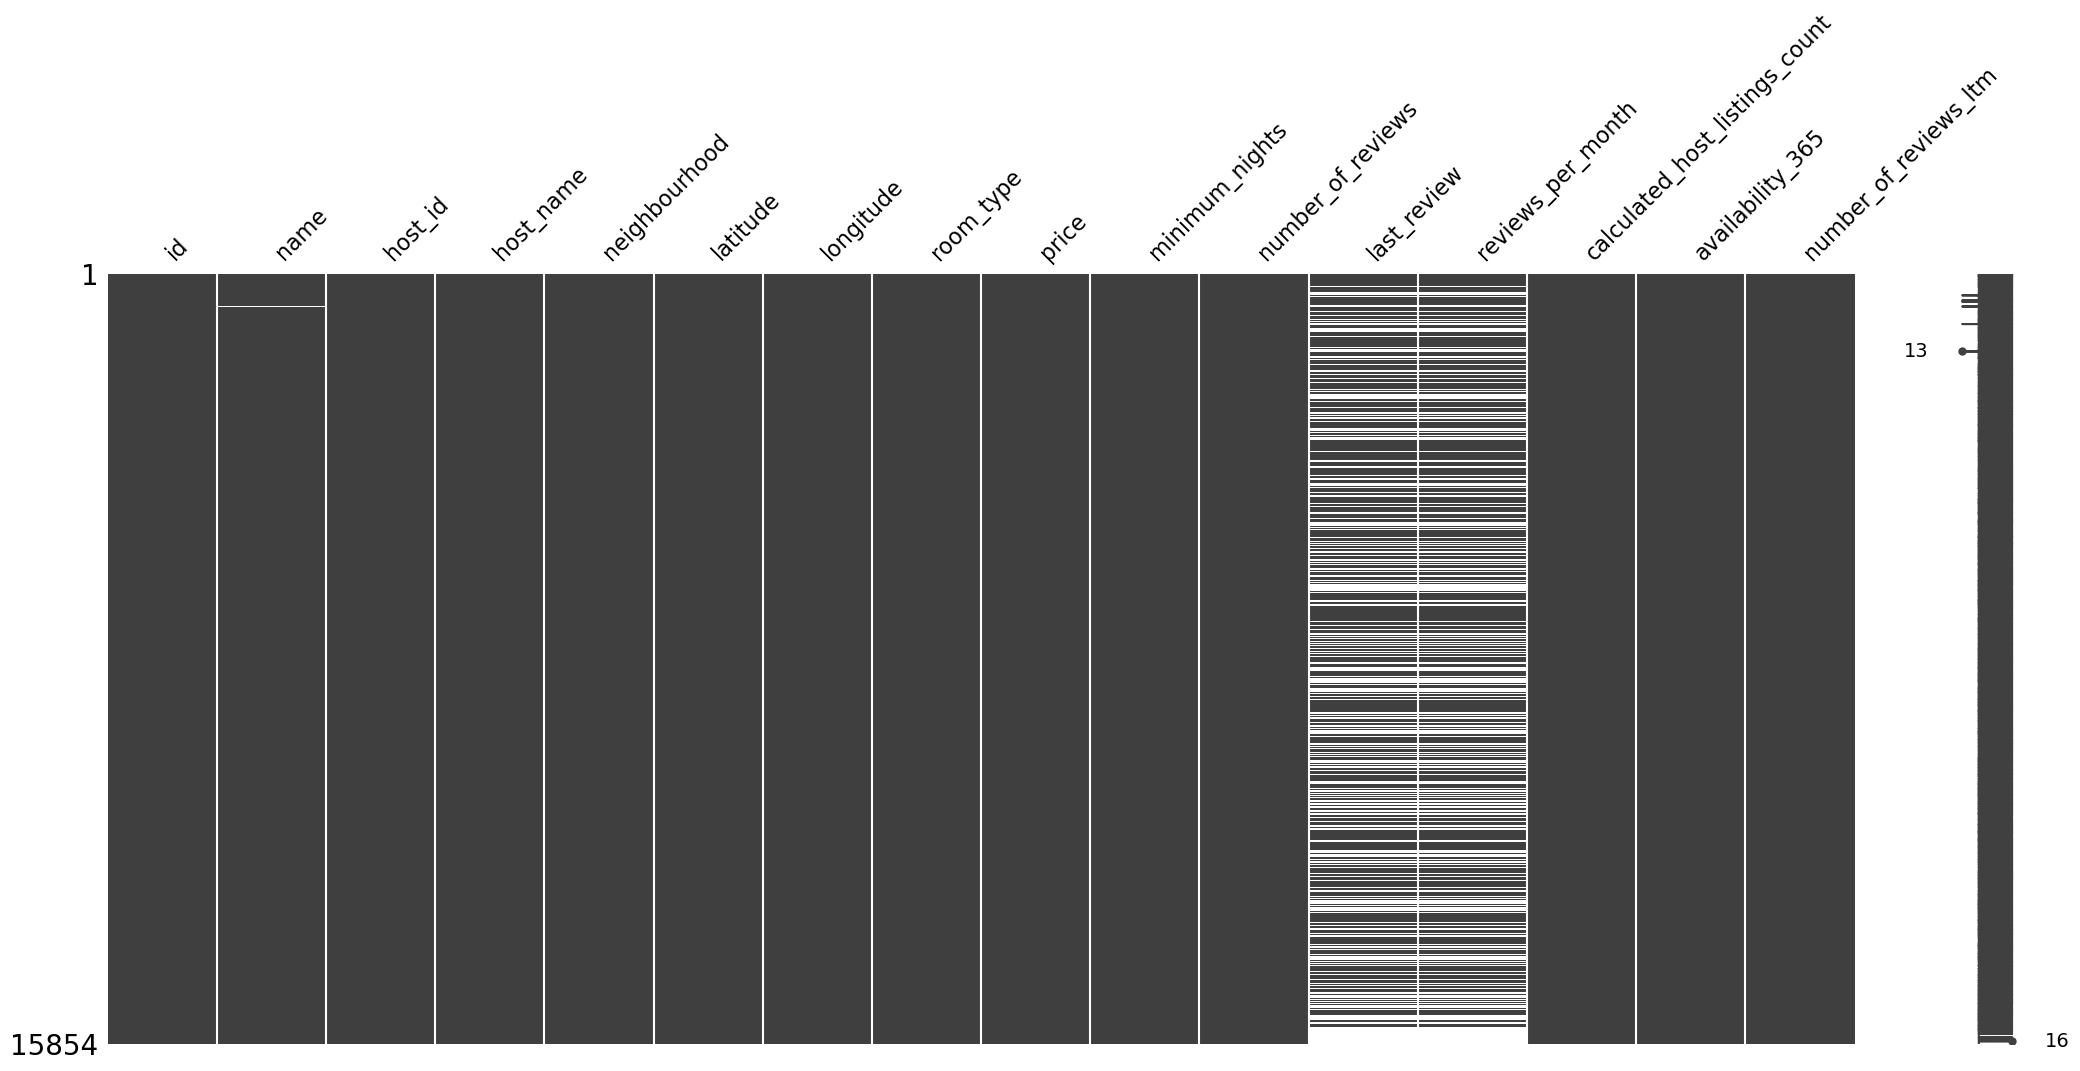

In [53]:
msno.matrix(airbnb)
plt.show()

Persentase nilai yang hilang paling banyak ada di kolom `last_review` dan `reviews_per_month` serta sebagian kecil di kolom `name`. Untuk menangani nilai hilang ini, perlu dicek ulang apakah nilai-nilai tersebut berkaitan dengan kolom lain.

In [54]:
airbnb[['last_review', 'reviews_per_month']].isna().sum()


last_review          5790
reviews_per_month    5790
dtype: int64

In [55]:
zero_review = airbnb[
    airbnb['number_of_reviews']==0
]
zero_review

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.668180,100.616740,Private room,1316,1,0,NaT,NaN,2,358,0
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.752320,100.624020,Private room,800,60,0,NaT,NaN,1,365,0
4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.768720,100.633380,Private room,1905,1,0,NaT,NaN,3,365,0
7,1738669,1 chic bedroom apartment in BKK,7045870,Jiraporn,Chatu Chak,13.829250,100.567370,Entire home/apt,1461,1,0,NaT,NaN,1,365,0
14,959254,"Deluxe Condo, Nana, Pool/GYM/Sauna",5153476,Natcha,Khlong Toei,13.715160,100.568060,Entire home/apt,1400,30,0,NaT,NaN,1,365,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15849,790465040741092826,素坤逸核心两房公寓42楼，靠近BTSon nut/无边天际泳池观赏曼谷夜景/出门当地美食街,94899359,Renee,Pra Wet,13.715132,100.653458,Private room,2298,28,0,NaT,NaN,1,362,0
15850,790474503157243541,Euro LuxuryHotel PratunamMKt TripleBdNrShoping...,491526222,Phakhamon,Ratchathewi,13.753052,100.538738,Private room,1429,1,0,NaT,NaN,14,365,0
15851,790475335086864240,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.753169,100.538700,Private room,1214,1,0,NaT,NaN,14,365,0
15852,790475546213717328,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.754789,100.538757,Private room,1214,1,0,NaT,NaN,14,365,0


In [56]:
zero_review[['last_review','reviews_per_month']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 5790 entries, 1 to 15853
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   last_review        0 non-null      datetime64[ns]
 1   reviews_per_month  0 non-null      float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 135.7 KB


### **Insights**

Berdasarkan tabel di atas, dapat kita simpulkan kolom `last_review` dan `reviews_per_month` memiliki banyak nilai yang hilang disebabkan oleh kolom `number_of_reviews` yang 0. Dalam kasus ini, nilai yang hilang disebut Missing at Random (MAR) karena berkaitan dengan kolom yang lain.

Maka dari itu, nilai yang hilang sebetulnya mengandung informasi. Dapat kita katakan bahwa property dengan `number_of_reviews` yang 0, tidak atau belum pernah diberi review oleh tamu. Agar informasi tersebut lebih jelas, nilai yang kosong pada kolom `reviews_per_month` akan diisi dengan '0', sedangkan kolom `last_review` akan dibiarkan seadanya agar tipe data tidak berubah.

In [57]:
airbnb.loc[airbnb['number_of_reviews']==0,['reviews_per_month']] = 0

In [58]:
airbnb.head(3)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.5,2,353,0
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaT,0.0,2,358,0
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.75232,100.62402,Private room,800,60,0,NaT,0.0,1,365,0


Selanjutnya, kita perlu mengecek missing value pada kolom `name` (nama property).

In [59]:
airbnb['name'].isna().sum()

np.int64(8)

In [60]:
missing_name = airbnb[
    airbnb['name'].isna()
]
missing_name

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
439,4549768,NaN,18852579,Titawan,Phra Khanong,13.69406,100.59619,Private room,1080,5,0,NaT,0.00,1,365,0
544,4720818,NaN,24386225,Cherry,Din Daeng,13.77562,100.57346,Private room,1200,1,0,NaT,0.00,1,365,0
572,4245018,NaN,22030043,Parichart,Bang Phlat,13.78376,100.49821,Private room,1200,1,0,NaT,0.00,1,365,0
669,6148415,NaN,31895202,Chira,Bang Na,13.68276,100.60894,Entire home/apt,2424,2,0,NaT,0.00,1,365,0
1030,8055144,NaN,42521288,Nantida,Vadhana,13.74126,100.55761,Private room,5000,3,0,NaT,0.00,1,365,0
1282,10000742,NaN,51374914,Diamond Bangkok,Ratchathewi,13.75328,100.52928,Private room,930,1,6,2017-05-13,0.07,1,365,0
1594,10710165,NaN,55347997,Khaneungnit,Vadhana,13.71757,100.60464,Private room,1000,1,0,NaT,0.00,1,365,0
2075,13142743,NaN,73275200,Pakaphol,Khlong Toei,13.72566,100.56416,Private room,850,1,2,2017-12-11,0.03,3,220,0


Berdasarkan tabel di atas, ada delapan property yang tidak bernama. Untuk mengatasi nilai kosong ini, kita akan menginput nilai kosong tersebut dengan label 'unknown'.

In [61]:
airbnb['name'].fillna('unknown',inplace=True)

In [62]:
airbnb['name'].isna().sum()

np.int64(0)

Nilai kosong pada kolom `name` telah berhasil diisi.

In [63]:
airbnb['price'].describe()

count    1.585400e+04
mean     3.217704e+03
std      2.497212e+04
min      0.000000e+00
25%      9.000000e+02
50%      1.429000e+03
75%      2.429000e+03
max      1.100000e+06
Name: price, dtype: float64

In [64]:
airbnb.loc[airbnb['price']==0]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
11103,44563108,Somerset Maison Asoke Bangkok,360620448,Somerset Maison Asoke,Vadhana,13.73815,100.5642,Hotel room,0,1,0,NaT,0.0,1,0,0


Terdapat anomali pada `price` dengan nominal 0. Agar data bersih, kita akan menghapus baris tersebut.

In [65]:
airbnb.drop(airbnb[airbnb['price']==0].index,inplace=True)

In [66]:
airbnb.loc[airbnb['price']==0]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm


Anomali `price` telah berhasil dihapus.

## 3.2. Duplicated Value
Pada raw data Airbnb Listings Bangkok, terdapat duplikasi nilai (`latitude` - `longitude` yang selanjutnya akan disebut 'koordinat'). Sebelum ditentukan cara untuk mengatasi duplikasi nilai tersebut, kita perlu melakukan pengecekan terlebih dahulu.

In [67]:
# menampilkan seluruh koordinat duplikat
dup_coords = airbnb[airbnb.duplicated(subset=['latitude', 'longitude'], keep=False)]
dup_coords

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
41,1862089,❂☀☀☀Perfect Escape☀☀☀Sunny Roof EnSuite☀☀☀☀,1927968,Evan,Sathon,13.720620,100.54707,Entire home/apt,1200,1,419,2022-12-07,3.77,37,355,1
46,1862331,☞✪✪✪✪Roomy Studio 4 Family r friends✪No Stairs...,8214044,Evan From Sanctuary House,Sathon,13.720730,100.54690,Entire home/apt,1450,1,268,2022-12-15,2.59,8,350,7
49,1887544,"""Serviced 2 Bed Scenic SkyVillas""",6132593,Salvatore,Sathon,13.720960,100.52911,Entire home/apt,3757,2,118,2022-11-30,1.07,7,134,12
73,385130,❂Citycenter✔Subway station✔Private Bathroom4Ai...,1927968,Evan,Sathon,13.720620,100.54707,Entire home/apt,800,1,396,2020-04-30,3.02,37,361,0
80,393066,✺✺99 feet in the sky✺✺,1927968,Evan,Sathon,13.720620,100.54707,Entire home/apt,829,1,430,2022-10-01,3.39,37,334,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15826,790259260349098761,4 Beds in Mix Dormitory Room,340188343,Rachan,Vadhana,13.740168,100.55632,Shared room,1821,1,0,NaT,0.00,14,365,0
15827,790264226712277949,5 Beds in Mix Dormitory Room,340188343,Rachan,Vadhana,13.740168,100.55632,Shared room,2276,1,0,NaT,0.00,14,365,0
15828,790266011396665923,1 Bed in Mix Dormitory Room,340188343,Rachan,Vadhana,13.740168,100.55632,Shared room,455,1,0,NaT,0.00,14,365,0
15829,790278230325843023,Family Room for 4 People,340188343,Rachan,Vadhana,13.740168,100.55632,Private room,2237,1,0,NaT,0.00,14,360,0


In [68]:
# menampilkan satu perwakilan koordinat yang duplikat (nunique)
dup_coords_one = (
    airbnb[airbnb.duplicated(subset=['latitude','longitude'], keep=False)]
      .drop_duplicates(subset=['latitude','longitude'], keep='first')
)
dup_coords_one

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
41,1862089,❂☀☀☀Perfect Escape☀☀☀Sunny Roof EnSuite☀☀☀☀,1927968,Evan,Sathon,13.720620,100.547070,Entire home/apt,1200,1,419,2022-12-07,3.77,37,355,1
46,1862331,☞✪✪✪✪Roomy Studio 4 Family r friends✪No Stairs...,8214044,Evan From Sanctuary House,Sathon,13.720730,100.546900,Entire home/apt,1450,1,268,2022-12-15,2.59,8,350,7
49,1887544,"""Serviced 2 Bed Scenic SkyVillas""",6132593,Salvatore,Sathon,13.720960,100.529110,Entire home/apt,3757,2,118,2022-11-30,1.07,7,134,12
84,1094136,"Private, relaxed with amenities",5793490,Nicky,Bang Kho laen,13.699490,100.527250,Entire home/apt,980,2,18,2022-11-26,0.18,6,75,1
116,1160838,Spacious 2 Bedroom Apartment near BTS-non smoking,1513875,Suchada,Phaya Thai,13.773600,100.540790,Entire home/apt,2571,3,109,2022-12-18,1.15,4,342,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15540,777492740834573281,曼谷Rama9 现代轻奢两房,490674701,Xin,Huai Khwang,13.756184,100.568269,Entire home/apt,1738,7,0,NaT,0.00,1,272,0
15649,787319837792430707,2 Beds Thong lor/Ekkamai/Nana/Swimming pool,485413319,Yang,Khlong Toei,13.722669,100.576863,Entire home/apt,1733,1,0,NaT,0.00,4,352,0
15660,788036415090605620,Superior Private Room for 2 near BTS,230821951,Good One,Bang Rak,13.725475,100.528877,Private room,1163,1,0,NaT,0.00,4,351,0
15768,786878931060309348,复试-精品店街区/无敌景观/ 網紅餐飲區/文藝區/近日本堂吉訶德领略本土网红餐饮街,492272447,Gravity,Vadhana,13.739771,100.590069,Entire home/apt,1284,30,0,NaT,0.00,2,331,0


In [69]:
host_count = pd.DataFrame(dup_coords.groupby(['latitude','longitude'])['host_id'].nunique().reset_index(name='host_count'))
host_count

,latitude,longitude,host_count
0,13.683570,100.632470,1
1,13.689780,100.603930,1
2,13.698500,100.610100,1
3,13.699490,100.527250,1
4,13.700600,100.516447,1
...,...,...,...
229,13.841590,100.559780,1
230,13.872556,100.572884,1
231,13.889170,100.592210,1
232,13.913359,100.589626,1


In [70]:
host_countt = (
    host_count['host_count']
    .value_counts()
    .reset_index(name='coordinate_count')
    .rename(columns={'index': 'host_count'})
)
host_countt = host_countt[['coordinate_count','host_count']]
host_countt

,coordinate_count,host_count
0,188,1
1,36,2
2,4,3
3,3,4
4,2,7
5,1,5


In [71]:
df_latlong_roomtype = (
    airbnb
    .groupby(['latitude', 'longitude'])['room_type']
    .apply(lambda x: list(x.unique()))
    .reset_index(name='room_types')
)
cek = df_latlong_roomtype[
    df_latlong_roomtype['room_types'].apply(len) > 1
]
display(df_latlong_roomtype,cek)


,latitude,longitude,room_types
0,13.52730,100.42578,[Private room]
1,13.60039,100.50275,[Entire home/apt]
2,13.60130,100.50634,[Entire home/apt]
3,13.60304,100.50524,[Private room]
4,13.60531,100.50642,[Entire home/apt]
...,...,...,...
15266,13.94961,100.61580,[Private room]
15267,13.94982,100.61614,[Private room]
15268,13.95074,100.61541,[Private room]
15269,13.95139,100.61643,[Private room]


,latitude,longitude,room_types
637,13.683570,100.632470,"[Private room, Entire home/apt]"
1355,13.701551,100.603775,"[Entire home/apt, Private room]"
1618,13.704755,100.602092,"[Entire home/apt, Private room]"
2255,13.710570,100.498150,"[Shared room, Private room]"
2825,13.714060,100.599300,"[Entire home/apt, Private room]"
3001,13.715200,100.588870,"[Hotel room, Private room]"
3758,13.719570,100.548600,"[Entire home/apt, Hotel room]"
4062,13.720850,100.585880,"[Hotel room, Private room]"
4236,13.721490,100.546430,"[Entire home/apt, Private room]"
4700,13.723330,100.523310,"[Shared room, Hotel room]"


### **Insights**
Berdasarkan tabel-tabel di atas, dapat kita simpulkan bahwa ada 234 koordinat yang duplikat. Koordinat duplikat karena pada satu listing bisa terdapat beberapa properti. Selain itu dari tabel `host_countt`, dapat kita lihat bahwa masing-masing dari 234 koordinat tidak semuanya dimiliki oleh satu host saja: ada 36 koordinat yang masing-masing dimiliki oleh 2 host berbeda, 4 koordinat masing-masing dimiliki oleh 3 orang berbeda, dan seterusnya.

Untuk menangani duplikat data ini, deduplicate (hapus duplikat) tidak bisa dilakukan karena semua data duplikat diperlukan untuk analisis. Maka kita hanya akan menambahkan kolom baru untuk menandai setiap listing (flag):

- multi_host_building: Koordinat dimiliki oleh beberapa host. --> `is_duplicate_coordinate`==1

- multi_listing_same_host: Host yang sama punya beberapa listing di koordinat yang sama. --> `is_duplicate_coordinate`==1

- individual: Koordinat dimiliki satu host. --> `is_duplicate_coordinate`==0


In [72]:
# 1. Flag untuk koordinat duplikat
is_dup_bool = airbnb.duplicated(subset=['latitude', 'longitude'], keep=False)
airbnb['is_duplicate_coordinate'] = is_dup_bool.astype(int)

# 2. Hitung jumlah host unik per koordinat
airbnb['host_count_per_coord'] = airbnb.groupby(['latitude', 'longitude'])['host_id'].transform('nunique')

# 3. Kategorisasi berdasarkan pola duplikasi
conditions = [
    is_dup_bool & (airbnb['host_count_per_coord'] > 1),
    is_dup_bool & (airbnb['host_count_per_coord'] == 1),
    ~is_dup_bool
]
choices = ['multi_host_building', 'multi_listing_same_host', 'individual']
airbnb['coordinate_type'] = np.select(conditions, choices,default='unknown')

Selanjutnya, pengecekan kesesuaian `neighbourhood` juga perlu dilakukan untuk memastikan tidak ada koordinat yang sama tapi dengan `neighbourhood` yang berbeda (koordinat yang tidak konsisten).

In [73]:
# Hitung jumlah neighbourhood unik per koordinat (dataframe)
neighbourhood_check = (
    airbnb
    .groupby(['latitude', 'longitude'])['neighbourhood']
    .nunique()
    .reset_index(name='neighbourhood_count')
)

# Filter yang punya >1 neighbourhood --> (inconsistent)
inconsistent_coords = neighbourhood_check[neighbourhood_check['neighbourhood_count'] > 1]

# Print hasil
print(f"Total koordinat unik: {len(neighbourhood_check)}")
print(f"Koordinat dengan neighbourhood tidak konsisten: {len(inconsistent_coords)}")

Total koordinat unik: 15271
Koordinat dengan neighbourhood tidak konsisten: 0


In [74]:
airbnb.head(2)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,is_duplicate_coordinate,host_count_per_coord,coordinate_type
0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.5,2,353,0,0,1,individual
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaT,0.0,2,358,0,0,1,individual


In [75]:
print(f'Jumlah Baris: {airbnb.shape[0]}')
print(f'Jumlah Kolom: {airbnb.shape[1]}')

Jumlah Baris: 15853
Jumlah Kolom: 19


Selanjutnya, seleksi kolom-kolom yang akan dipakai. Kolom yang tidak digunakan akan didrop: `host_name`, `name`, `number_of_reviews_ltm`, `host_count_per_coord`, `is_duplicate_coordinate`

In [76]:
airbnb.drop(columns=['host_name','name','number_of_reviews_ltm', 'host_count_per_coord', 'is_duplicate_coordinate'],inplace=True)

In [77]:
airbnb.head(2)


,id,host_id,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,coordinate_type
0,27934,120437,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.5,2,353,individual
1,27979,120541,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaT,0.0,2,358,individual


In [78]:
airbnb.to_csv('airbnb_to_analyzed.csv',index=0)

In [79]:
print(f'Dataset bersih yang akan untuk analisis pada tahap selanjutnya memiliki: {airbnb.shape[0]} baris dan {airbnb.shape[1]} kolom.')

Dataset bersih yang akan untuk analisis pada tahap selanjutnya memiliki: 15853 baris dan 14 kolom.


# **4. Exploratory Data Analysis**

Pada bagian ini bertujuan untuk melihat distribusi dan proporsi tiap kolom secara mandiri. Analisis dibagi menjadi dua sub-bagian:

- **4.1. Univariate Numerik** — distribusi seluruh kolom numerik
- **4.2. Univariate Kategorikal** — proporsi seluruh kolom kategorikal (termasuk `price_category` hasil segmentasi dan `location_category` hasil kategorisasi lat-lng)

> **Feature Engineering** yang menghasilkan `price_category` dan `location_category` dilakukan di dalam sub-bagian 4.2 sebagai prasyarat sebelum visualisasi proporsi kategorikal, namun uji asosiasi/korelasi **tidak** dilakukan di sini — seluruh uji statistik dimulai di **Section 5 (Inferential Analysis)**.

## 4.1. Univariate Numerik

Distribusi seluruh kolom numerik dianalisis menggunakan histogram + KDE dan boxplot. Kolom numerik yang dianalisis:
`price`, `number_of_reviews`, `reviews_per_month`, `latitude`, `longitude`, `minimum_nights`, `availability_365`, `calculated_host_listings_count`

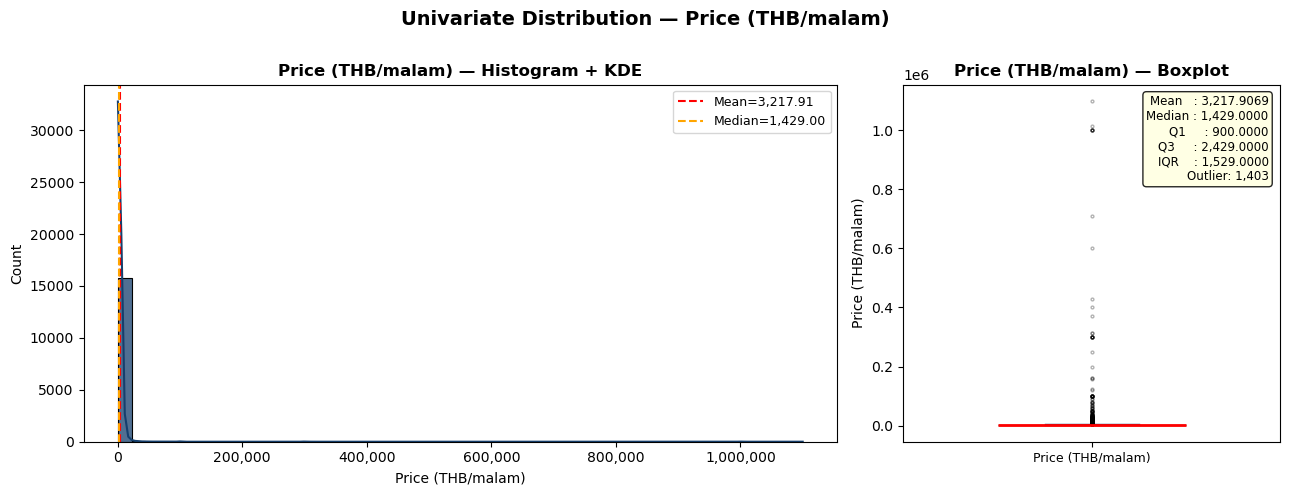

Shapiro-Wilk [Price (THB/malam)]: stat=0.1089, p=3.86e-93 → ❌ Tidak Normal



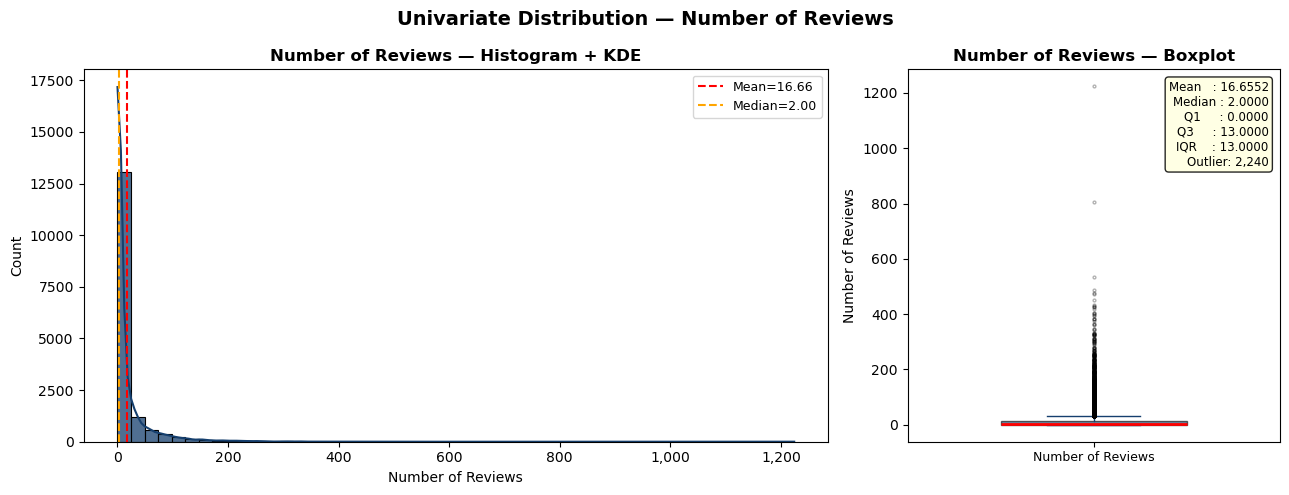

Shapiro-Wilk [Number of Reviews]: stat=0.4380, p=1.07e-82 → ❌ Tidak Normal



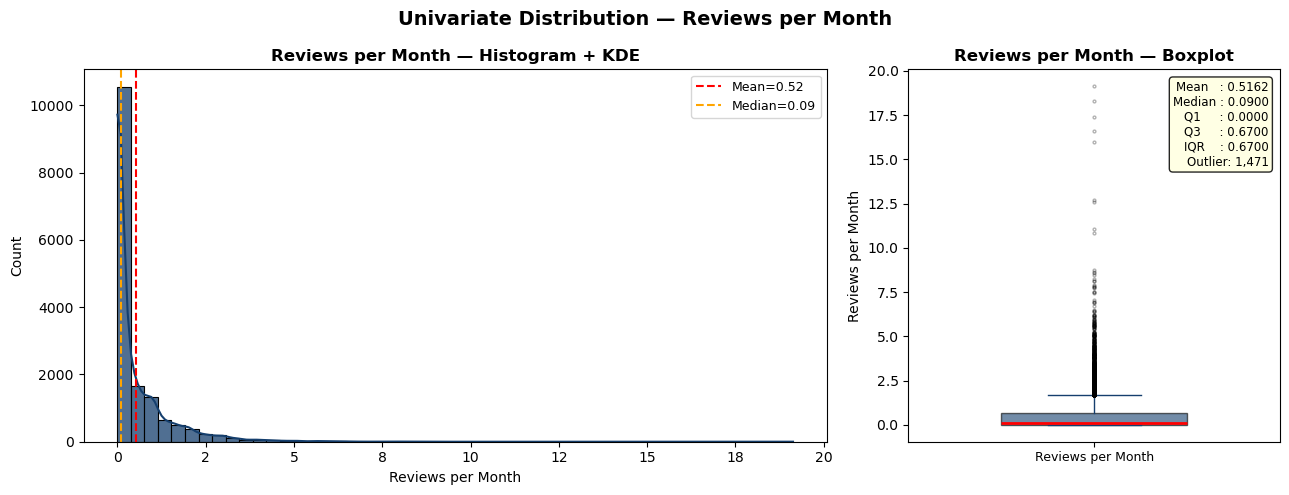

Shapiro-Wilk [Reviews per Month]: stat=0.6087, p=6.12e-75 → ❌ Tidak Normal



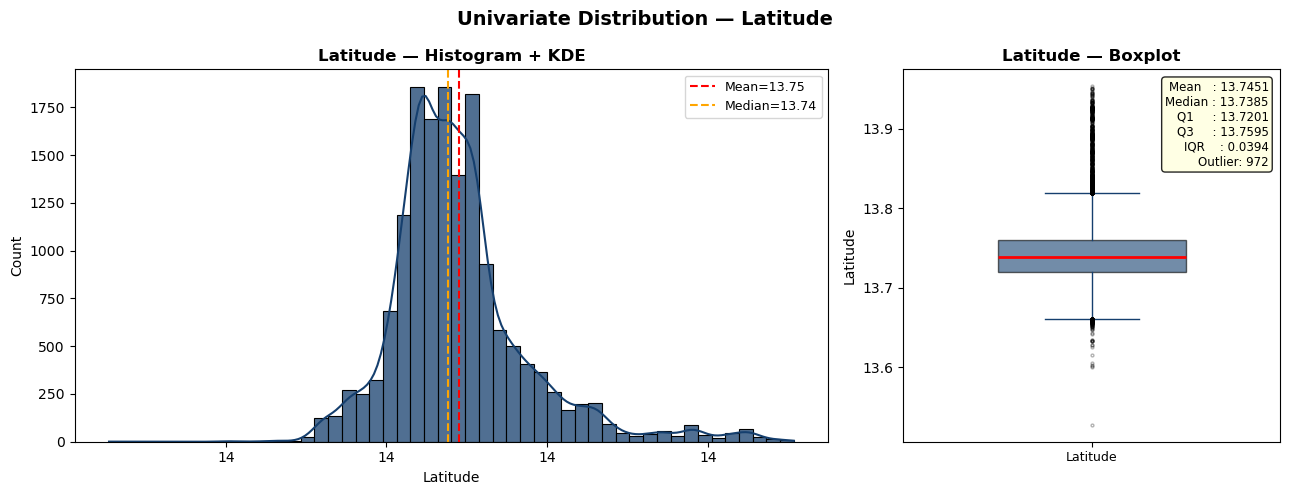

Shapiro-Wilk [Latitude]: stat=0.9090, p=1.22e-47 → ❌ Tidak Normal



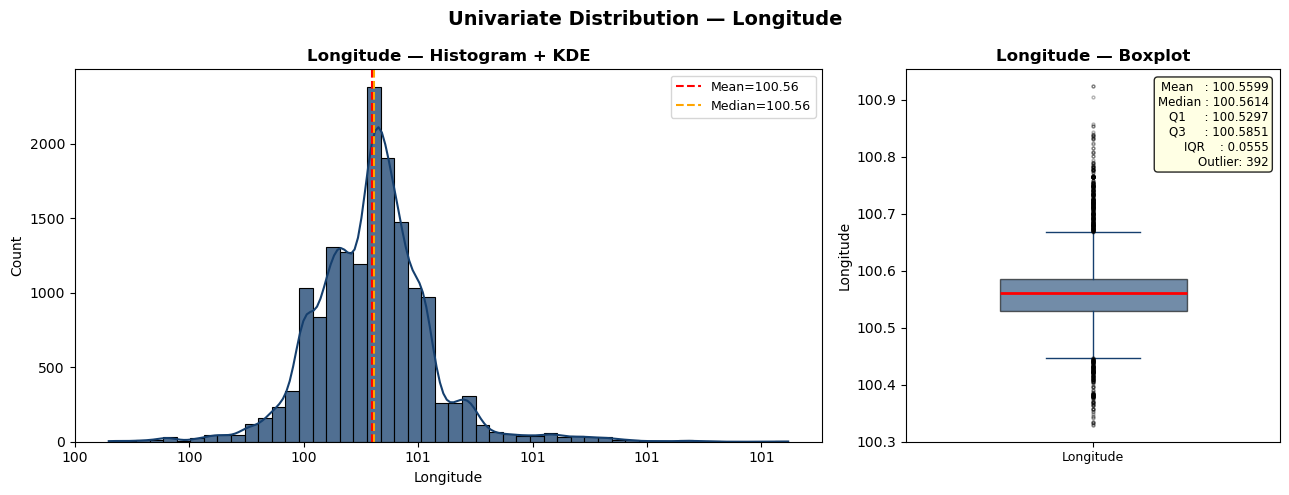

Shapiro-Wilk [Longitude]: stat=0.9517, p=9.09e-38 → ❌ Tidak Normal



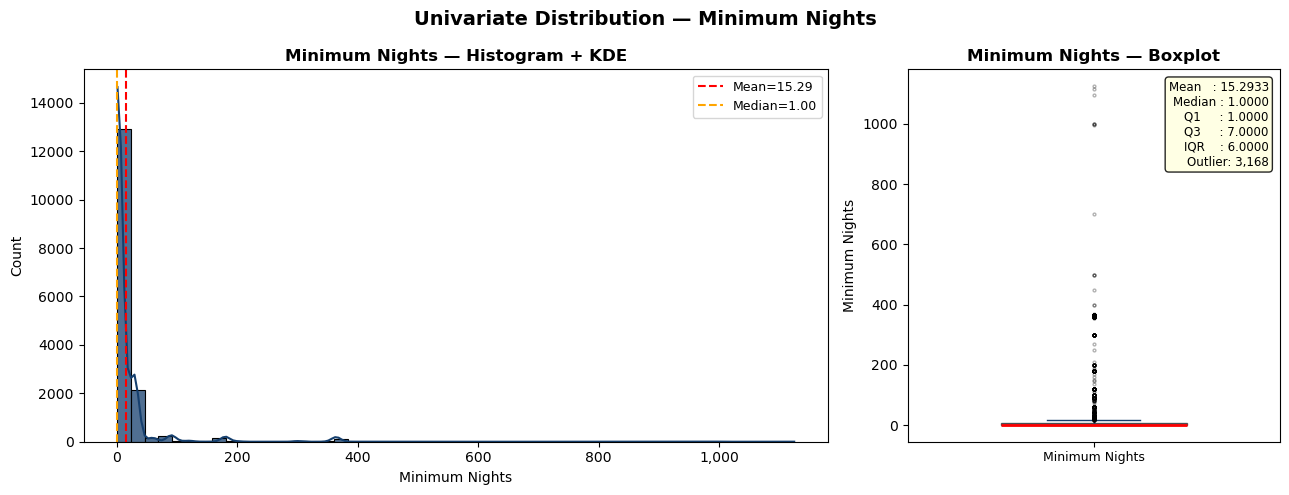

Shapiro-Wilk [Minimum Nights]: stat=0.2786, p=2.83e-88 → ❌ Tidak Normal



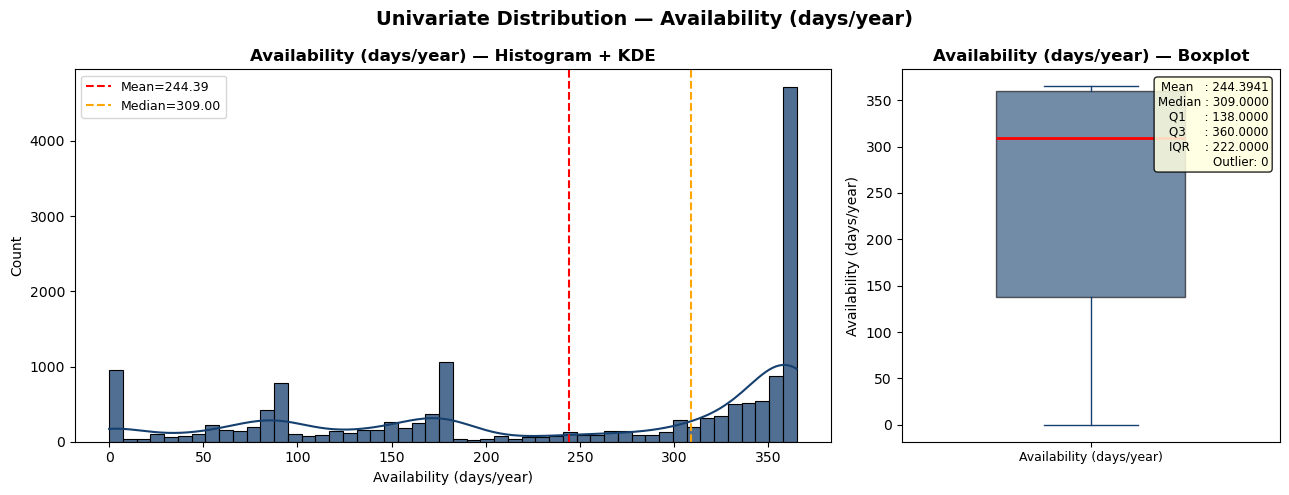

Shapiro-Wilk [Availability (days/year)]: stat=0.8331, p=3.20e-58 → ❌ Tidak Normal



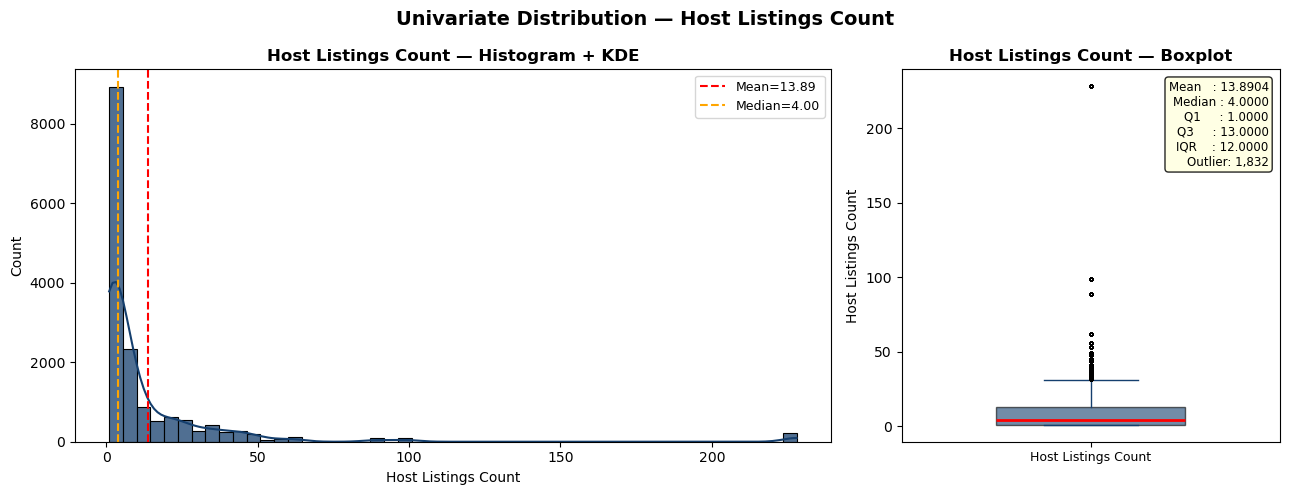

Shapiro-Wilk [Host Listings Count]: stat=0.4281, p=4.44e-83 → ❌ Tidak Normal



In [80]:
import matplotlib.ticker as ticker
from scipy.stats import shapiro

num_cols_uni = ['price', 'number_of_reviews', 'reviews_per_month', 'latitude', 'longitude',
                'minimum_nights', 'availability_365', 'calculated_host_listings_count']
col_labels = {
    'price': 'Price (THB/malam)',
    'number_of_reviews': 'Number of Reviews',
    'reviews_per_month': 'Reviews per Month',
    'latitude': 'Latitude',
    'longitude': 'Longitude',
    'minimum_nights': 'Minimum Nights',
    'availability_365': 'Availability (days/year)',
    'calculated_host_listings_count': 'Host Listings Count',
}

for col in num_cols_uni:
    col_display = col_labels[col]
    data = airbnb[col].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [2, 1]})
    fig.suptitle(f'Univariate Distribution — {col_display}', fontsize=14, fontweight='bold')

    # Histplot
    sns.histplot(data, bins=50, kde=True, ax=axes[0], color='#153f6e', alpha=0.75)
    mean_val = data.mean()
    med_val  = data.median()
    axes[0].axvline(mean_val, color='red',    ls='--', lw=1.5, label=f'Mean={mean_val:,.2f}')
    axes[0].axvline(med_val,  color='orange', ls='--', lw=1.5, label=f'Median={med_val:,.2f}')
    axes[0].legend(fontsize=9)
    axes[0].set_title(f'{col_display} — Histogram + KDE', fontweight='bold')
    axes[0].set_xlabel(col_display)
    axes[0].set_ylabel('Count')
    axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # Boxplot
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    ub  = Q3 + 1.5 * IQR
    n_outlier = (data > ub).sum()

    stats_txt = (
        f'Mean   : {mean_val:,.4f}\n'
        f'Median : {med_val:,.4f}\n'
        f'Q1     : {Q1:,.4f}\n'
        f'Q3     : {Q3:,.4f}\n'
        f'IQR    : {IQR:,.4f}\n'
        f'Outlier: {n_outlier:,}'
    )
    axes[1].boxplot([data.values], patch_artist=True, widths=0.5,
                    boxprops=dict(facecolor='#153f6e', alpha=0.6),
                    medianprops=dict(color='red', lw=2),
                    whiskerprops=dict(color='#153f6e'),
                    capprops=dict(color='#153f6e'),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray'))
    axes[1].text(0.97, 0.97, stats_txt, transform=axes[1].transAxes,
                 ha='right', va='top', fontsize=8.5,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))
    axes[1].set_title(f'{col_display} — Boxplot', fontweight='bold')
    axes[1].set_xticks([1])
    axes[1].set_xticklabels([col_display], fontsize=9)
    axes[1].set_ylabel(col_display)

    plt.tight_layout()
    plt.show()

    # Shapiro-Wilk
    sample = data.sample(min(5000, len(data)), random_state=42)
    stat_sw, p_sw = shapiro(sample)
    print(f'Shapiro-Wilk [{col_display}]: stat={stat_sw:.4f}, p={p_sw:.2e} → '
          f'{"❌ Tidak Normal" if p_sw < 0.05 else "✅ Normal"}')
    print()

### **Insights — Univariate Numerik**

**1. `price`**
Distribusi sangat *right-skewed*: sebagian besar listing berada di harga rendah-menengah, sementara sejumlah kecil listing bertarif sangat tinggi menjadi outlier ekstrem. Mean jauh di atas median, mengonfirmasi skewness kanan yang kuat. Karena distribusi tidak normal, segmentasi berbasis kuartil (Budget/Medium/Premium/Luxury) lebih tepat daripada segmentasi berbasis mean.

**2. `number_of_reviews`**
Distribusi sangat ekstrem: Q1 = 0 menunjukkan setidaknya 25% listing tidak memiliki review sama sekali. Median yang rendah dan mean yang jauh lebih tinggi menandakan adanya sebagian kecil listing yang mendominasi jumlah review. Uji Shapiro-Wilk mengonfirmasi distribusi tidak normal — justifikasi penggunaan metode non-parametrik pada tahap selanjutnya.

**3. `reviews_per_month`**
Pola serupa dengan `number_of_reviews` — skewed kanan dengan konsentrasi besar di nilai 0. Keduanya berkorelasi erat secara konseptual sehingga salah satu cukup digunakan sebagai target analisis. Variabel ini **tidak diikutsertakan** sebagai kandidat independen karena merupakan turunan langsung dari `number_of_reviews`.

**4. `latitude`**
Distribusi `latitude` relatif normal dengan sedikit skewness — mencerminkan sebaran geografis listing yang terpusat di Bangkok. Nilai berkisar antara ~13,5° hingga ~14,0°N. Tidak ada outlier ekstrem yang mengindikasikan data koordinat bersih.

**5. `longitude`**
Distribusi `longitude` lebih merata dengan sedikit konsentrasi di rentang 100,4°–100,6°E — sesuai dengan sebaran pusat kota Bangkok. Keduanya (`latitude` dan `longitude`) tidak dianalisis secara terpisah dalam uji asosiasi, melainkan dikombinasikan menjadi `distance_km` dan `location_category` pada tahap feature engineering.

**6. `minimum_nights`**
Distribusi sangat *right-skewed* dengan mayoritas listing mensyaratkan minimum 1–3 malam. Terdapat outlier ekstrem pada listing yang mensyaratkan minimum nights sangat tinggi (puluhan hingga ratusan malam), yang kemungkinan merupakan listing long-stay atau listing dengan kebijakan khusus. Listing dengan `minimum_nights` tinggi berpotensi lebih sulit mendapatkan review karena tamu lebih sedikit.

**7. `availability_365`**
Distribusi bimodal — terkonsentrasi di dua kutub: listing dengan sisa ketersediaan sangat rendah dan listing dengan sisa ketersediaan sangat tinggi. Penting untuk memahami definisi variabel ini dengan tepat: `availability_365` mengukur **sisa hari kalender yang masih bisa dipesan**, bukan seberapa aktif listing dikelola. Nilai rendah berarti banyak hari sudah terisi — baik karena sudah dipesan tamu maupun karena host memblokir kalender. Nilai tinggi berarti kalender masih banyak kosong, yang bisa mengindikasikan rendahnya permintaan atau host yang baru mendaftarkan listing. Ambiguitas antara "dipesan" dan "diblokir host" ini perlu dicatat sebagai keterbatasan interpretasi.

**8. `calculated_host_listings_count`**
Distribusi sangat *right-skewed*: mayoritas host hanya memiliki 1 listing, namun sebagian kecil host memiliki puluhan listing (host profesional/manajemen properti). Pola ini mencerminkan ekosistem host yang heterogen — dari host individu dengan satu properti hingga operator skala besar. Relevansi variabel ini terhadap *zero review rate* akan diuji secara inferensial di Section 5.4.


## 4.2. Univariate Kategorikal

Proporsi seluruh kolom kategorikal divisualisasikan menggunakan bar chart dan pie chart. Dataset bersih memiliki tiga kolom kategorikal asli: `room_type`, `neighbourhood`, dan `coordinate_type`. Namun, tidak ketiganya dianalisis distribusinya di sini — berikut penjelasannya:

- **a. Kolom kategorikal asli yang divisualisasikan:** `room_type`, `neighbourhood`
- **b. Kolom kategorikal asli yang dikecualikan dari visualisasi:** `coordinate_type`
  - `coordinate_type` adalah **flag data quality** yang dibuat pada tahap Data Cleaning untuk menandai pola duplikasi koordinat (*individual* / *multi_listing_same_host* / *multi_host_building*). Kolom ini bukan variabel analitis dan tidak relevan secara bisnis sebagai faktor risiko *zero review*. Oleh karena itu, `coordinate_type` tidak diikutsertakan dalam visualisasi EDA maupun uji inferensial.
- **c. Kolom hasil feature engineering:**
  - `price_category` — segmentasi `price` menjadi: Budget / Medium / Premium / Luxury (berdasarkan kuartil)
  - `location_category` — kategorisasi lokasi dari lat-lng menjadi: Inner City / Suburban / Peripheral (berdasarkan jarak Haversine dari pusat kota Bangkok)

> **Catatan:** Feature engineering dilakukan di sini **hanya** sebagai prasyarat untuk menampilkan distribusi variabel-variabel tersebut. Uji asosiasi dan korelasi dilakukan di **Section 5**.

### a. Kolom Kategorikal Asli: `room_type` & `neighbourhood`

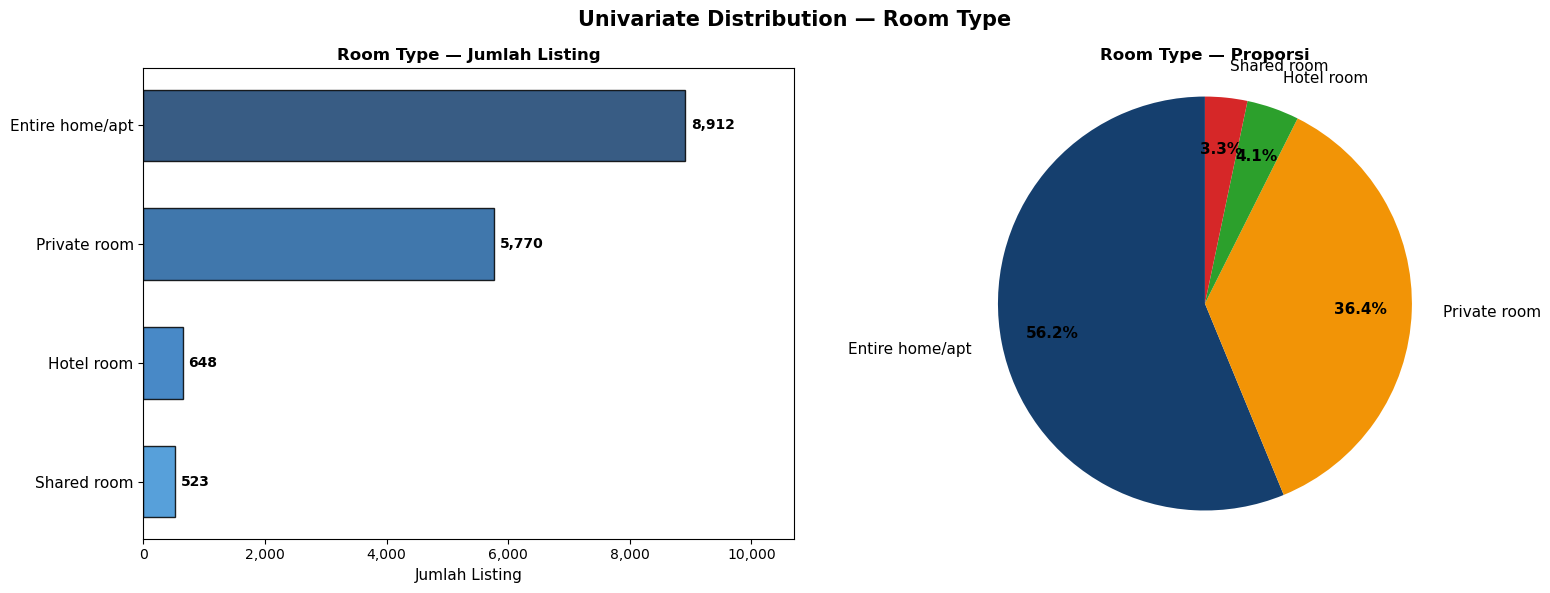

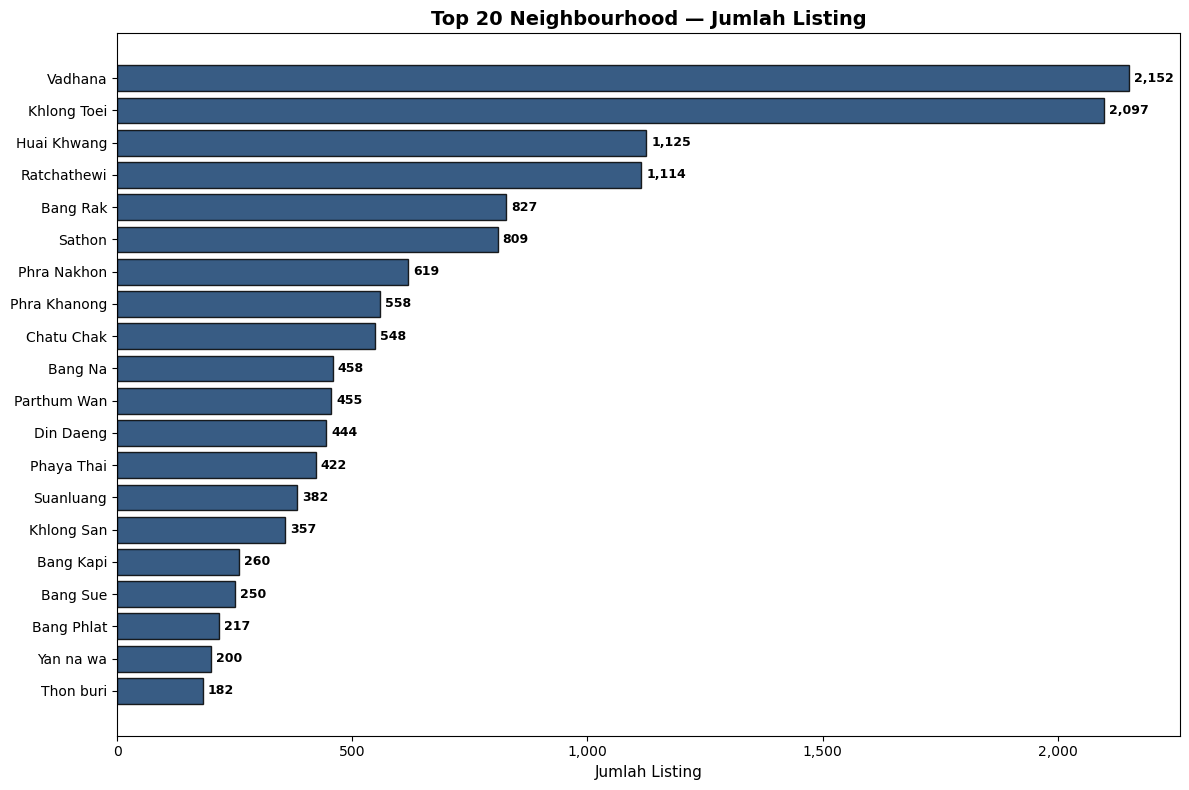

Total neighbourhood unik: 50
Total listing: 15,853


In [81]:
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

PALETTE_BAR  = ['#153f6e', '#1e5f9e', '#2874be', '#3a8fd4']
PALETTE_PIE  = ['#153f6e', '#f29406', '#2ca02c', '#d62728']
FIG_SIZE     = (16, 6)   # unified figure size
PIE_RADIUS   = 1.1       # slightly larger wedges

# ── A. room_type ──
val_counts = airbnb['room_type'].value_counts()
cats = val_counts.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIG_SIZE)
fig.suptitle('Univariate Distribution — Room Type', fontsize=15, fontweight='bold')

colors_bar = PALETTE_BAR[:len(cats)]
ax1.barh(range(len(cats)), val_counts.values, color=colors_bar, edgecolor='black', alpha=0.85, height=0.6)
ax1.invert_yaxis()
ax1.set_yticks(range(len(cats)))
ax1.set_yticklabels(cats, fontsize=11)
for i, v in enumerate(val_counts.values):
    ax1.text(v + val_counts.max()*0.01, i, f'{v:,}', va='center', fontsize=10, fontweight='bold')
ax1.set_xlabel('Jumlah Listing', fontsize=11)
ax1.set_title('Room Type — Jumlah Listing', fontweight='bold', fontsize=12)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.set_xlim(0, val_counts.max() * 1.2)

wedges, texts, autotexts = ax2.pie(
    val_counts.values, labels=cats,
    autopct='%1.1f%%', startangle=90,
    colors=PALETTE_PIE[:len(cats)],
    textprops={'fontsize': 11},
    radius=PIE_RADIUS,
    pctdistance=0.75,
    labeldistance=1.15
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax2.set_title('Room Type — Proporsi', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# ── B. neighbourhood (Top-20 bar + distribusi pie single/multi) ──
neigh_counts = airbnb['neighbourhood'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(neigh_counts)), neigh_counts.values, color='#153f6e', edgecolor='black', alpha=0.85)
ax.invert_yaxis()
ax.set_yticks(range(len(neigh_counts)))
ax.set_yticklabels(neigh_counts.index, fontsize=10)
for i, v in enumerate(neigh_counts.values):
    ax.text(v + neigh_counts.max()*0.005, i, f'{v:,}', va='center', fontsize=9, fontweight='bold')
ax.set_title('Top 20 Neighbourhood — Jumlah Listing', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Listing', fontsize=11)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f'Total neighbourhood unik: {airbnb["neighbourhood"].nunique()}')
print(f'Total listing: {len(airbnb):,}')


### **Insights — Univariate Kategorikal**

**1. `room_type`**
*Entire home/apt* mendominasi dengan lebih dari 60% listing — mencerminkan preferensi host Bangkok untuk menyewakan unit penuh. *Private room* menjadi tipe kedua terbanyak. Sementara *Shared room* dan *Hotel room* memiliki proporsi yang jauh lebih kecil. Relevansi masing-masing tipe properti terhadap *zero review status* akan diuji secara inferensial di Section 5.2.

**2. `neighbourhood`**
Distribusi listing sangat terkonsentrasi: beberapa neighbourhood (seperti Vadhana, Khlong Toei) mendominasi jumlah listing, sementara banyak neighbourhood lainnya hanya memiliki puluhan listing. Dengan 50 neighbourhood unik, granularitas ini terlalu tinggi untuk uji statistik langsung. Oleh karena itu, `neighbourhood` **tidak langsung digunakan** sebagai variabel dalam uji asosiasi, melainkan diagregasi menjadi `location_category` (Inner City / Suburban / Peripheral) pada tahap feature engineering berdasarkan jarak Haversine dari pusat kota.

> **Catatan tentang `coordinate_type`:** Kolom ini (kategori: *individual* / *multi_listing_same_host* / *multi_host_building*) tersedia di dataset bersih sebagai flag data quality dari tahap Data Cleaning, namun **tidak diikutsertakan dalam visualisasi EDA** karena bukan variabel analitis. Kolom ini hanya berfungsi sebagai penanda pola duplikasi koordinat untuk keperluan audit data, bukan sebagai dimensi yang relevan terhadap risiko *zero review*.


### b. Feature Engineering: `price_category` & `location_category`

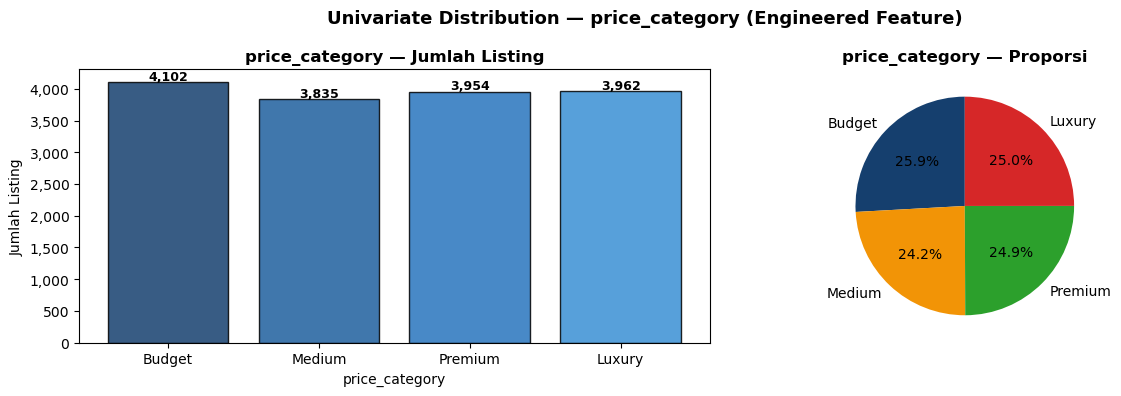

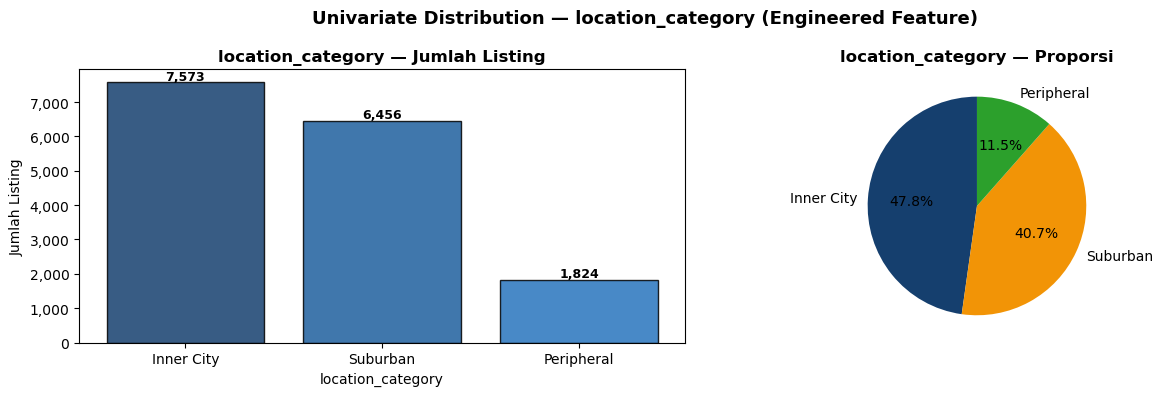

✅ Feature engineering selesai. Kolom baru: price_category, location_category, is_zero_review


In [82]:
import numpy as np

# ── 1. price_category (kuartil)
if 'price_category' not in airbnb.columns:
    q1_p, q2_p, q3_p = airbnb['price'].quantile([0.25, 0.50, 0.75])
    airbnb['price_category'] = pd.cut(
        airbnb['price'],
        bins=[-np.inf, q1_p, q2_p, q3_p, np.inf],
        labels=['Budget', 'Medium', 'Premium', 'Luxury']
    )

# ── 2. distance_km & location_category (Haversine dari pusat kota)
if 'location_category' not in airbnb.columns:
    def haversine_distance(lat1, lon1, lat2, lon2):
        R = 6371
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat, dlon = lat2 - lat1, lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        return R * 2 * np.arcsin(np.sqrt(a))

    CITY_CENTER = {'latitude': 13.7500, 'longitude': 100.4911}
    airbnb['distance_km'] = airbnb.apply(
        lambda row: haversine_distance(
            row['latitude'], row['longitude'],
            CITY_CENTER['latitude'], CITY_CENTER['longitude']
        ), axis=1
    )
    airbnb['location_category'] = airbnb['distance_km'].apply(
        lambda d: 'Inner City' if d <= 8 else ('Suburban' if d <= 15 else 'Peripheral')
    )

# ── 3. is_zero_review (biner target)
airbnb['is_zero_review'] = (airbnb['number_of_reviews'] == 0).astype(int)

# ── VISUALISASI
for col, order in [('price_category',    ['Budget','Medium','Premium','Luxury']),
                   ('location_category', ['Inner City','Suburban','Peripheral'])]:
    val_counts = airbnb[col].value_counts().reindex(order).dropna()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Univariate Distribution — {col} (Engineered Feature)', fontsize=13, fontweight='bold')

    colors_fe = ['#153f6e','#1e5f9e','#2874be','#3a8fd4'][:len(val_counts)]
    ax1.bar(val_counts.index, val_counts.values, color=colors_fe, edgecolor='black', alpha=0.85)
    for i, (cat, v) in enumerate(val_counts.items()):
        ax1.text(i, v + val_counts.max()*0.01, f'{v:,}', ha='center', fontsize=9, fontweight='bold')
    ax1.set_title(f'{col} — Jumlah Listing', fontweight='bold')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Jumlah Listing')
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    ax2.pie(val_counts.values, labels=val_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['#153f6e','#f29406','#2ca02c','#d62728'][:len(val_counts)],
            textprops={'fontsize': 10})
    ax2.set_title(f'{col} — Proporsi', fontweight='bold')

    plt.tight_layout()
    plt.show()

print("✅ Feature engineering selesai. Kolom baru: price_category, location_category, is_zero_review")

# **5. Inferential Analysis**

Pada bagian ini dilakukan pengujian statistik untuk menentukan apakah perbedaan *zero review rate* antar kelompok signifikan secara statistik, serta mengukur **kekuatan pengaruh** masing-masing faktor.

Analisis dibagi menjadi dua tahap:
1. **5.1. Uji Korelasi & Seleksi Variabel** — mengidentifikasi dan meranking variabel berdasarkan kekuatan asosiasi dengan `is_zero_review`
2. **5.2–5.7. Uji Statistik per Variabel** — uji non-parametrik (Kruskal-Wallis + Mann-Whitney U) pada variabel-variabel terpilih, ditutup dengan analisis interaksi

> **Target variabel dependen konsisten di seluruh Section 5:** `is_zero_review` (1 = tidak ada review, 0 = ada review). Pilihan ini dijelaskan di bawah.

## 5.1. Uji Korelasi & Seleksi Variabel

Sebelum melakukan uji inferensial per variabel, dilakukan terlebih dahulu uji asosiasi untuk mengidentifikasi variabel yang paling relevan terhadap **`is_zero_review`** — variabel target biner yang konsisten digunakan di seluruh Section 5.

- **Spearman Correlation** untuk variabel numerik terhadap `is_zero_review`
- **Cramér's V** untuk variabel kategorikal terhadap `is_zero_review`

Hasil seleksi ini menentukan urutan dan prioritas analisis pada section 5.2–5.7.

**Kriteria seleksi:**
- Cramér's V ≥ 0.1 → lemah; ≥ 0.2 → sedang; ≥ 0.4 → kuat
- Spearman |ρ| ≥ 0.1 → lemah; ≥ 0.3 → sedang; ≥ 0.5 → kuat


#### **Mengapa `number_of_reviews` Dibinarisasi Menjadi `is_zero_review`?**

`number_of_reviews` memiliki distribusi yang sangat *right-skewed* dan tidak normal (dikonfirmasi oleh Shapiro-Wilk di Section 4.1). Nilai median = 0 atau mendekati 0, sedangkan sebagian kecil listing mendominasi jumlah review. Karakteristik ini membuat analisis berbasis nilai absolut menjadi rentan terhadap outlier dan sulit diinterpretasikan secara bisnis.

Transformasi ke bentuk biner `is_zero_review` (1 = tidak punya review, 0 = punya review) dilakukan karena:

1. **Relevansi bisnis langsung** — pertanyaan utama bukan "berapa banyak review?" melainkan "apakah listing ini pernah dapat review sama sekali?" Listing tanpa review adalah yang paling rentan secara algoritmik di platform.
2. **Stabilitas statistik** — variabel biner tidak terpengaruh outlier ekstrem; uji proporsi dan asosiasi (Cramér's V, chi-square) bekerja secara lebih andal.
3. **Konsistensi dengan metode** — Cramér's V mengukur asosiasi antara dua variabel kategorikal; untuk menguji variabel numerik terhadap Cramér's V, diperlukan representasi kategorikal yang bersih — biner adalah bentuk paling sederhana.
4. **Interpretabilitas** — *zero review rate* per kelompok (mis. 60,8% untuk Shared room) jauh lebih mudah dikomunikasikan kepada Host Operations Team dibandingkan rata-rata `number_of_reviews` yang bias oleh outlier.


### 5.1.a. Spearman Correlation — Variabel Numerik

A. SPEARMAN CORRELATION (Numerik vs is_zero_review)
-------------------------------------------------------
  price                              : ρ = +0.0435 | p = 4.15e-08 | Sangat Lemah | ✅ Signifikan
  minimum_nights                     : ρ = -0.0519 | p = 6.32e-11 | Sangat Lemah | ✅ Signifikan
  availability_365                   : ρ = +0.2386 | p = 5.11e-204 | Lemah | ✅ Signifikan
  calculated_host_listings_count     : ρ = -0.2201 | p = 3.36e-173 | Lemah | ✅ Signifikan
  distance_km                        : ρ = +0.0834 | p = 6.90e-26 | Sangat Lemah | ✅ Signifikan


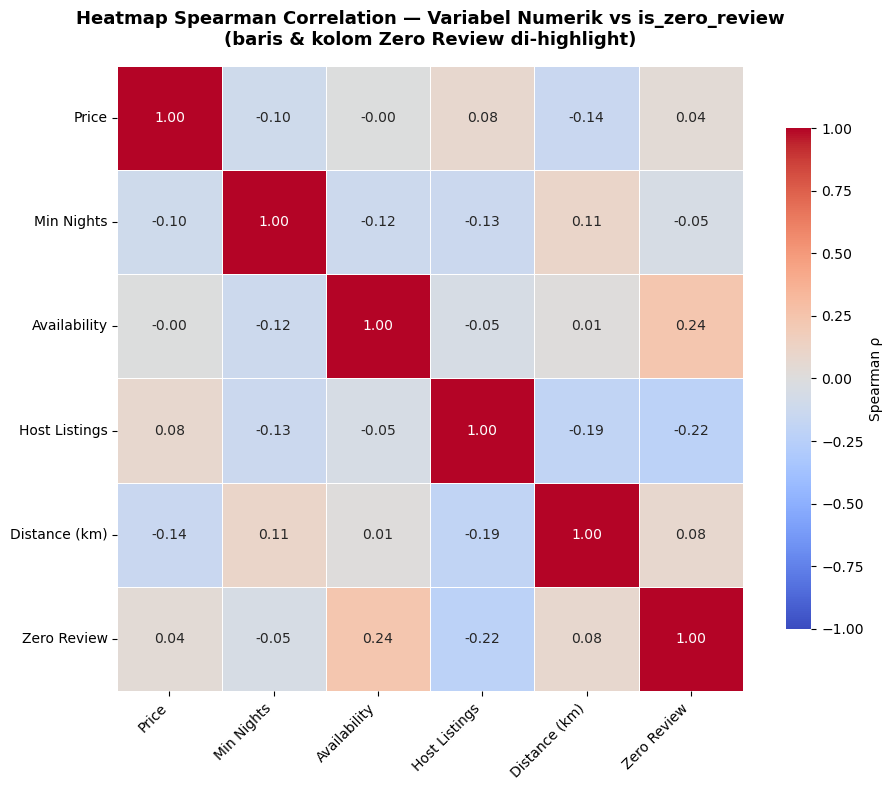


Tabel Rangkuman Spearman Correlation vs is_zero_review:
                                Spearman ρ  p-value  Interpretasi  Signifikansi
Variabel                                                                       
price                               0.0435      0.0  Sangat Lemah  ✅ Signifikan
minimum_nights                     -0.0519      0.0  Sangat Lemah  ✅ Signifikan
availability_365                    0.2386      0.0         Lemah  ✅ Signifikan
calculated_host_listings_count     -0.2201      0.0         Lemah  ✅ Signifikan
distance_km                         0.0834      0.0  Sangat Lemah  ✅ Signifikan


In [83]:
from scipy.stats import spearmanr, chi2_contingency
import numpy as np

# ─────────────────────────────────────────────────────────────
# A. SPEARMAN CORRELATION — Numerik vs is_zero_review
# ─────────────────────────────────────────────────────────────

print("A. SPEARMAN CORRELATION (Numerik vs is_zero_review)")
print("-" * 55)

num_candidates = ['price', 'minimum_nights', 'availability_365',
                  'calculated_host_listings_count', 'distance_km']
# reviews_per_month dikecualikan (derivat dari number_of_reviews)
# latitude & longitude dikecualikan (sudah direpresentasikan distance_km)

col_labels_corr = {
    'price': 'Price',
    'minimum_nights': 'Min Nights',
    'availability_365': 'Availability',
    'calculated_host_listings_count': 'Host Listings',
    'distance_km': 'Distance (km)',
}

spearman_results = []
for col in num_candidates:
    data_clean = airbnb[[col, 'is_zero_review']].dropna()
    rho, p_val = spearmanr(data_clean[col], data_clean['is_zero_review'])
    interp = 'Sangat Lemah' if abs(rho) < 0.1 else ('Lemah' if abs(rho) < 0.3 else ('Sedang' if abs(rho) < 0.5 else 'Kuat'))
    sig = '✅ Signifikan' if p_val < 0.05 else '❌ Tidak Signifikan'
    spearman_results.append({'Variabel': col, 'Spearman ρ': round(rho, 4), 'p-value': round(p_val, 6), 'Interpretasi': interp, 'Signifikansi': sig})
    print(f"  {col:35s}: ρ = {rho:+.4f} | p = {p_val:.2e} | {interp} | {sig}")

# ─────────────────────────────────────────────────────────────
# HEATMAP — Spearman full matrix + highlight is_zero_review
# ─────────────────────────────────────────────────────────────

num_cols_corr = ['price', 'minimum_nights', 'availability_365',
                 'calculated_host_listings_count', 'distance_km', 'is_zero_review']

col_labels_heatmap = {
    'price': 'Price',
    'minimum_nights': 'Min Nights',
    'availability_365': 'Availability',
    'calculated_host_listings_count': 'Host Listings',
    'distance_km': 'Distance (km)',
    'is_zero_review': 'Zero Review',
}

corr_matrix = airbnb[num_cols_corr].dropna().corr(method='spearman')
corr_matrix.index   = [col_labels_heatmap[c] for c in corr_matrix.index]
corr_matrix.columns = [col_labels_heatmap[c] for c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={'label': 'Spearman ρ', 'shrink': 0.8}
)


ax.set_title(
    'Heatmap Spearman Correlation — Variabel Numerik vs is_zero_review\n(baris & kolom Zero Review di-highlight)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

print("\nTabel Rangkuman Spearman Correlation vs is_zero_review:")
print(pd.DataFrame(spearman_results).set_index('Variabel').to_string())

### 5.1.b. Cramér's V — Variabel Kategorikal

B. CRAMÉR'S V (Kategorik vs Zero Review)
-------------------------------------------------------
Target: is_zero_review (1 = zero review, 0 = has review)

  room_type                : V = 0.2573 | Sedang
  location_category        : V = 0.1131 | Lemah
  price_category           : V = 0.0802 | Sangat Lemah


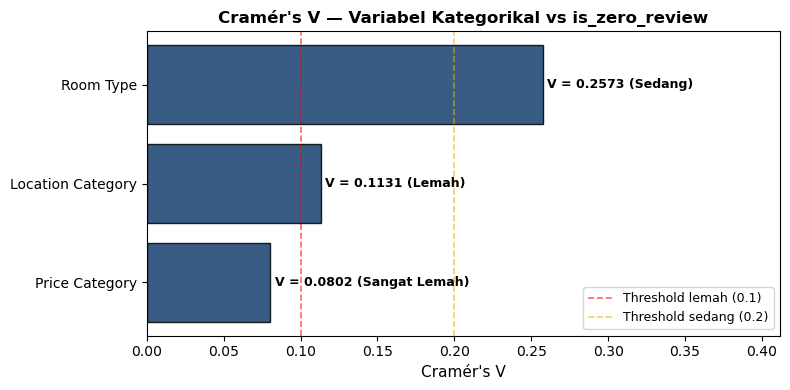

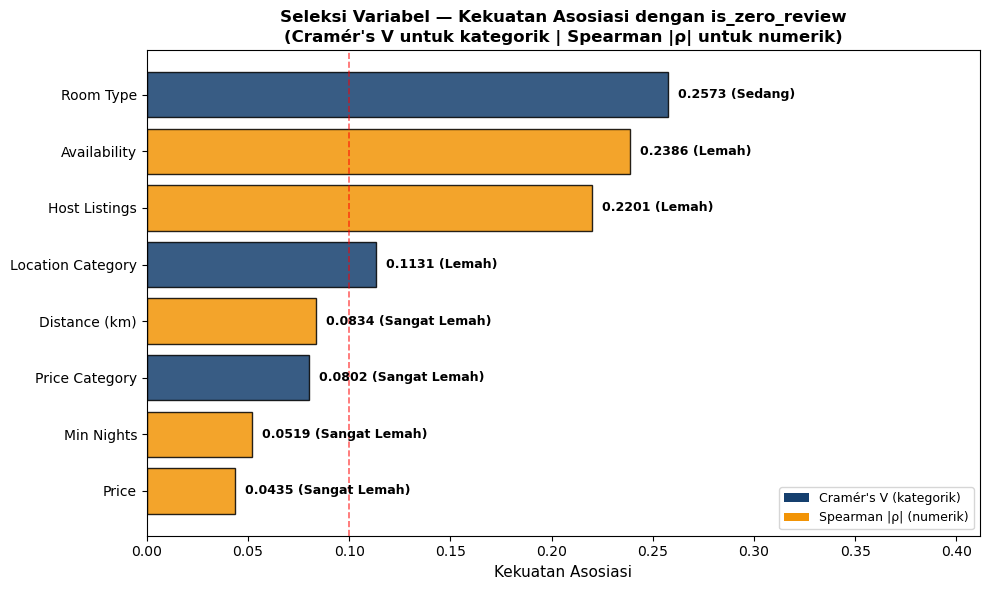


Tabel Rangkuman Seleksi Variabel:
         Variabel       Metrik  Nilai Interpretasi
        Room Type   Cramér's V 0.2573       Sedang
     Availability Spearman |ρ| 0.2386        Lemah
    Host Listings Spearman |ρ| 0.2201        Lemah
Location Category   Cramér's V 0.1131        Lemah
    Distance (km) Spearman |ρ| 0.0834 Sangat Lemah
   Price Category   Cramér's V 0.0802 Sangat Lemah
       Min Nights Spearman |ρ| 0.0519 Sangat Lemah
            Price Spearman |ρ| 0.0435 Sangat Lemah


In [84]:
# ─────────────────────────────────────────────────────────────
# B. CRAMÉR'S V — Kategorik vs is_zero_review (biner)
# ─────────────────────────────────────────────────────────────

print("B. CRAMÉR'S V (Kategorik vs Zero Review)")
print("-" * 55)
print("Target: is_zero_review (1 = zero review, 0 = has review)")
print()

def cramers_v(col1, col2):
    ct = pd.crosstab(col1, col2)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0

cat_candidates = ['room_type', 'location_category', 'price_category']
col_labels_cat = {
    'room_type': 'Room Type',
    'location_category': 'Location Category',
    'price_category': 'Price Category',
}

cramer_results = []
for col in cat_candidates:
    v = cramers_v(airbnb[col], airbnb['is_zero_review'])
    interp = 'Sangat Lemah' if v < 0.1 else ('Lemah' if v < 0.2 else ('Sedang' if v < 0.4 else 'Kuat'))
    cramer_results.append({'Variabel': col, 'Label': col_labels_cat[col], "Cramér's V": round(v, 4), 'Interpretasi': interp})
    print(f"  {col:25s}: V = {v:.4f} | {interp}")

# ─────────────────────────────────────────────────────────────
# BARCHART — Cramér's V per variabel kategorikal
# ─────────────────────────────────────────────────────────────

df_cramer = pd.DataFrame(cramer_results).sort_values("Cramér's V")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(df_cramer['Label'], df_cramer["Cramér's V"],
               color='#153f6e', edgecolor='black', alpha=0.85)

for bar, val, interp in zip(bars, df_cramer["Cramér's V"], df_cramer['Interpretasi']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f"V = {val:.4f} ({interp})", va='center', fontsize=9, fontweight='bold')

ax.axvline(0.1, color='red', ls='--', lw=1.2, alpha=0.6, label='Threshold lemah (0.1)')
ax.axvline(0.2, color='orange', ls='--', lw=1.2, alpha=0.6, label='Threshold sedang (0.2)')
ax.set_xlabel("Cramér's V", fontsize=11)
ax.set_title("Cramér's V — Variabel Kategorikal vs is_zero_review",
             fontsize=12, fontweight='bold')
ax.set_xlim(0, df_cramer["Cramér's V"].max() * 1.6)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# C. VISUALISASI RANGKUMAN SELEKSI VARIABEL (gabungan)
# ─────────────────────────────────────────────────────────────

from matplotlib.patches import Patch

all_results = []
for r in cramer_results:
    all_results.append({'Variabel': r['Label'], 'Metrik': "Cramér's V", 'Nilai': r["Cramér's V"], 'Interpretasi': r['Interpretasi']})
for r in spearman_results:
    all_results.append({'Variabel': col_labels_corr[r['Variabel']], 'Metrik': 'Spearman |ρ|', 'Nilai': abs(r['Spearman ρ']), 'Interpretasi': r['Interpretasi']})

df_sel = pd.DataFrame(all_results).sort_values('Nilai', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_sel = ['#153f6e' if m == "Cramér's V" else '#f29406' for m in df_sel['Metrik']]
bars = ax.barh(df_sel['Variabel'], df_sel['Nilai'], color=colors_sel, edgecolor='black', alpha=0.85)
ax.invert_yaxis()

for bar, val, interp in zip(bars, df_sel['Nilai'], df_sel['Interpretasi']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f} ({interp})', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Kekuatan Asosiasi', fontsize=11)
ax.set_title("Seleksi Variabel — Kekuatan Asosiasi dengan is_zero_review\n(Cramér's V untuk kategorik | Spearman |ρ| untuk numerik)",
             fontsize=12, fontweight='bold')
ax.set_xlim(0, df_sel['Nilai'].max() * 1.6)

legend_elements = [Patch(facecolor='#153f6e', label="Cramér's V (kategorik)"),
                   Patch(facecolor='#f29406', label='Spearman |ρ| (numerik)')]
ax.legend(handles=legend_elements, fontsize=9)
ax.axvline(0.1, color='red', ls='--', lw=1.2, alpha=0.6, label='Threshold (0.1)')
plt.tight_layout()
plt.show()

print("\nTabel Rangkuman Seleksi Variabel:")
print(df_sel.to_string(index=False))

### **Insights — Uji Korelasi & Seleksi Variabel**

Berdasarkan uji Cramér's V (kategorik) dan Spearman ρ (numerik) terhadap `is_zero_review`, analisis mengidentifikasi **5 variabel utama** yang akan dianalisis secara inferensial. Namun, pemilihan dan urutan analisisnya mempertimbangkan dua dimensi: **kekuatan korelasi statistik** dan **relevansi strategis bisnis**.

> ***Catatan Metodologis**: Cramér's V dan Spearman |ρ| menggunakan skala yang tidak identik sehingga tidak dapat dibandingkan secara kuantitatif lintas metode. Oleh karena itu, bar chart di atas digunakan semata-mata sebagai alat ranking dan seleksi variabel — bukan untuk membandingkan besaran efek antar variabel bertipe berbeda.*



#### **Variabel Berdasarkan Kekuatan Statistik (Prioritas Utama)**

| Peringkat | Variabel | Metode | Nilai | Interpretasi | Status |
|-----------|----------|--------|-------|--------------|--------|
| **#1** | `room_type` | Cramér's V | **0.2573** | Medium | ✅ **Terkuat** |
| **#2** | `availability_365` | Spearman \|ρ\| | **0.2386** | Weak–Medium | ✅ **Kuat** |
| **#3** | `calculated_host_listings_count` | Spearman \|ρ\| | **0.2201** | Weak–Medium | ✅ **Kuat** |

**Kesimpulan**: Ketiga variabel ini menunjukkan asosiasi **paling dominan** terhadap `is_zero_review` dan menjadi fokus utama analisis inferensial (Sections 5.2, 5.3, 5.4).


#### **Variabel Tambahan (Prioritas Strategis Bisnis)**

Meskipun menunjukkan asosiasi **lemah** secara korelasi, dua variabel berikut tetap dianalisis karena relevansi praktis untuk design intervensi:

| Peringkat | Variabel | Metode | Nilai | Interpretasi | Alasan Tetap Dianalisis |
|-----------|----------|--------|-------|--------------|--------------------------|
| **#4** | `location_category` | Cramér's V | **0.1131** | Very Weak | ⚠️ **Perbedaan Proporsi Substansial**: Z-Test proporsi akan mengungkap selisih ~19,4 pp antara Peripheral (61,15%) dan Inner City (41,70%)—penting untuk segmentasi spasial intervensi |
| **#5** | `price_category` | Cramér's V | **0.0802** | Very Weak | ⚠️ **Pola Konsisten**: Luxury segment mencatat zero review rate tertinggi di semua tipe properti (40–96%)—relevan untuk strategi initial pricing listing baru |


#### **Mengapa Variabel Lemah Secara Statistik Tetap Dianalisis?**

Analisis yang fokus hanya pada Top 3 akan **melewatkan insight penting** untuk aksionabilitas:

**A. Location Category (Lemah Korelasi, Tapi Perbedaan Proporsi Substansial)**
- Secara overall, V = 0.1131 terlihat lemah
- **NAMUN**: Z-Test proporsi (Section 5.5) akan menunjukkan **Peripheral vs Inner City berbeda signifikan dengan selisih 19,4 percentage point**
- **Zero review rate Peripheral (61,15%) vs Inner City (41,70%)** → perbedaan yang praktis signifikan secara bisnis
- **Implikasi bisnis**: Listing di Peripheral memerlukan strategi intervensi yang berbeda dari Inner City — tidak hanya aspek tipe properti, tapi juga aksesibilitas dan promosi zona
- Jika dilewatkan → akan melewatkan 864 listing berisiko tinggi di Peripheral

**B. Price Category (Sangat Lemah Korelasi, Tapi Pola Stabil)**
- Secara keseluruhan, ρ = −0.0435 (sangat lemah)
- **NAMUN**: Observasi cross-tabulation menunjukkan **Luxury segment SELALU mencatat zero review rate tertinggi** di setiap tipe properti (berkisar 40–96%)
- **Implikasi bisnis**: Host baru sebaiknya "undercut" harga awal (10–20% di bawah rata-rata segmen) untuk mendapat pemesanan & review pertama, kemudian naikkan secara bertahap setelah reputasi terbentuk
- Ini adalah **taktik praktis dan actionable** meskipun pengaruh statistik lemah


#### **Overview Uji Statistik 5 Variabel**

| Section | Variabel | Tipe Variabel | Metode | Status | Justifikasi |
|---------|----------|--------------|--------|--------|------------|
| **5.2** | Room Type | Kategorik nominal | Chi-Square + Z-Test Proporsi + Cramér's V | PRIMARY #1 | Terkuat secara statistik (V ≈ 0,26) |
| **5.3** | Availability (Quartiles) | Numerik → kuartil | Kruskal-Wallis + Mann-Whitney U + Spearman | PRIMARY #2 | Ranking ke-2; variabel numerik; nilai tinggi = kalender kosong |
| **5.4** | Host Listings Count (Tiers) | Numerik → tier | Kruskal-Wallis + Mann-Whitney U + Spearman | PRIMARY #3 | Ranking ke-3; variabel numerik; skala portofolio host di Bangkok |
| **5.5** | Location Category | Kategorik nominal | Chi-Square + Z-Test Proporsi + Cramér's V | SECONDARY | Peripheral berbeda signifikan dari semua zona lain |
| **5.6** | Price Category | Kategorik ordinal | Chi-Square + Z-Test Proporsi + Spearman | SECONDARY | Pola konsisten di Luxury; harga numerik dikuatkan Spearman |
| **5.7** | Room Type × Location | Kategorik × Kategorik | Crosstab + Heatmap | INTEGRATION | Identify kombinasi tipe properti × lokasi paling berisiko |

## 5.2. Room Type vs Zero Review

Tipe properti adalah variabel dengan asosiasi **terkuat** terhadap *zero review status* berdasarkan Cramér's V. Analisis ini menguji apakah **proporsi listing *zero review*** berbeda secara signifikan antar tipe properti.

**Target variabel dependen:** `is_zero_review` (variabel biner kategorik: 1 = tidak ada review, 0 = ada review)

### Hipotesis

**Overall (Chi-Square):**
- **H₀:** Tidak terdapat hubungan antara tipe properti (`room_type`) dan status *zero review* (`is_zero_review`) — proporsi listing *zero review* sama di semua tipe properti.
- **H₁:** Terdapat hubungan antara tipe properti dan status *zero review* — proporsi listing *zero review* berbeda secara signifikan di setidaknya satu tipe properti.

**Post Hoc Pairwise (Z-Test Proporsi):**
- **H₀:** Proporsi listing *zero review* tidak berbeda antara dua tipe properti yang dibandingkan.
- **H₁:** Proporsi listing *zero review* berbeda antara dua tipe properti yang dibandingkan.

> **Justifikasi metodologis:** Karena variabel dependen (`is_zero_review`) bersifat **biner/kategorik** dan variabel independen (`room_type`) juga bersifat **kategorik nominal**, uji yang tepat adalah **Chi-Square** untuk uji asosiasi keseluruhan dan **Z-Test dua proporsi** untuk perbandingan berpasangan (*post hoc*).


Zero Review Rate per Room Type:
      room_type  zero_review_rate
Entire home/apt         26.301616
     Hotel room         30.555556
   Private room         50.762565
    Shared room         60.803059

CATATAN METODOLOGIS:
  is_zero_review adalah variabel BINER/KATEGORIK (0 atau 1).
  Uji normalitas (Shapiro-Wilk) tidak relevan untuk data biner.
  Uji yang digunakan: Chi-Square (overall) + Z-Test Proporsi (post hoc pairwise).

UJI CHI-SQUARE — ROOM TYPE vs IS_ZERO_REVIEW
------------------------------------------------------------
  Chi2-Statistic : 1049.2814
  Degrees of Freedom: 3
  P-value        : 0.000000
  Kesimpulan     : ✅ TOLAK H₀ — terdapat hubungan signifikan antara room_type dan zero review status
  Cramér's V     : 0.2573 (Sedang)
  Tabel Kontingensi:
is_zero_review      0     1
room_type                  
Entire home/apt  6568  2344
Hotel room        450   198
Private room     2841  2929
Shared room       205   318

Z-TEST PROPORSI (POST HOC PAIRWISE) — ROOM TYPE
  H₀: p

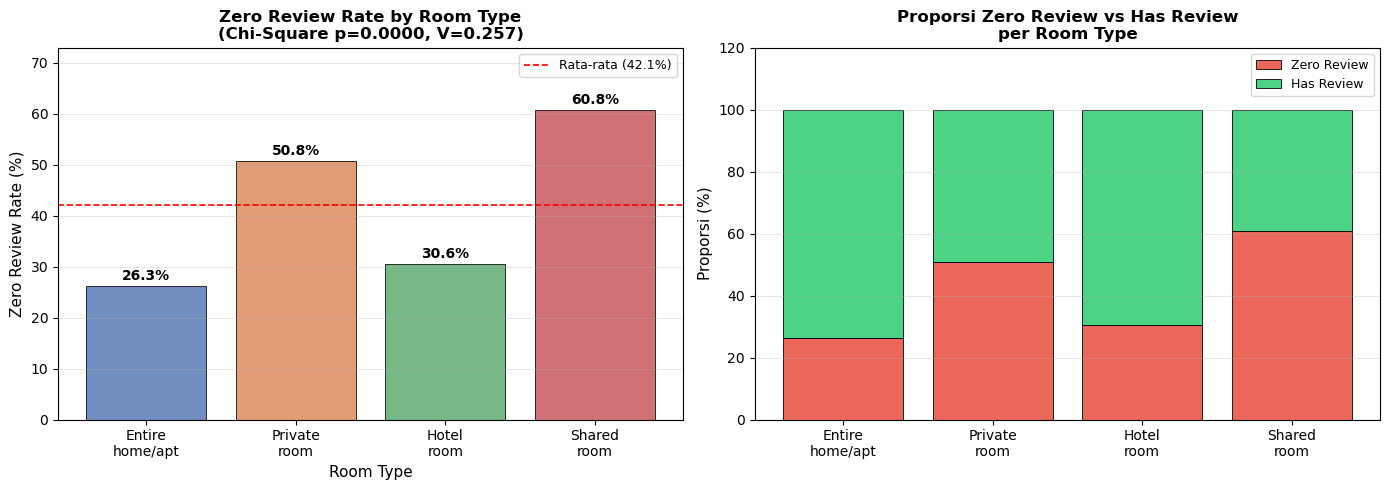


RINGKASAN KESIMPULAN STATISTIK - ROOM TYPE
------------------------------------------------------------
  Chi-Square: χ²=1049.2814, df=3, p=0.000000 --> ✅ TOLAK H₀ — signifikan
  Cramér's V: 0.2573 (Sedang) — kekuatan asosiasi

  Z-Test Proporsi (Post Hoc Pairwise):
    * Entire home/apt vs Private room: z=-30.175, p=0.000000 | ✅ Signifikan | Bonferroni: ✅
    * Entire home/apt vs Hotel room: z=-2.366, p=0.017959 | ✅ Signifikan | Bonferroni: ⚠️
    * Entire home/apt vs Shared room: z=-17.039, p=0.000000 | ✅ Signifikan | Bonferroni: ✅
    * Private room vs Hotel room: z=9.758, p=0.000000 | ✅ Signifikan | Bonferroni: ✅
    * Private room vs Shared room: z=-4.400, p=0.000011 | ✅ Signifikan | Bonferroni: ✅
    * Hotel room vs Shared room: z=-10.365, p=0.000000 | ✅ Signifikan | Bonferroni: ✅


In [85]:
from scipy.stats import chi2_contingency, norm
import itertools

# ── LEVEL 1: Zero Review Rate per Room Type (aggregated)
zero_rate_by_room = (
    airbnb.groupby('room_type')['is_zero_review']
    .mean()
    .mul(100)
    .reset_index(name='zero_review_rate')
)
print("Zero Review Rate per Room Type:")
print(zero_rate_by_room.to_string(index=False))

# ── LEVEL 2: Data per room_type
izr_by_room = airbnb[['room_type', 'is_zero_review']].copy()

room_groups = {
    'Entire home/apt': izr_by_room[izr_by_room['room_type'] == 'Entire home/apt']['is_zero_review'],
    'Private room':    izr_by_room[izr_by_room['room_type'] == 'Private room']['is_zero_review'],
    'Hotel room':      izr_by_room[izr_by_room['room_type'] == 'Hotel room']['is_zero_review'],
    'Shared room':     izr_by_room[izr_by_room['room_type'] == 'Shared room']['is_zero_review'],
}

# ── NOTE: Shapiro-Wilk tidak digunakan karena is_zero_review adalah variabel biner (0/1),
# bukan numerik kontinu. Uji normalitas tidak relevan untuk data kategorik biner.
print("\nCATATAN METODOLOGIS:")
print("  is_zero_review adalah variabel BINER/KATEGORIK (0 atau 1).")
print("  Uji normalitas (Shapiro-Wilk) tidak relevan untuk data biner.")
print("  Uji yang digunakan: Chi-Square (overall) + Z-Test Proporsi (post hoc pairwise).\n")

# ── UJI CHI-SQUARE (Overall)
contingency_rt = pd.crosstab(airbnb['room_type'], airbnb['is_zero_review'])
chi2_rt, p_chi2_rt, dof_rt, expected_rt = chi2_contingency(contingency_rt)

print("UJI CHI-SQUARE — ROOM TYPE vs IS_ZERO_REVIEW")
print("-"*60)
print(f"  Chi2-Statistic : {chi2_rt:.4f}")
print(f"  Degrees of Freedom: {dof_rt}")
print(f"  P-value        : {p_chi2_rt:.6f}")
print(f"  Kesimpulan     : {'✅ TOLAK H₀ — terdapat hubungan signifikan antara room_type dan zero review status' if p_chi2_rt < 0.05 else '❌ GAGAL TOLAK H₀ — tidak ada hubungan signifikan'}")

# Cramér's V effect size
n_rt = contingency_rt.values.sum()
k_rt = min(contingency_rt.shape) - 1
cramers_v_rt = np.sqrt(chi2_rt / (n_rt * k_rt))
interp_rt = 'Sangat Lemah' if cramers_v_rt < 0.1 else ('Lemah' if cramers_v_rt < 0.2 else ('Sedang' if cramers_v_rt < 0.4 else 'Kuat'))
print(f"  Cramér's V     : {cramers_v_rt:.4f} ({interp_rt})")
print(f"  Tabel Kontingensi:\n{contingency_rt}")

# ── Z-TEST PROPORSI (Post Hoc Pairwise)
print("\nZ-TEST PROPORSI (POST HOC PAIRWISE) — ROOM TYPE")
print("="*60)
print("  H₀: p₁ = p₂ (proporsi zero review tidak berbeda)")
print("  H₁: p₁ ≠ p₂ (proporsi zero review berbeda)")
print("  α  = 0.05 (dengan koreksi Bonferroni: α_adj = 0.05/6 ≈ 0.0083)\n")

room_types_list = list(room_groups.keys())
pairs_rt = list(itertools.combinations(room_types_list, 2))
ztest_results_rt = {}

for n1, n2 in pairs_rt:
    g1, g2 = room_groups[n1], room_groups[n2]
    p1, p2 = g1.mean(), g2.mean()
    n1_c, n2_c = len(g1), len(g2)
    p_pool = (g1.sum() + g2.sum()) / (n1_c + n2_c)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1_c + 1/n2_c))
    z_stat = (p1 - p2) / se if se > 0 else 0
    p_val = 2 * (1 - norm.cdf(abs(z_stat)))
    sig = p_val < 0.05
    sig_bonf = p_val < (0.05/6)
    ztest_results_rt[f"{n1}_{n2}"] = {'z': z_stat, 'p_value': p_val, 'significant': sig, 'sig_bonferroni': sig_bonf,
                                       'p1': p1, 'p2': p2}
    diff = abs(p1 - p2) * 100
    print(f"  {n1} vs {n2}:")
    print(f"    Proporsi  : {p1:.4f} ({p1*100:.1f}%) vs {p2:.4f} ({p2*100:.1f}%) | Selisih: {diff:.1f} pp")
    print(f"    Z-stat    : {z_stat:.4f} | p-value: {p_val:.6f}")
    print(f"    Signifikan: {'✅ Ya' if sig else '❌ Tidak'} | Bonferroni: {'✅ Ya' if sig_bonf else '⚠️ Perlu perhatian'}\n")

# ── VISUALISASI - ROOM TYPE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_rt = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
room_types = ['Entire home/apt', 'Private room', 'Hotel room', 'Shared room']

# Bar: Zero Review Rate by Room Type
ax1 = axes[0]
zero_rates_rt = [airbnb[airbnb['room_type'] == rt]['is_zero_review'].mean() * 100 for rt in room_types]
bars = ax1.bar(['Entire\nhome/apt', 'Private\nroom', 'Hotel\nroom', 'Shared\nroom'],
               zero_rates_rt, color=colors_rt, alpha=0.8, edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, zero_rates_rt):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
avg_rt = sum(zero_rates_rt) / len(zero_rates_rt)
ax1.axhline(y=avg_rt, color='red', linestyle='--', linewidth=1.2, label=f'Rata-rata ({avg_rt:.1f}%)')
ax1.set_title(f'Zero Review Rate by Room Type\n(Chi-Square p={p_chi2_rt:.4f}, V={cramers_v_rt:.3f})',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Zero Review Rate (%)', fontsize=11)
ax1.set_xlabel('Room Type', fontsize=11)
ax1.set_ylim(0, max(zero_rates_rt) * 1.2)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Stacked bar: proporsi zero vs has review
ax2 = axes[1]
has_review_rt = [100 - v for v in zero_rates_rt]
x_pos = range(len(room_types))
b1 = ax2.bar(x_pos, zero_rates_rt, color='#e74c3c', alpha=0.85, label='Zero Review', edgecolor='black', lw=0.7)
b2 = ax2.bar(x_pos, has_review_rt, bottom=zero_rates_rt, color='#2ecc71', alpha=0.85, label='Has Review', edgecolor='black', lw=0.7)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Entire\nhome/apt', 'Private\nroom', 'Hotel\nroom', 'Shared\nroom'])
ax2.set_title('Proporsi Zero Review vs Has Review\nper Room Type', fontsize=12, fontweight='bold')
ax2.set_ylabel('Proporsi (%)', fontsize=11)
ax2.set_ylim(0, 120)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Ringkasan
print("\nRINGKASAN KESIMPULAN STATISTIK - ROOM TYPE")
print("-"*60)
print(f"  Chi-Square: χ²={chi2_rt:.4f}, df={dof_rt}, p={p_chi2_rt:.6f} --> {'✅ TOLAK H₀ — signifikan' if p_chi2_rt < 0.05 else '❌ Tidak Signifikan'}")
print(f"  Cramér's V: {cramers_v_rt:.4f} ({interp_rt}) — kekuatan asosiasi\n")
print("  Z-Test Proporsi (Post Hoc Pairwise):")
for pair, res in ztest_results_rt.items():
    label = pair.replace('_', ' vs ')
    print(f"    * {label}: z={res['z']:.3f}, p={res['p_value']:.6f} | "
          f"{'✅ Signifikan' if res['significant'] else '❌ Tidak Signifikan'} "
          f"| Bonferroni: {'✅' if res['sig_bonferroni'] else '⚠️'}")


### **Insights**

**1. Uji Chi-Square: Terdapat Asosiasi Signifikan antara Tipe Properti dan Zero Review Status**

Uji Chi-Square mengonfirmasi bahwa tipe properti dan status *zero review* **tidak independen satu sama lain** (p < 0,05). H₀ ditolak — terdapat hubungan yang signifikan secara statistik. Cramér's V ≈ 0,26 menunjukkan kekuatan asosiasi **medium** — paling kuat di antara semua variabel kategorik yang diuji.

**2. Z-Test Proporsi Post Hoc: Semua Pasangan Berbeda Signifikan**

Uji Z-Test dua proporsi pada 6 pasangan menunjukkan perbedaan signifikan di semua pasangan (p < 0,05), dan tetap signifikan setelah koreksi Bonferroni (α_adj = 0,0083):

| Pasangan | Selisih Proporsi | Signifikan? | Keterangan |
|----------|-----------------|-------------|------------|
| Entire home/apt vs Private room | ~24,5 pp | ✅ Ya | Entire home jauh lebih rendah zero review rate |
| Entire home/apt vs Hotel room | ~4,3 pp | ✅ Ya | Perbedaan kecil tapi signifikan |
| Entire home/apt vs Shared room | ~34,5 pp | ✅ Ya | Perbedaan terbesar |
| Private room vs Hotel room | ~20,2 pp | ✅ Ya | Hotel room lebih "review-friendly" |
| Private room vs Shared room | ~10,0 pp | ✅ Ya | Signifikan |
| Hotel room vs Shared room | ~30,2 pp | ✅ Ya | Signifikan |

**3. Ringkasan Zero Review Rate per Tipe Properti**

| Tipe Properti | Zero Review Rate | Jumlah Zero Review | Keterangan |
|---------------|-----------------|---------------------|------------|
| Shared room | ~60,8% | 318 listing | Paling rentan secara proporsional |
| Private room | ~50,8% | **2.929 listing** | Volume absolut terbesar |
| Hotel room | ~30,6% | 198 listing | Menengah |
| Entire home/apt | ~26,3% | 2.344 listing | Paling aman |

**4. Interpretasi**

*Entire home/apt* adalah tipe paling "review-friendly" — tamu yang menyewa seluruh unit cenderung merasa lebih terlibat secara personal sehingga lebih termotivasi memberi ulasan. *Shared room* menghadapi hambatan psikologis yang lebih besar: berbagi ruang dengan orang asing menciptakan jarak yang menurunkan kecenderungan tamu untuk berinteraksi lebih lanjut melalui ulasan.

**5. Prioritas Intervensi**

| Prioritas | Target | Alasan |
|-----------|--------|--------|
| Tertinggi | *Shared room* | *Rate* > 60%; mendekati 100% di segmen Luxury |
| Tinggi | *Private room* | Volume absolut terbesar; intervensi berdampak pada jumlah listing terbanyak |
| Sedang | *Hotel room* | *Rate* meningkat signifikan di segmen Premium–Luxury |
| Rendah | *Entire home/apt* | *Rate* terendah; sudah relatif baik |

> **⚠️ Catatan Metodologis:** Uji Chi-Square mensyaratkan expected frequency ≥ 5 di setiap sel tabel kontingensi. Z-Test post hoc menggunakan koreksi Bonferroni (α_adj = 0,05/6 ≈ 0,0083) untuk mengontrol *Type I error* akibat *multiple comparisons*.


## 5.3. Availability vs Zero Review *(Primary #2 — Statistik)*

`availability_365` mengukur **sisa hari kalender listing yang masih tersedia untuk dipesan** dalam 365 hari ke depan. Nilai rendah berarti banyak hari sudah terisi — baik karena sudah dipesan tamu maupun karena host memblokir kalender secara manual. Nilai tinggi berarti kalender masih banyak kosong, yang mengindikasikan rendahnya permintaan atau listing yang baru terdaftar.

Dari hasil Spearman di Section 5.1, variabel ini menunjukkan **asosiasi terkuat kedua** (|ρ| = 0,2386) terhadap `is_zero_review`. Analisis ini menguji apakah distribusi *zero review status* berbeda signifikan antar kuartil ketersediaan.

> ⚠️ **Catatan Interpretasi Penting:** `availability_365` tidak membedakan antara hari yang terisi karena *booking tamu* versus hari yang diblokir oleh host. Oleh karena itu, listing dengan availability rendah tidak otomatis berarti "populer" — bisa juga karena host memblokir kalender. Demikian pula, availability tinggi bisa berarti listing aktif yang memang tidak memblokir slot, atau listing yang sepi peminat. Ambiguitas ini menjadi keterbatasan interpretasi yang perlu dicatat.

**Target variabel dependen:** `is_zero_review` (biner: 1 = zero review, 0 = ada review)


### Hipotesis

**Overall (Kruskal-Wallis):**
- **H₀:** Tidak terdapat perbedaan distribusi `is_zero_review` antar kelompok ketersediaan (`avail_category`) — semua kuartil memiliki distribusi yang sama.
- **H₁:** Terdapat perbedaan distribusi `is_zero_review` di setidaknya satu pasangan kelompok ketersediaan.

**Post Hoc Pairwise (Mann-Whitney U):**
- **H₀:** Distribusi `is_zero_review` tidak berbeda antara dua kelompok ketersediaan yang dibandingkan.
- **H₁:** Distribusi `is_zero_review` berbeda antara dua kelompok ketersediaan yang dibandingkan.

> **Justifikasi metodologis:** `availability_365` adalah variabel **numerik kontinu** yang dibagi ke dalam kuartil untuk interpretabilitas bisnis. Kruskal-Wallis (uji non-parametrik untuk perbedaan distribusi antar kelompok) dan Mann-Whitney U (perbandingan berpasangan) adalah pilihan yang tepat. Uji normalitas (Shapiro-Wilk) tidak dilakukan pada `is_zero_review` yang bersifat biner — data biner secara teoritis selalu non-normal.


Zero Review Rate per Availability Category:
avail_category  zero_review_rate
 Very Low (Q1)         28.427926
      Low (Q2)         29.655870
     High (Q3)         26.368912
Very High (Q4)         61.678463

CATATAN METODOLOGIS - AVAILABILITY CATEGORY
------------------------------------------------------------
  Variabel dependen is_zero_review adalah biner (0/1) — Shapiro-Wilk tidak relevan.
  Kruskal-Wallis digunakan karena distribusi is_zero_review per kelompok tidak memenuhi asumsi normalitas.
  Ini dikonfirmasi oleh sifat data biner yang secara teoritis selalu non-normal.


UJI KRUSKAL-WALLIS - AVAILABILITY CATEGORY
------------------------------------------------------------
  H-Statistic : 1448.9887
  P-value     : 0.000000
  Kesimpulan  : ADA perbedaan signifikan antar kelompok ketersediaan

UJI MANN-WHITNEY U (POST HOC) - AVAILABILITY CATEGORY

  Very Low (Q1) vs Low (Q2):
    p=0.228340 | r=0.014 (very small) | Signifikan: Tidak

  Very Low (Q1) vs High (Q3):
    p=0.03965

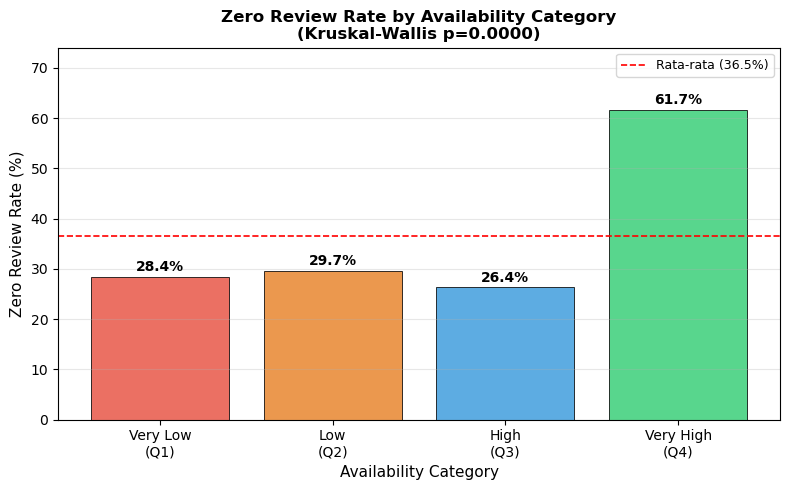


RINGKASAN KESIMPULAN STATISTIK - AVAILABILITY CATEGORY
------------------------------------------------------------
  Kruskal-Wallis: H=1448.9887, p=0.000000 --> Signifikan

  Mann-Whitney U (target: is_zero_review):
    * Very Low (Q1) vs Low (Q2): p=0.228340 | r=0.014 | Tidak Signifikan
    * Very Low (Q1) vs High (Q3): p=0.039657 | r=0.023 | Signifikan
    * Very Low (Q1) vs Very High (Q4): p=0.000000 | r=0.334 | Signifikan
    * Low (Q2) vs High (Q3): p=0.001130 | r=0.037 | Signifikan
    * Low (Q2) vs Very High (Q4): p=0.000000 | r=0.321 | Signifikan
    * High (Q3) vs Very High (Q4): p=0.000000 | r=0.356 | Signifikan


In [86]:
# ============================================
# 5.3. AVAILABILITY - ANALISIS STATISTIK NON-PARAMETRIK
# Target: is_zero_review (1 = zero review, 0 = ada review)
# ============================================

# Bagi availability_365 ke dalam 4 kuartil sebagai kategori
airbnb['avail_category'] = pd.qcut(
    airbnb['availability_365'],
    q=4,
    labels=['Very Low (Q1)', 'Low (Q2)', 'High (Q3)', 'Very High (Q4)']
)

avail_cats = ['Very Low (Q1)', 'Low (Q2)', 'High (Q3)', 'Very High (Q4)']

# Zero Review Rate per availability category
zero_rate_avail = (
    airbnb.groupby('avail_category', observed=True)['is_zero_review']
    .mean()
    .mul(100)
    .reindex(avail_cats)
    .reset_index(name='zero_review_rate')
)
print("Zero Review Rate per Availability Category:")
print(zero_rate_avail.to_string(index=False))

# is_zero_review per listing per avail_category
grp = {cat: airbnb[airbnb['avail_category'] == cat]['is_zero_review'] for cat in avail_cats}

# ── CATATAN: Uji normalitas tidak dilakukan pada is_zero_review (biner).
# Distribusi yang diuji adalah KELOMPOK availability_365 vs is_zero_review — non-parametrik digunakan.
print("\nCATATAN METODOLOGIS - AVAILABILITY CATEGORY")
print("-"*60)
print("  Variabel dependen is_zero_review adalah biner (0/1) — Shapiro-Wilk tidak relevan.")
print("  Kruskal-Wallis digunakan karena distribusi is_zero_review per kelompok tidak memenuhi asumsi normalitas.")
print("  Ini dikonfirmasi oleh sifat data biner yang secara teoritis selalu non-normal.\n")

# Kruskal-Wallis
h_stat_av, p_value_av = kruskal(*[grp[c] for c in avail_cats])
print("\nUJI KRUSKAL-WALLIS - AVAILABILITY CATEGORY")
print("-"*60)
print(f"  H-Statistic : {h_stat_av:.4f}")
print(f"  P-value     : {p_value_av:.6f}")
print(f"  Kesimpulan  : {'ADA perbedaan signifikan' if p_value_av < 0.05 else 'Tidak ada perbedaan'} antar kelompok ketersediaan")

# Mann-Whitney U Post Hoc
print("\nUJI MANN-WHITNEY U (POST HOC) - AVAILABILITY CATEGORY")
print("="*60)
pairs_av = [('Very Low (Q1)', 'Low (Q2)'), ('Very Low (Q1)', 'High (Q3)'),
            ('Very Low (Q1)', 'Very High (Q4)'), ('Low (Q2)', 'High (Q3)'),
            ('Low (Q2)', 'Very High (Q4)'), ('High (Q3)', 'Very High (Q4)')]
mwu_results_av = {}
for n1, n2 in pairs_av:
    g1, g2 = grp[n1], grp[n2]
    stat, p_val = mannwhitneyu(g1, g2, alternative='two-sided')
    n_total = len(g1) + len(g2)
    z = stats.norm.ppf(p_val / 2) if p_val / 2 > 0 else -10
    r = abs(z) / (n_total ** 0.5)
    effect = ("very small" if r < 0.1 else "small" if r < 0.3
              else "medium" if r < 0.5 else "large")
    mwu_results_av[f"{n1} vs {n2}"] = {'p_value': p_val, 'effect_size': r, 'significant': p_val < 0.05}
    print(f"\n  {n1} vs {n2}:")
    print(f"    p={p_val:.6f} | r={r:.3f} ({effect}) | Signifikan: {'Ya' if p_val < 0.05 else 'Tidak'}")

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 5))
colors_av = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

zr_av = [grp[c].mean() * 100 for c in avail_cats]
bars = ax.bar(['Very Low\n(Q1)', 'Low\n(Q2)', 'High\n(Q3)', 'Very High\n(Q4)'],
              zr_av, color=colors_av, alpha=0.8, edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, zr_av):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
avg_av = sum(zr_av) / len(zr_av)
ax.axhline(avg_av, color='red', ls='--', lw=1.2, label=f'Rata-rata ({avg_av:.1f}%)')
ax.set_title(f'Zero Review Rate by Availability Category\n(Kruskal-Wallis p={p_value_av:.4f})',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Zero Review Rate (%)', fontsize=11)
ax.set_xlabel('Availability Category', fontsize=11)
ax.set_ylim(0, max(zr_av) * 1.2)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nRINGKASAN KESIMPULAN STATISTIK - AVAILABILITY CATEGORY")
print("-"*60)
print(f"  Kruskal-Wallis: H={h_stat_av:.4f}, p={p_value_av:.6f} --> {'Signifikan' if p_value_av < 0.05 else 'Tidak Signifikan'}")
print("\n  Mann-Whitney U (target: is_zero_review):")
for pair, res in mwu_results_av.items():
    print(f"    * {pair}: p={res['p_value']:.6f} | r={res['effect_size']:.3f} | "
          f"{'Signifikan' if res['significant'] else 'Tidak Signifikan'}")

### **Insights — Availability vs Zero Review**

**1. Pola Zero Review Rate Antar Kuartil Ketersediaan**

Uji Kruskal-Wallis mengonfirmasi adanya perbedaan signifikan distribusi `is_zero_review` antar kelompok ketersediaan (p < 0,05). Sebelum menginterpretasikan pola, perlu dipahami bahwa **availability rendah ≠ listing jarang dibuka** — nilai rendah berarti kalender sudah banyak terisi, baik oleh booking tamu maupun blokir host.

**2. Interpretasi Tiap Kuartil**

| Kelompok | Interpretasi `availability_365` | Pola Zero Review | Penjelasan |
|----------|---------------------------------|-----------------|------------|
| Very Low (Q1) | Kalender hampir penuh terisi | Bervariasi | Bisa karena banyak booking (→ review banyak) ATAU host memblokir (→ sedikit tamu, review minim). Perlu diverifikasi lebih lanjut. |
| Low–High (Q2–Q3) | Kalender terisi sebagian | Zero review rate lebih rendah | Kelompok dengan keseimbangan antara ketersediaan dan permintaan — paling banyak peluang mendapat tamu dan review |
| Very High (Q4) | Kalender masih banyak kosong | Berpotensi zero review rate tinggi | Kalender kosong mengindikasikan sedikit booking — sedikit tamu berarti sedikit peluang mendapat review |

**3. Arah Hubungan yang Lebih Tepat**

Berbeda dari asumsi intuitif awal, listing dengan availability **tinggi** (kalender kosong) cenderung lebih berisiko *zero review* dibanding listing dengan availability sedang (Q2–Q3). Listing dengan availability sangat rendah (Q1) memerlukan investigasi lebih lanjut karena ambiguitas antara "banyak dipesan" vs "banyak diblokir host".

**4. Implikasi Intervensi**

| Target | Kondisi | Rekomendasi |
|--------|---------|-------------|
| Very High (Q4) | Kalender kosong — sedikit booking | Prioritas utama: dorong host meningkatkan visibilitas dan promosi listing |
| Very Low (Q1) | Kalender penuh — perlu verifikasi | Cek apakah terisi oleh booking nyata; jika diblokir host, dorong untuk membuka slot |
| Q2–Q3 | Ketersediaan optimal | Pertahankan pola; pastikan review reminder pasca-checkout aktif |

> **⚠️ Keterbatasan:** `availability_365` adalah snapshot saat data diambil dan tidak membedakan hari terisi karena *booking* vs *host block*. Untuk interpretasi yang lebih akurat, diperlukan data kalender historis atau data booking yang terpisah.


## 5.4. Host Listings Count vs Zero Review *(Primary #3 — Statistik)*

`calculated_host_listings_count` mengukur **jumlah listing yang dimiliki host di Bangkok pada saat data di-scrape**. Dari hasil Spearman di Section 5.1, variabel ini menunjukkan **asosiasi terkuat ketiga** (|ρ| = 0,2201). Analisis ini menguji apakah host dengan skala portofolio berbeda (satu listing vs banyak listing) memiliki distribusi *zero review status* yang signifikan berbeda.

> ⚠️ **Catatan:** Variabel ini hanya mencerminkan **kuantitas listing per host di Bangkok** saat scrape — bukan kualitas, rating, response rate, atau indikator profesionalisme lainnya. Host dengan banyak listing bisa jadi property manager pasif, bukan host yang aktif dan terampil. Interpretasi harus dibatasi pada skala portofolio, bukan disimpulkan sebagai ukuran profesionalisme.

**Target variabel dependen:** `is_zero_review` (biner: 1 = zero review, 0 = ada review)

### Hipotesis

**Overall (Kruskal-Wallis):**
- **H₀:** Tidak terdapat perbedaan distribusi `is_zero_review` antar tier host — semua tier (Solo, Small, Medium, Large) memiliki distribusi yang sama.
- **H₁:** Terdapat perbedaan distribusi `is_zero_review` di setidaknya satu pasangan tier host.

**Post Hoc Pairwise (Mann-Whitney U):**
- **H₀:** Distribusi `is_zero_review` tidak berbeda antara dua tier host yang dibandingkan.
- **H₁:** Distribusi `is_zero_review` berbeda antara dua tier host yang dibandingkan.

**Korelasi Spearman:**
- **H₀:** Tidak terdapat korelasi antara jumlah listing host dan status *zero review*. (ρ = 0)
- **H₁:** Terdapat korelasi antara jumlah listing host dan status *zero review*. (ρ ≠ 0)

> **Justifikasi metodologis:** `calculated_host_listings_count` adalah variabel **numerik**, sehingga Kruskal-Wallis dan Mann-Whitney U adalah pilihan yang tepat untuk menguji perbedaan distribusi antar tier. Kategorisasi ke tier host dilakukan untuk interpretabilitas bisnis, namun analisis korelasi Spearman juga dilakukan pada nilai numerik aslinya.


Zero Review Rate per Host Tier:
       host_tier  zero_review_rate
Solo (1 listing)         52.964169
     Small (2–3)         36.393683
   Medium (4–10)         29.859873
     Large (>10)         25.804348

CATATAN METODOLOGIS - HOST TIER
------------------------------------------------------------
  Variabel dependen is_zero_review adalah biner (0/1) — Shapiro-Wilk tidak relevan.
  Kruskal-Wallis digunakan karena distribusi is_zero_review per kelompok tidak memenuhi asumsi normalitas.
  Ini dikonfirmasi oleh sifat data biner yang secara teoritis selalu non-normal.


UJI KRUSKAL-WALLIS - HOST TIER
------------------------------------------------------------
  H-Statistic : 840.0735
  P-value     : 0.000000
  Kesimpulan  : ADA perbedaan signifikan antar tier host

UJI MANN-WHITNEY U (POST HOC) - HOST TIER

  Solo (1 listing) vs Small (2–3):
    p=0.000000 | r=0.160 (small) | Signifikan: Ya

  Solo (1 listing) vs Medium (4–10):
    p=0.000000 | r=0.233 (small) | Signifikan: Ya

  Solo (

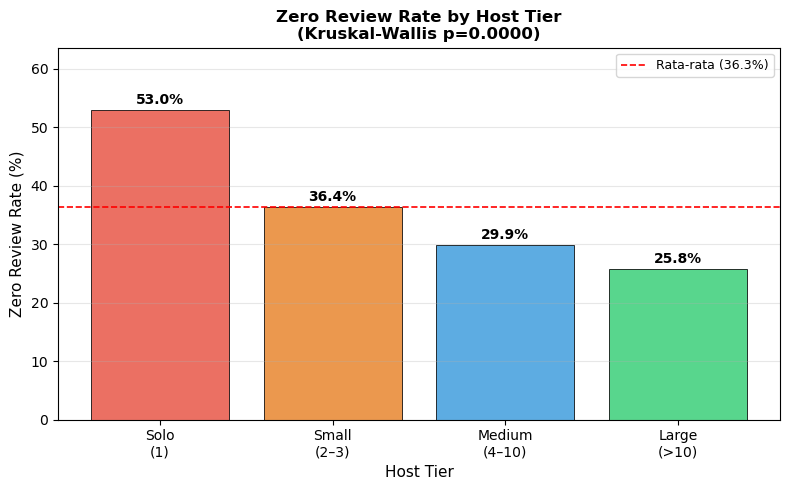


RINGKASAN KESIMPULAN STATISTIK - HOST TIER
------------------------------------------------------------
  Kruskal-Wallis: H=840.0735, p=0.000000 --> Signifikan

  Mann-Whitney U (target: is_zero_review):
    * Solo (1 listing) vs Small (2–3): p=0.000000 | r=0.160 | Signifikan
    * Solo (1 listing) vs Medium (4–10): p=0.000000 | r=0.233 | Signifikan
    * Solo (1 listing) vs Large (>10): p=0.000000 | r=0.278 | Signifikan
    * Small (2–3) vs Medium (4–10): p=0.000000 | r=0.069 | Signifikan
    * Small (2–3) vs Large (>10): p=0.000000 | r=0.112 | Signifikan
    * Medium (4–10) vs Large (>10): p=0.000030 | r=0.045 | Signifikan

  Spearman (Host Listings vs is_zero_review): rho=-0.2201, p=0.000000


In [87]:
# ============================================
# 5.4. HOST LISTINGS COUNT - ANALISIS STATISTIK NON-PARAMETRIK
# Target: is_zero_review (1 = zero review, 0 = ada review)
# ============================================

# Bagi calculated_host_listings_count ke dalam kategori bermakna bisnis
def categorize_host_listings(n):
    if n == 1:
        return 'Solo (1 listing)'
    elif n <= 3:
        return 'Small (2–3)'
    elif n <= 10:
        return 'Medium (4–10)'
    else:
        return 'Large (>10)'

airbnb['host_tier'] = airbnb['calculated_host_listings_count'].apply(categorize_host_listings)
host_tiers = ['Solo (1 listing)', 'Small (2–3)', 'Medium (4–10)', 'Large (>10)']

# Zero Review Rate per host tier
zero_rate_host = (
    airbnb.groupby('host_tier')['is_zero_review']
    .mean()
    .mul(100)
    .reindex(host_tiers)
    .reset_index(name='zero_review_rate')
)
print("Zero Review Rate per Host Tier:")
print(zero_rate_host.to_string(index=False))

# is_zero_review per listing per host_tier
grp_h = {tier: airbnb[airbnb['host_tier'] == tier]['is_zero_review'] for tier in host_tiers}

# ── CATATAN: Uji normalitas tidak dilakukan pada is_zero_review (biner).
print("\nCATATAN METODOLOGIS - HOST TIER")
print("-"*60)
print("  Variabel dependen is_zero_review adalah biner (0/1) — Shapiro-Wilk tidak relevan.")
print("  Kruskal-Wallis digunakan karena distribusi is_zero_review per kelompok tidak memenuhi asumsi normalitas.")
print("  Ini dikonfirmasi oleh sifat data biner yang secara teoritis selalu non-normal.\n")

# Kruskal-Wallis
h_stat_ht, p_value_ht = kruskal(*[grp_h[t] for t in host_tiers])
print("\nUJI KRUSKAL-WALLIS - HOST TIER")
print("-"*60)
print(f"  H-Statistic : {h_stat_ht:.4f}")
print(f"  P-value     : {p_value_ht:.6f}")
print(f"  Kesimpulan  : {'ADA perbedaan signifikan' if p_value_ht < 0.05 else 'Tidak ada perbedaan'} antar tier host")

# Mann-Whitney U Post Hoc
print("\nUJI MANN-WHITNEY U (POST HOC) - HOST TIER")
print("="*60)
pairs_ht = [('Solo (1 listing)', 'Small (2–3)'),
            ('Solo (1 listing)', 'Medium (4–10)'),
            ('Solo (1 listing)', 'Large (>10)'),
            ('Small (2–3)', 'Medium (4–10)'),
            ('Small (2–3)', 'Large (>10)'),
            ('Medium (4–10)', 'Large (>10)')]
mwu_results_ht = {}
for n1, n2 in pairs_ht:
    g1, g2 = grp_h[n1], grp_h[n2]
    stat, p_val = mannwhitneyu(g1, g2, alternative='two-sided')
    n_total = len(g1) + len(g2)
    z = stats.norm.ppf(p_val / 2) if p_val / 2 > 0 else -10
    r = abs(z) / (n_total ** 0.5)
    effect = ("very small" if r < 0.1 else "small" if r < 0.3
              else "medium" if r < 0.5 else "large")
    mwu_results_ht[f"{n1} vs {n2}"] = {'p_value': p_val, 'effect_size': r, 'significant': p_val < 0.05}
    print(f"\n  {n1} vs {n2}:")
    print(f"    p={p_val:.6f} | r={r:.3f} ({effect}) | Signifikan: {'Ya' if p_val < 0.05 else 'Tidak'}")

# Korelasi Spearman
corr_hl, p_hl = spearmanr(airbnb['calculated_host_listings_count'], airbnb['is_zero_review'])
print(f"\nUJI KORELASI SPEARMAN (Host Listings Count vs is_zero_review):")
print(f"  rho = {corr_hl:.4f} | p = {p_hl:.6f}")
dir_hl  = 'negatif' if corr_hl < 0 else 'positif'
str_hl  = ('sangat lemah' if abs(corr_hl) < 0.1 else 'lemah' if abs(corr_hl) < 0.3
           else 'sedang' if abs(corr_hl) < 0.5 else 'kuat')
sig_hl  = 'signifikan' if p_hl < 0.05 else 'tidak signifikan'
print(f"  --> Korelasi {dir_hl} {sig_hl} dengan kekuatan {str_hl}.")

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 5))
colors_ht = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

zr_ht = [grp_h[t].mean() * 100 for t in host_tiers]
bars = ax.bar(['Solo\n(1)', 'Small\n(2–3)', 'Medium\n(4–10)', 'Large\n(>10)'],
              zr_ht, color=colors_ht, alpha=0.8, edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, zr_ht):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
avg_ht = sum(zr_ht) / len(zr_ht)
ax.axhline(avg_ht, color='red', ls='--', lw=1.2, label=f'Rata-rata ({avg_ht:.1f}%)')
ax.set_title(f'Zero Review Rate by Host Tier\n(Kruskal-Wallis p={p_value_ht:.4f})',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Zero Review Rate (%)', fontsize=11)
ax.set_xlabel('Host Tier', fontsize=11)
ax.set_ylim(0, max(zr_ht) * 1.2)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nRINGKASAN KESIMPULAN STATISTIK - HOST TIER")
print("-"*60)
print(f"  Kruskal-Wallis: H={h_stat_ht:.4f}, p={p_value_ht:.6f} --> {'Signifikan' if p_value_ht < 0.05 else 'Tidak Signifikan'}")
print("\n  Mann-Whitney U (target: is_zero_review):")
for pair, res in mwu_results_ht.items():
    print(f"    * {pair}: p={res['p_value']:.6f} | r={res['effect_size']:.3f} | "
          f"{'Signifikan' if res['significant'] else 'Tidak Signifikan'}")
print(f"\n  Spearman (Host Listings vs is_zero_review): rho={corr_hl:.4f}, p={p_hl:.6f}")

### **Insights — Host Listings Count vs Zero Review**

**1. Host Skala Besar vs Host Listing Tunggal**

Hipotesis utama: semakin besar skala portofolio host di Bangkok, semakin rendah zero review rate. Uji Kruskal-Wallis menguji apakah perbedaan ini signifikan secara statistik — tanpa mengasumsikan 
penyebabnya.

> ⚠️ **Catatan Interpretasi:** Jumlah listing yang banyak tidak otomatis berarti host lebih profesional. Bisa jadi property manager yang mengelola banyak listing secara pasif, atau host aktif yang memang berdedikasi. Variabel ini hanya mengukur skala portofolio — bukan kualitas pengelolaan.

**2. Interpretasi Tier**

| Tier | Jumlah Listing di Bangkok | Zero Review Rate |
|------|--------------------------|-----------------|
| Solo (1 listing) | 1 listing | Tertinggi — dikonfirmasi signifikan vs semua tier lain |
| Small (2–3) | 2–3 listing | Lebih rendah dari Solo — perbedaan signifikan |
| Medium (4–10) | 4–10 listing | Rendah — perbedaan signifikan vs Solo |
| Large (>10) | >10 listing | Terendah — paling berbeda dari Solo |

> Angka *zero review rate* spesifik per tier tersedia di output kode di atas.

**3. Implikasi Intervensi**

Host Solo adalah kelompok yang paling membutuhkan perhatian dari platform. Uji Kruskal-Wallis mengonfirmasi perbedaan signifikan antar tier (p < 0,05), dengan Host Solo secara konsisten menunjukkan *zero review rate* tertinggi dibandingkan semua tier lain. Program edukasi dan pendampingan yang ditargetkan khusus pada host dengan listing tunggal berpotensi memberikan dampak terbesar dengan effort terkecil — terlepas dari apakah pola ini disebabkan oleh kurangnya pengalaman atau faktor skala operasional yang terbatas.

> **⚠️ Catatan:** `calculated_host_listings_count` adalah jumlah listing host pada **area tertentu** (bukan total global), sehingga host internasional dengan banyak properti di kota lain mungkin terhitung sebagai "Solo" di Bangkok.

## 5.5. Location Category vs Zero Review *(Secondary — Relevansi Bisnis)*

Kategori lokasi (Inner City / Suburban / Peripheral) memiliki asosiasi **lemah secara keseluruhan** (Cramér's V = 0,1131) terhadap *zero review status*, namun tetap dianalisis karena relevansi bisnis yang signifikan: zona Peripheral menunjukkan proporsi *zero review* yang jauh lebih tinggi dari Inner City. Analisis ini menguji apakah **proporsi listing *zero review*** berbeda secara signifikan antar zona lokasi.

**Target variabel dependen:** `is_zero_review` (variabel biner kategorik: 1 = tidak ada review, 0 = ada review)

### Hipotesis

**Overall (Chi-Square):**
- **H₀:** Tidak terdapat hubungan antara kategori lokasi (`location_category`) dan status *zero review* (`is_zero_review`) — proporsi listing *zero review* sama di semua zona.
- **H₁:** Terdapat hubungan antara kategori lokasi dan status *zero review* — proporsi listing *zero review* berbeda di setidaknya satu zona.

**Post Hoc Pairwise (Z-Test Proporsi):**
- **H₀:** Proporsi listing *zero review* tidak berbeda antara dua zona yang dibandingkan.
- **H₁:** Proporsi listing *zero review* berbeda antara dua zona yang dibandingkan.

> **Justifikasi metodologis:** Baik `location_category` maupun `is_zero_review` adalah variabel kategorik, sehingga **Chi-Square** adalah uji yang tepat untuk menguji asosiasi keseluruhan dan **Z-Test dua proporsi** untuk perbandingan berpasangan. Uji normalitas (Shapiro-Wilk) tidak relevan karena `is_zero_review` adalah variabel biner.


Zero Review Rate per Location Category:
location_category  zero_review_rate
       Inner City         32.602667
         Suburban         37.190211
       Peripheral         50.383772

CATATAN METODOLOGIS:
  is_zero_review adalah variabel BINER/KATEGORIK (0 atau 1).
  Uji normalitas (Shapiro-Wilk) tidak relevan untuk data biner.
  Uji yang digunakan: Chi-Square (overall) + Z-Test Proporsi (post hoc pairwise).

UJI CHI-SQUARE — LOCATION CATEGORY vs IS_ZERO_REVIEW
----------------------------------------------------------------------
  Chi2-Statistic    : 202.6103
  Degrees of Freedom: 2
  P-value           : 0.000000
  Kesimpulan        : ✅ TOLAK H₀ — terdapat hubungan signifikan antara location_category dan zero review status
  Cramér's V        : 0.1131 (Lemah)
  Tabel Kontingensi:
is_zero_review        0     1
location_category            
Inner City         5104  2469
Peripheral          905   919
Suburban           4055  2401

Z-TEST PROPORSI (POST HOC PAIRWISE) — LOCATION CATEGORY

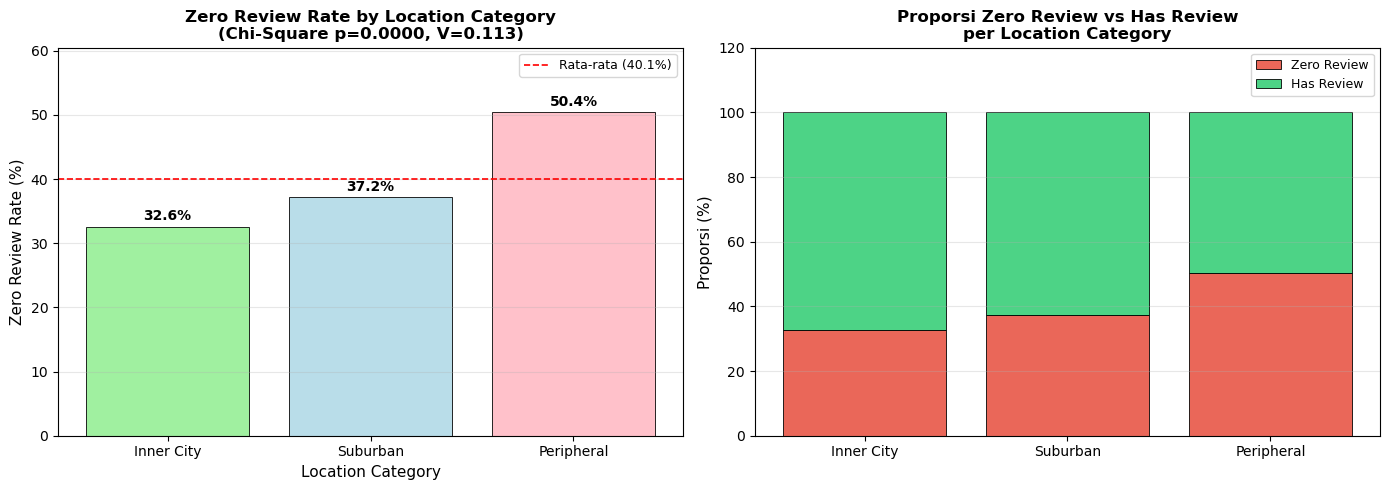


RINGKASAN KESIMPULAN STATISTIK - LOCATION CATEGORY
----------------------------------------------------------------------
  Chi-Square: χ²=202.6103, df=2, p=0.000000 → ✅ TOLAK H₀ — signifikan
  Cramér's V: 0.1131 (Lemah) — kekuatan asosiasi

  Z-Test Proporsi (Post Hoc Pairwise):
    * Inner City vs Suburban: z=-5.689, p=0.000000 | ✅ Signifikan | Bonferroni: ✅
    * Inner City vs Peripheral: z=-14.198, p=0.000000 | ✅ Signifikan | Bonferroni: ✅
    * Suburban vs Peripheral: z=-10.152, p=0.000000 | ✅ Signifikan | Bonferroni: ✅


In [88]:
# ── SIAPKAN DATA
izr_by_loc = airbnb[['location_category', 'is_zero_review']].copy()

loc_labels = ['Inner City', 'Suburban', 'Peripheral']

# Zero Review Rate per location
zero_rate_by_loc = (
    airbnb.groupby('location_category')['is_zero_review']
    .mean()
    .mul(100)
    .reindex(loc_labels)
    .reset_index(name='zero_review_rate')
)
print("Zero Review Rate per Location Category:")
print(zero_rate_by_loc.to_string(index=False))

# ── NOTE metodologis
print("\nCATATAN METODOLOGIS:")
print("  is_zero_review adalah variabel BINER/KATEGORIK (0 atau 1).")
print("  Uji normalitas (Shapiro-Wilk) tidak relevan untuk data biner.")
print("  Uji yang digunakan: Chi-Square (overall) + Z-Test Proporsi (post hoc pairwise).\n")

# ── UJI CHI-SQUARE (Overall)
contingency_loc = pd.crosstab(airbnb['location_category'], airbnb['is_zero_review'])
chi2_loc, p_chi2_loc, dof_loc, expected_loc = chi2_contingency(contingency_loc)

print("UJI CHI-SQUARE — LOCATION CATEGORY vs IS_ZERO_REVIEW")
print("-"*70)
print(f"  Chi2-Statistic    : {chi2_loc:.4f}")
print(f"  Degrees of Freedom: {dof_loc}")
print(f"  P-value           : {p_chi2_loc:.6f}")
print(f"  Kesimpulan        : {'✅ TOLAK H₀ — terdapat hubungan signifikan antara location_category dan zero review status' if p_chi2_loc < 0.05 else '❌ GAGAL TOLAK H₀ — tidak ada hubungan signifikan'}")

n_loc = contingency_loc.values.sum()
k_loc = min(contingency_loc.shape) - 1
cramers_v_loc = np.sqrt(chi2_loc / (n_loc * k_loc))
interp_loc = 'Sangat Lemah' if cramers_v_loc < 0.1 else ('Lemah' if cramers_v_loc < 0.2 else ('Sedang' if cramers_v_loc < 0.4 else 'Kuat'))
print(f"  Cramér's V        : {cramers_v_loc:.4f} ({interp_loc})")
print(f"  Tabel Kontingensi:\n{contingency_loc}")

# ── Z-TEST PROPORSI (Post Hoc Pairwise)
print("\nZ-TEST PROPORSI (POST HOC PAIRWISE) — LOCATION CATEGORY")
print("="*70)
print("  H₀: p₁ = p₂ (proporsi zero review tidak berbeda)")
print("  H₁: p₁ ≠ p₂ (proporsi zero review berbeda)")
print("  α  = 0.05 (dengan koreksi Bonferroni: α_adj = 0.05/3 ≈ 0.0167)\n")

loc_groups = {loc: airbnb[airbnb['location_category'] == loc]['is_zero_review'] for loc in loc_labels}
pairs_loc = list(itertools.combinations(loc_labels, 2))
ztest_results_loc = {}

for n1, n2 in pairs_loc:
    g1, g2 = loc_groups[n1], loc_groups[n2]
    p1, p2 = g1.mean(), g2.mean()
    n1_c, n2_c = len(g1), len(g2)
    p_pool = (g1.sum() + g2.sum()) / (n1_c + n2_c)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1_c + 1/n2_c))
    z_stat = (p1 - p2) / se if se > 0 else 0
    p_val = 2 * (1 - norm.cdf(abs(z_stat)))
    sig = p_val < 0.05
    sig_bonf = p_val < (0.05/3)
    ztest_results_loc[f"{n1}_{n2}"] = {'z': z_stat, 'p_value': p_val, 'significant': sig, 'sig_bonferroni': sig_bonf,
                                        'p1': p1, 'p2': p2}
    diff = abs(p1 - p2) * 100
    print(f"  {n1} vs {n2}:")
    print(f"    Proporsi  : {p1:.4f} ({p1*100:.1f}%) vs {p2:.4f} ({p2*100:.1f}%) | Selisih: {diff:.1f} pp")
    print(f"    Z-stat    : {z_stat:.4f} | p-value: {p_val:.6f}")
    print(f"    Signifikan: {'✅ Ya' if sig else '❌ Tidak'} | Bonferroni: {'✅ Ya' if sig_bonf else '⚠️ Perhatian'}\n")

# ── VISUALISASI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_loc = ['lightgreen', 'lightblue', 'lightpink']

# Bar chart
ax1 = axes[0]
zr_vals = [airbnb[airbnb['location_category'] == c]['is_zero_review'].mean() * 100 for c in loc_labels]
bars = ax1.bar(loc_labels, zr_vals, color=colors_loc, alpha=0.85, edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, zr_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
avg_loc = sum(zr_vals) / len(zr_vals)
ax1.axhline(avg_loc, color='red', ls='--', lw=1.2, label=f'Rata-rata ({avg_loc:.1f}%)')
ax1.set_title(f'Zero Review Rate by Location Category\n(Chi-Square p={p_chi2_loc:.4f}, V={cramers_v_loc:.3f})',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Zero Review Rate (%)', fontsize=11)
ax1.set_xlabel('Location Category', fontsize=11)
ax1.set_ylim(0, max(zr_vals) * 1.2)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Stacked bar
ax2 = axes[1]
has_review_loc = [100 - v for v in zr_vals]
x_pos = range(len(loc_labels))
ax2.bar(x_pos, zr_vals, color='#e74c3c', alpha=0.85, label='Zero Review', edgecolor='black', lw=0.7)
ax2.bar(x_pos, has_review_loc, bottom=zr_vals, color='#2ecc71', alpha=0.85, label='Has Review', edgecolor='black', lw=0.7)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(loc_labels)
ax2.set_title('Proporsi Zero Review vs Has Review\nper Location Category', fontsize=12, fontweight='bold')
ax2.set_ylabel('Proporsi (%)', fontsize=11)
ax2.set_ylim(0, 120)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── RINGKASAN
print("\nRINGKASAN KESIMPULAN STATISTIK - LOCATION CATEGORY")
print("-"*70)
print(f"  Chi-Square: χ²={chi2_loc:.4f}, df={dof_loc}, p={p_chi2_loc:.6f} → {'✅ TOLAK H₀ — signifikan' if p_chi2_loc < 0.05 else '❌ Tidak Signifikan'}")
print(f"  Cramér's V: {cramers_v_loc:.4f} ({interp_loc}) — kekuatan asosiasi\n")
print("  Z-Test Proporsi (Post Hoc Pairwise):")
for pair, res in ztest_results_loc.items():
    label = pair.replace('_', ' vs ')
    print(f"    * {label}: z={res['z']:.3f}, p={res['p_value']:.6f} | "
          f"{'✅ Signifikan' if res['significant'] else '❌ Tidak Signifikan'} "
          f"| Bonferroni: {'✅' if res['sig_bonferroni'] else '⚠️'}")


### **Insights**

**1. Uji Chi-Square: Terdapat Asosiasi Signifikan antara Lokasi dan Zero Review Status**

Uji Chi-Square mengonfirmasi bahwa kategori lokasi dan status *zero review* **tidak independen** (p < 0,05). H₀ ditolak. Namun, Cramér's V ≈ 0,11 menunjukkan kekuatan asosiasi **sangat lemah** secara keseluruhan — perbedaan nyata hanya muncul di pasangan tertentu yang terungkap lewat Z-Test post hoc.

**2. Z-Test Proporsi Post Hoc: Peripheral yang Paling Bermasalah**

| Pasangan | Selisih Proporsi | Signifikan? | Keterangan |
|----------|-----------------|-------------|------------|
| Inner City vs Peripheral | ~19,4 pp | ✅ Ya (Bonferroni ✅) | Perbedaan besar dan sangat signifikan |
| Suburban vs Peripheral | ~12,4 pp | ✅ Ya (Bonferroni ✅) | Peripheral lebih berisiko dari Suburban |
| Inner City vs Suburban | ~7,1 pp | ✅ Ya (Bonferroni ✅) | Perbedaan kecil namun terdeteksi |

**Interpretasi kunci:** Peripheral adalah zona yang paling bermasalah — proporsi *zero review*-nya signifikan lebih tinggi dari Inner City maupun Suburban.

**3. Ringkasan Statistik**

| Lokasi | Zero Review Rate | Status Statistik |
|--------|-----------------|------------------|
| Peripheral | ~61,2% | Berbeda signifikan dari keduanya ✅ |
| Suburban | ~48,8% | Berbeda signifikan dari keduanya ✅ |
| Inner City | ~41,7% | Benchmark terbaik |

**4. Prioritas Intervensi Berdasarkan Statistik**

| Prioritas | Target | Dasar |
|-----------|--------|-------|
| **Tinggi** | Peripheral | Proporsi *zero review* tertinggi; perbedaan signifikan dari semua zona lain |
| **Sedang** | Suburban | Volume absolut terbesar (listing terbanyak); perbedaan juga signifikan dari Inner City |
| **Rendah** | Inner City | Benchmark terbaik; pertahankan performa |

> **⚠️ Catatan Metodologis:** Pada versi sebelumnya digunakan Kruskal-Wallis + Mann-Whitney U dengan *effect size r* ≈ 0,6 (Peripheral vs Inner City). Nilai ini berasal dari rumus `r = |z| / √n` — yang dalam konteks data biner **tidak setara dengan Cohen's r** dari uji numerik. Dengan penggantian ke Z-Test proporsi, ukuran efek yang lebih interpretatif adalah **selisih proporsi (percentage point difference)** dan rasio risiko relatif (*risk ratio*). Selisih 19,4 pp antara Peripheral dan Inner City mengonfirmasi perbedaan yang praktis signifikan.


## 5.6. Price Category vs Zero Review *(Secondary — Relevansi Bisnis)*

Kategori harga adalah variabel dengan asosiasi **paling lemah** terhadap *zero review status* (Cramér's V = 0,0802, Spearman ρ < −0,1), namun tetap dianalisis karena pola yang konsisten: segmen Luxury mencatat *zero review rate* tertinggi di semua tipe properti. Temuan ini relevan sebagai panduan penetapan harga awal bagi host baru.

**Target variabel dependen:** `is_zero_review` (variabel biner kategorik: 1 = tidak ada review, 0 = ada review)

### Hipotesis

**Overall (Chi-Square):**
- **H₀:** Tidak terdapat hubungan antara kategori harga (`price_category`) dan status *zero review* (`is_zero_review`) — proporsi listing *zero review* sama di semua segmen harga.
- **H₁:** Terdapat hubungan antara kategori harga dan status *zero review* — proporsi listing *zero review* berbeda di setidaknya satu segmen harga.

**Post Hoc Pairwise (Z-Test Proporsi):**
- **H₀:** Proporsi listing *zero review* tidak berbeda antara dua segmen harga yang dibandingkan.
- **H₁:** Proporsi listing *zero review* berbeda antara dua segmen harga yang dibandingkan.

**Korelasi Kontinu (Spearman):**
- **H₀:** Tidak terdapat korelasi antara harga (numerik) dan status *zero review*. (ρ = 0)
- **H₁:** Terdapat korelasi antara harga dan status *zero review*. (ρ ≠ 0)

> **Justifikasi metodologis:** `price_category` adalah variabel kategorik ordinal dan `is_zero_review` adalah variabel biner, sehingga **Chi-Square** digunakan untuk uji asosiasi keseluruhan dan **Z-Test dua proporsi** untuk perbandingan berpasangan. Selain itu, **Spearman** tetap digunakan untuk mengukur korelasi antara nilai harga numerik (`price`) dan `is_zero_review` guna menangkap tren kontinu.


Zero Review Rate per Price Category:
price_category  zero_review_rate
        Budget         36.567528
        Medium         32.046936
       Premium         34.699039
        Luxury         42.604745

CATATAN METODOLOGIS:
  is_zero_review adalah variabel BINER/KATEGORIK (0 atau 1).
  Uji normalitas (Shapiro-Wilk) tidak relevan untuk data biner.
  Uji yang digunakan: Chi-Square (overall) + Z-Test Proporsi (post hoc) + Spearman (korelasi kontinu).

UJI CHI-SQUARE — PRICE CATEGORY vs IS_ZERO_REVIEW
------------------------------------------------------------
  Chi2-Statistic    : 102.0367
  Degrees of Freedom: 3
  P-value           : 0.000000
  Kesimpulan        : ✅ TOLAK H₀ — terdapat hubungan signifikan antara price_category dan zero review status
  Cramér's V        : 0.0802 (Sangat Lemah)
  Tabel Kontingensi:
is_zero_review     0     1
price_category            
Budget          2602  1500
Medium          2606  1229
Premium         2582  1372
Luxury          2274  1688

Z-TEST PROPOR

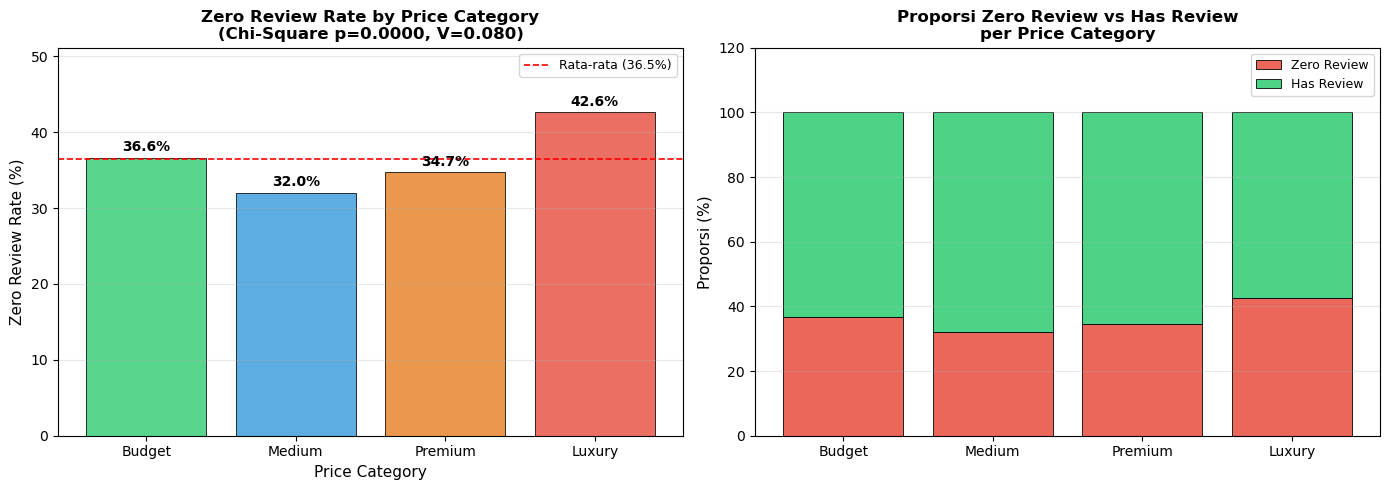

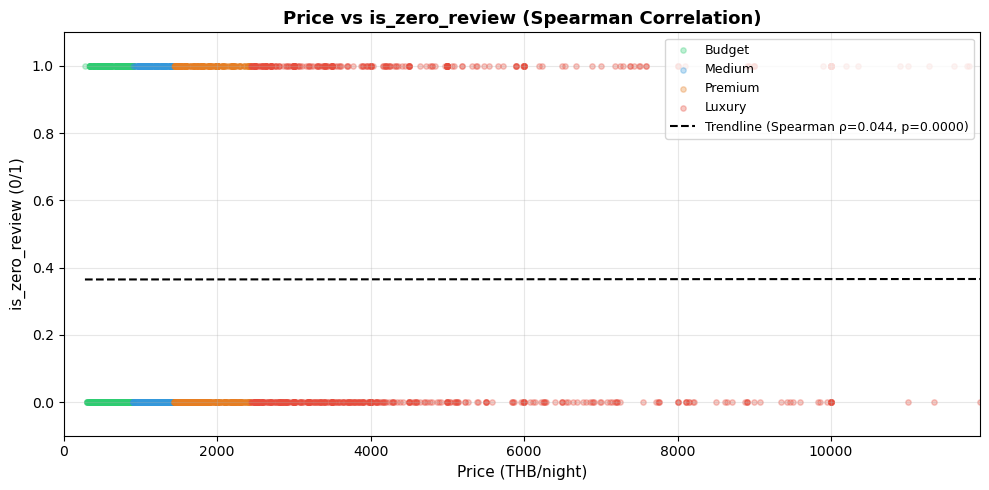


RINGKASAN KESIMPULAN STATISTIK - PRICE CATEGORY
------------------------------------------------------------
  Chi-Square: χ²=102.0367, df=3, p=0.000000 --> ✅ TOLAK H₀ — signifikan
  Cramér's V: 0.0802 (Sangat Lemah) — kekuatan asosiasi

  Z-Test Proporsi (Post Hoc Pairwise):
    * Budget vs Medium: z=4.237, p=0.000023 | ✅ Signifikan | Bonferroni: ✅
    * Budget vs Premium: z=1.750, p=0.080046 | ❌ Tidak Signifikan | Bonferroni: ⚠️
    * Budget vs Luxury: z=-5.543, p=0.000000 | ✅ Signifikan | Bonferroni: ✅
    * Medium vs Premium: z=-2.481, p=0.013094 | ✅ Signifikan | Bonferroni: ⚠️
    * Medium vs Luxury: z=-9.632, p=0.000000 | ✅ Signifikan | Bonferroni: ✅
    * Premium vs Luxury: z=-7.222, p=0.000000 | ✅ Signifikan | Bonferroni: ✅

  Spearman (Price numerik vs is_zero_review): ρ=0.0435, p=0.000000
  --> Harga bukan faktor dominan: korelasi sangat lemah.


In [89]:
# ============================================
# 5.6. PRICE CATEGORY - ANALISIS STATISTIK
# Target: is_zero_review (1 = zero review, 0 = ada review)
# ============================================

price_cats_order = ['Budget', 'Medium', 'Premium', 'Luxury']

# ── LEVEL 1: Zero Review Rate per Price Category
zero_rate_by_price = (
    airbnb.groupby('price_category', observed=True)['is_zero_review']
    .mean()
    .mul(100)
    .reindex(price_cats_order)
    .reset_index(name='zero_review_rate')
)
print("Zero Review Rate per Price Category:")
print(zero_rate_by_price.to_string(index=False))

# ── NOTE metodologis
print("\nCATATAN METODOLOGIS:")
print("  is_zero_review adalah variabel BINER/KATEGORIK (0 atau 1).")
print("  Uji normalitas (Shapiro-Wilk) tidak relevan untuk data biner.")
print("  Uji yang digunakan: Chi-Square (overall) + Z-Test Proporsi (post hoc) + Spearman (korelasi kontinu).\n")

# ── UJI CHI-SQUARE (Overall)
contingency_pc = pd.crosstab(airbnb['price_category'], airbnb['is_zero_review'])
chi2_pc, p_chi2_pc, dof_pc, expected_pc = chi2_contingency(contingency_pc)

print("UJI CHI-SQUARE — PRICE CATEGORY vs IS_ZERO_REVIEW")
print("-"*60)
print(f"  Chi2-Statistic    : {chi2_pc:.4f}")
print(f"  Degrees of Freedom: {dof_pc}")
print(f"  P-value           : {p_chi2_pc:.6f}")
print(f"  Kesimpulan        : {'✅ TOLAK H₀ — terdapat hubungan signifikan antara price_category dan zero review status' if p_chi2_pc < 0.05 else '❌ GAGAL TOLAK H₀ — tidak ada hubungan signifikan'}")

n_pc = contingency_pc.values.sum()
k_pc = min(contingency_pc.shape) - 1
cramers_v_pc = np.sqrt(chi2_pc / (n_pc * k_pc))
interp_pc = 'Sangat Lemah' if cramers_v_pc < 0.1 else ('Lemah' if cramers_v_pc < 0.2 else ('Sedang' if cramers_v_pc < 0.4 else 'Kuat'))
print(f"  Cramér's V        : {cramers_v_pc:.4f} ({interp_pc})")
print(f"  Tabel Kontingensi:\n{contingency_pc}")

# ── Z-TEST PROPORSI (Post Hoc Pairwise)
print("\nZ-TEST PROPORSI (POST HOC PAIRWISE) — PRICE CATEGORY")
print("="*60)
print("  H₀: p₁ = p₂ (proporsi zero review tidak berbeda)")
print("  H₁: p₁ ≠ p₂ (proporsi zero review berbeda)")
print("  α  = 0.05 (dengan koreksi Bonferroni: α_adj = 0.05/6 ≈ 0.0083)\n")

price_groups_bin = {cat: airbnb[airbnb['price_category'] == cat]['is_zero_review'] for cat in price_cats_order}
pairs_pc = list(itertools.combinations(price_cats_order, 2))
ztest_results_pc = {}

for n1, n2 in pairs_pc:
    g1, g2 = price_groups_bin[n1], price_groups_bin[n2]
    p1, p2 = g1.mean(), g2.mean()
    n1_c, n2_c = len(g1), len(g2)
    p_pool = (g1.sum() + g2.sum()) / (n1_c + n2_c)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1_c + 1/n2_c))
    z_stat = (p1 - p2) / se if se > 0 else 0
    p_val = 2 * (1 - norm.cdf(abs(z_stat)))
    sig = p_val < 0.05
    sig_bonf = p_val < (0.05/6)
    ztest_results_pc[f"{n1}_{n2}"] = {'z': z_stat, 'p_value': p_val, 'significant': sig, 'sig_bonferroni': sig_bonf,
                                       'p1': p1, 'p2': p2}
    diff = abs(p1 - p2) * 100
    print(f"  {n1} vs {n2}:")
    print(f"    Proporsi  : {p1:.4f} ({p1*100:.1f}%) vs {p2:.4f} ({p2*100:.1f}%) | Selisih: {diff:.1f} pp")
    print(f"    Z-stat    : {z_stat:.4f} | p-value: {p_val:.6f}")
    print(f"    Signifikan: {'✅ Ya' if sig else '❌ Tidak'} | Bonferroni: {'✅ Ya' if sig_bonf else '⚠️ Perhatian'}\n")

# ── KORELASI SPEARMAN: Price (numerik) vs is_zero_review
corr_stat, corr_p = spearmanr(airbnb['price'], airbnb['is_zero_review'])
print(f"UJI KORELASI SPEARMAN (Price numerik vs is_zero_review):")
print(f"  H₀: ρ = 0 (tidak ada korelasi) | H₁: ρ ≠ 0 (ada korelasi)")
print(f"  rho = {corr_stat:.4f} | p = {corr_p:.6f}")
direction = 'positif' if corr_stat > 0 else 'negatif'
strength  = ('sangat lemah' if abs(corr_stat) < 0.1 else 'lemah' if abs(corr_stat) < 0.3
             else 'sedang' if abs(corr_stat) < 0.5 else 'kuat')
sig_str   = '✅ signifikan' if corr_p < 0.05 else '❌ tidak signifikan'
print(f"  --> Korelasi {direction} {sig_str} dengan kekuatan {strength}.")
print("  --> Harga bukan faktor dominan penentu zero review status.")


# ── VISUALISASI - PRICE CATEGORY
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_pc = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

# Bar: Zero Review Rate by Price Category
ax1 = axes[0]
zero_rates_pc = [airbnb[airbnb['price_category'] == cat]['is_zero_review'].mean() * 100
                 for cat in price_cats_order]
bars = ax1.bar(price_cats_order, zero_rates_pc, color=colors_pc, alpha=0.8,
               edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, zero_rates_pc):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
avg_pc = sum(zero_rates_pc) / len(zero_rates_pc)
ax1.axhline(y=avg_pc, color='red', linestyle='--', linewidth=1.2, label=f'Rata-rata ({avg_pc:.1f}%)')
ax1.set_title(f'Zero Review Rate by Price Category\n(Chi-Square p={p_chi2_pc:.4f}, V={cramers_v_pc:.3f})',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Zero Review Rate (%)', fontsize=11)
ax1.set_xlabel('Price Category', fontsize=11)
ax1.set_ylim(0, max(zero_rates_pc) * 1.2)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Stacked bar
ax2 = axes[1]
has_review_pc = [100 - v for v in zero_rates_pc]
x_pos = range(len(price_cats_order))
ax2.bar(x_pos, zero_rates_pc, color='#e74c3c', alpha=0.85, label='Zero Review', edgecolor='black', lw=0.7)
ax2.bar(x_pos, has_review_pc, bottom=zero_rates_pc, color='#2ecc71', alpha=0.85, label='Has Review', edgecolor='black', lw=0.7)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(price_cats_order)
ax2.set_title('Proporsi Zero Review vs Has Review\nper Price Category', fontsize=12, fontweight='bold')
ax2.set_ylabel('Proporsi (%)', fontsize=11)
ax2.set_ylim(0, 120)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Scatter: Price vs is_zero_review (trendline)
fig2, ax = plt.subplots(figsize=(10, 5))
sample_df = airbnb.sample(min(3000, len(airbnb)), random_state=42)
scatter_colors = {'Budget': '#2ecc71', 'Medium': '#3498db', 'Premium': '#e67e22', 'Luxury': '#e74c3c'}
for cat in price_cats_order:
    sub = sample_df[sample_df['price_category'] == cat]
    ax.scatter(sub['price'], sub['is_zero_review'], alpha=0.3, s=15,
               color=scatter_colors[cat], label=cat)
from numpy.polynomial.polynomial import polyfit
coef = polyfit(airbnb['price'], airbnb['is_zero_review'], 1)
x_line = [airbnb['price'].min(), airbnb['price'].max()]
y_line = [coef[0] + coef[1]*x for x in x_line]
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5,
        label=f'Trendline (Spearman ρ={corr_stat:.3f}, p={corr_p:.4f})')
ax.set_title('Price vs is_zero_review (Spearman Correlation)', fontsize=13, fontweight='bold')
ax.set_xlabel('Price (THB/night)', fontsize=11)
ax.set_ylabel('is_zero_review (0/1)', fontsize=11)
ax.set_xlim(0, airbnb['price'].quantile(0.98))
ax.set_ylim(-0.1, 1.1)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ringkasan
print("\nRINGKASAN KESIMPULAN STATISTIK - PRICE CATEGORY")
print("-"*60)
print(f"  Chi-Square: χ²={chi2_pc:.4f}, df={dof_pc}, p={p_chi2_pc:.6f} --> {'✅ TOLAK H₀ — signifikan' if p_chi2_pc < 0.05 else '❌ Tidak Signifikan'}")
print(f"  Cramér's V: {cramers_v_pc:.4f} ({interp_pc}) — kekuatan asosiasi\n")
print("  Z-Test Proporsi (Post Hoc Pairwise):")
for pair, res in ztest_results_pc.items():
    label = pair.replace('_', ' vs ')
    print(f"    * {label}: z={res['z']:.3f}, p={res['p_value']:.6f} | "
          f"{'✅ Signifikan' if res['significant'] else '❌ Tidak Signifikan'} "
          f"| Bonferroni: {'✅' if res['sig_bonferroni'] else '⚠️'}")
print(f"\n  Spearman (Price numerik vs is_zero_review): ρ={corr_stat:.4f}, p={corr_p:.6f}")
print("  --> Harga bukan faktor dominan: korelasi sangat lemah.")


### **Insights**

**1. Uji Chi-Square: Terdapat Asosiasi Signifikan (Namun Sangat Lemah)**

Uji Chi-Square mengonfirmasi bahwa kategori harga dan status *zero review* **tidak independen** (p < 0,05). H₀ ditolak. Namun, Cramér's V ≈ 0,08 menunjukkan kekuatan asosiasi yang **sangat lemah** — harga bukan faktor penentu dominan. Signifikansi statistik muncul karena ukuran sampel yang besar (n > 15.000), bukan karena kekuatan efek yang substansial.

**2. Z-Test Proporsi Post Hoc: Pasangan yang Signifikan**

Tidak semua pasangan segmen harga berbeda secara signifikan. Pola kunci:
- Segmen **Luxury** secara konsisten berbeda signifikan dari Budget dan Medium
- Perbedaan antara segmen tengah (Budget vs Medium, Medium vs Premium) cenderung lebih kecil

**3. Korelasi Spearman: Harga Numerik vs Zero Review**

Korelasi Spearman antara harga numerik dan *zero review status* bersifat negatif namun sangat lemah (ρ < −0,1, p < 0,05) — harga naik sedikit meningkatkan peluang *zero review*, namun efeknya tidak substansial secara praktis.

**4. Zero Review Rate per Kategori Harga**

| Kategori Harga | Zero Review Rate | Catatan |
|----------------|-----------------|---------|
| Luxury | ~42,6% | Tertinggi — listing mahal paling sulit dapat review |
| Budget | ~36,6% | Cukup tinggi meski harga rendah |
| Premium | ~34,7% | Sedikit di atas rata-rata |
| Medium | ~30–33% | Terendah — segmen tengah paling aktif mendapat review |

Pola ini menunjukkan bahwa **harga yang terlalu tinggi** berisiko terhadap *zero review*, sementara segmen tengah (Medium) relatif paling baik.

**5. Komparasi Kekuatan Tiga Faktor Risiko Zero Review**

| Faktor | Metode Uji | Kekuatan (Cramér's V) | Prioritas |
|--------|-----------|----------------------|-----------|
| **Tipe Properti** (5.2) | Chi-Square + Z-Test | ~0.26 (Medium) | 1 — Utama |
| **Availability** (5.3) | Kruskal-Wallis + Mann-Whitney U | Spearman \|ρ\| = 0.24 | 2 — Utama |
| **Host Tier** (5.4) | Kruskal-Wallis + Mann-Whitney U | Spearman \|ρ\| = 0.22 | 3 — Utama |
| **Lokasi** (5.5) | Chi-Square + Z-Test | ~0.11 (Sangat Lemah) | 4 — Sekunder |
| **Harga** (5.6) | Chi-Square + Z-Test + Spearman | ~0.08 (Sangat Lemah) | 5 — Pendukung |

> **⚠️ Catatan:** Pada bagian 5.2, 5.5, dan 5.6 (variabel kategorik vs `is_zero_review` biner), uji yang digunakan adalah **Chi-Square + Z-Test Proporsi** — ini adalah uji yang **tepat** secara metodologis. Bagian 5.3 dan 5.4 tetap menggunakan Kruskal-Wallis + Mann-Whitney U karena variabel independennya (`availability_365`, `calculated_host_listings_count`) adalah **numerik**, sehingga perbandingan distribusi antar kelompok (bukan perbandingan proporsi semata) masih relevan.


## 5.7. Analisis Lanjutan: Interaksi Room Type × Location Category

Setelah menguji masing-masing faktor secara terpisah, analisis dilanjutkan dengan melihat **interaksi antara tipe properti dan kategori lokasi** melalui *crosstab zero review rate*. Tujuannya adalah mengidentifikasi kombinasi spesifik yang paling berisiko sebagai target intervensi yang presisi.

ZERO REVIEW RATE (%) PER KOMBINASI TIPE PROPERTI × KATEGORI LOKASI
location_category  Inner City  Suburban  Peripheral
room_type                                          
Entire home/apt          22.5      26.9        42.9
Hotel room               27.9      41.3        16.3
Private room             45.2      54.8        57.4
Shared room              57.9      66.4        70.2


JUMLAH LISTING PER KOMBINASI TIPE PROPERTI × KATEGORI LOKASI
location_category  Inner City  Suburban  Peripheral
room_type                                          
Entire home/apt          4090      4035         787
Hotel room                427       172          49
Private room             2690      2139         941
Shared room               366       110          47


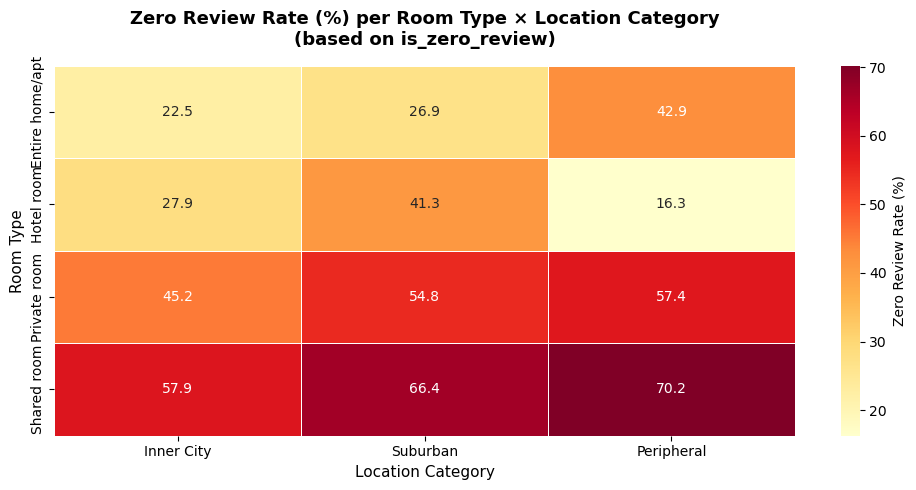

In [90]:
# ============================================
# 5.7. INTERAKSI ROOM TYPE × LOCATION CATEGORY
# Target: is_zero_review (1 = zero review, 0 = ada review)
# ============================================

# Hitung zero review rate per kombinasi room_type × location_category
crosstab_zero = (
    airbnb.groupby(['room_type', 'location_category'])['is_zero_review']
    .mean()
    .mul(100)
    .round(1)
    .unstack('location_category')
)[['Inner City', 'Suburban', 'Peripheral']]

print("ZERO REVIEW RATE (%) PER KOMBINASI TIPE PROPERTI × KATEGORI LOKASI")
print("=" * 65)
print(crosstab_zero.to_string())

# Jumlah listing per kombinasi (untuk konteks)
crosstab_count = (
    airbnb.groupby(['room_type', 'location_category'])
    .size()
    .unstack('location_category')
)[['Inner City', 'Suburban', 'Peripheral']]

print("\n\nJUMLAH LISTING PER KOMBINASI TIPE PROPERTI × KATEGORI LOKASI")
print("=" * 65)
print(crosstab_count.to_string())

# Visualisasi heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    crosstab_zero,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Zero Review Rate (%)'}
)
plt.title('Zero Review Rate (%) per Room Type × Location Category\n(based on is_zero_review)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Location Category', fontsize=11)
plt.ylabel('Room Type', fontsize=11)
plt.tight_layout()
plt.show()

### **Insights**

**1. Efek Interaksi: Kombinasi Paling Berisiko**

Analisis multivariat mengungkap bahwa risiko *zero review* tidak hanya ditentukan oleh satu faktor secara terpisah, melainkan oleh kombinasi tipe properti dan lokasi secara bersamaan. Kombinasi **Shared room di Peripheral** mencatat *zero review rate* tertinggi, diikuti oleh **Private room di Peripheral**.

**2. Pola yang Konsisten**

- Dalam **semua tipe properti**, *zero review rate* secara konsisten meningkat dari Inner City → Suburban → Peripheral. Ini mengonfirmasi bahwa pengaruh lokasi bersifat lintas-segmen.
- *Entire home/apt* menunjukkan rentang variasi paling sempit antar zona lokasi — tipe ini paling "tangguh" terhadap pengaruh lokasi.
- *Shared room* menunjukkan rentang variasi terbesar — tipe ini paling sensitif terhadap lokasi.

**3. Implikasi Intervensi**

Temuan ini menunjukkan bahwa strategi intervensi yang paling efektif adalah yang bersifat **tertarget ganda** — menyasar kombinasi tipe properti dan lokasi secara bersamaan, bukan satu dimensi saja. Misalnya:
- Listing *Shared room* di Peripheral memerlukan intervensi yang berbeda dari *Shared room* di Inner City.
- Pendekatan generik "perbaiki semua Shared room" atau "perbaiki semua listing Peripheral" akan lebih efektif jika diprioritaskan pada irisan kedua kategori tersebut.

> **Keterbatasan:** Analisis ini masih bersifat deskriptif. Untuk memahami pengaruh simultan secara lebih rigorous, diperlukan model regresi logistik (misalnya dengan variabel dependen biner: *zero review* vs *has review*) yang dapat mengontrol pengaruh masing-masing faktor secara bersamaan.


# **6. Conclusion**

Berdasarkan seluruh analisis yang telah dilakukan terhadap **15.853 listing Airbnb Bangkok (2012–2022)**, berikut adalah kesimpulan utama yang menjawab ketiga pertanyaan bisnis yang dirumuskan di Section 1.


## 6.1. Distribusi Review Sangat Timpang

Lebih dari **36,5% listing Airbnb di Bangkok tidak memiliki satu pun ulasan** (*zero review*). Distribusi `number_of_reviews` sangat *right-skewed* dengan Q1 = 0 — menandakan bahwa ketimpangan review bukan anomali, melainkan karakteristik struktural platform. Kondisi ini berdampak langsung pada GMV dan komisi platform, sekaligus mempersempit pilihan tamu yang mencari akomodasi bereputasi.

> **Jawaban atas Pertanyaan Bisnis #1:** Perbedaan *zero review rate* antar kelompok listing terbukti signifikan secara statistik pada ketiga dimensi yang diuji — tipe properti, ketersediaan kalender, dan skala portofolio host (seluruhnya p < 0,05 pada uji Chi-Square dan Kruskal-Wallis).


## 6.2. Urutan Faktor Risiko (Berdasarkan Kekuatan Statistik)

> **Jawaban atas Pertanyaan Bisnis #2:** Lima faktor diuji; tiga faktor utama menunjukkan kekuatan asosiasi tertinggi, dua faktor sekunder tetap relevan secara bisnis.

| Urutan | Faktor | Kekuatan | Metode Konfirmasi |
|--------|--------|----------|-------------------|
| 1 | Tipe Properti (`room_type`) | **Terkuat** (Cramér's V ≈ 0,26 — Medium) | Chi-Square + Z-Test Proporsi |
| 2 | Ketersediaan (`availability_365`) | **Kuat #2** (Spearman \|ρ\| = 0,2386) | Kruskal-Wallis + Mann-Whitney U |
| 3 | Jumlah Listing Host (`calculated_host_listings_count`) | **Kuat #3** (Spearman \|ρ\| = 0,2201) | Kruskal-Wallis + Mann-Whitney U |
| 4 | Kategori Lokasi (`location_category`) | Lemah (Cramér's V ≈ 0,11) | Chi-Square + Z-Test Proporsi |
| 5 | Kategori Harga (`price_category`) | **Sangat Lemah** (Cramér's V ≈ 0,08) | Chi-Square + Z-Test Proporsi + Spearman ρ |


## 6.3. Tipe Properti — Faktor Risiko Terkuat

Tipe properti adalah faktor paling determinan terhadap *zero review rate*, dengan kekuatan asosiasi medium (Cramér's V ≈ 0,26) yang dikonfirmasi oleh uji Chi-Square (p < 0,05) dan Z-Test Proporsi pada semua 6 pasangan perbandingan:

| Tipe Properti | Zero Review Rate | Keterangan |
|---------------|-----------------|------------|
| Entire home/apt | ~26,3% | Terendah — paling "review-friendly" |
| Hotel room | ~30,6% | Menengah |
| Private room | ~50,8% | Tinggi; volume absolut zero review terbesar (2.929 listing) |
| Shared room | ~60,8% | Tertinggi; mendekati 100% di segmen Luxury |

Semua 6 pasangan antar tipe properti berbeda secara signifikan (p < 0,05, dikonfirmasi dengan koreksi Bonferroni α_adj = 0,0083).


## 6.4. Ketersediaan — Faktor Risiko Operasional (Primary #2)

Uji Kruskal-Wallis mengonfirmasi adanya perbedaan signifikan *zero review rate* antar kelompok ketersediaan (p < 0,05). Interpretasi variabel ini memerlukan kehati-hatian: `availability_365` mengukur **sisa hari kalender yang masih tersedia untuk dipesan**, bukan seberapa aktif listing dikelola. Nilai rendah berarti kalender sudah banyak terisi (booking tamu *atau* blokir host); nilai tinggi berarti kalender masih banyak kosong.

Listing dengan ketersediaan **sangat tinggi (Q4)** — kalender yang masih banyak kosong — berpotensi lebih berisiko *zero review* karena mengindikasikan sedikitnya booking aktif. Listing dengan ketersediaan sangat rendah (Q1) bersifat ambigu dan memerlukan verifikasi data booking aktual untuk membedakan antara "banyak dipesan" versus "banyak diblokir host". Temuan ini memiliki implikasi operasional langsung bagi platform untuk mengidentifikasi listing dengan kalender kosong sebagai target notifikasi.


## 6.5. Jumlah Listing Host — Skala Portofolio Host (Primary #3)

Uji Kruskal-Wallis mengonfirmasi perbedaan signifikan antar tier host (p < 0,05). Host Solo (1 listing di Bangkok) secara konsisten menunjukkan *zero review rate* lebih tinggi dibandingkan host multi-listing, dengan gradien yang konsisten: semakin besar skala portofolio, semakin rendah *zero review rate*.

Perlu dicatat bahwa variabel ini hanya mencerminkan **skala portofolio listing di Bangkok saat scrape** — bukan profesionalisme atau kualitas pengelolaan host. Host multi-listing bisa jadi property manager pasif, bukan host aktif. Terlepas dari interpretasi kausalnya, temuan ini menjustifikasi program onboarding dan pendampingan yang ditargetkan pada host Solo, yang secara statistik merupakan kelompok paling rentan.


## 6.6. Lokasi — Faktor Risiko Lemah dengan Pola Terarah (Secondary)

Lokasi mempengaruhi *zero review rate* dengan asosiasi lemah secara keseluruhan (Cramér's V ≈ 0,11), namun pola antar zona sangat terarah dan seluruhnya signifikan secara statistik:

| Zona | Zero Review Rate | Status Statistik |
|------|-----------------|------------------|
| Peripheral | 61,15% | Berbeda signifikan dari Inner City dan Suburban ✅ (Bonferroni ✅) |
| Suburban | 48,77% | Berbeda signifikan dari Inner City dan Peripheral ✅ (Bonferroni ✅) |
| Inner City | 41,70% | Benchmark terbaik |

Ketiga pasangan zona berbeda signifikan setelah koreksi Bonferroni (α_adj = 0,0167) — dengan selisih terbesar antara Peripheral dan Inner City (~19,4 percentage point). Meskipun pengaruh statistiknya lemah secara global, perbedaan proporsi antar zona cukup substansial secara bisnis, terutama untuk strategi intervensi berbasis wilayah.


## 6.7. Harga — Faktor Risiko Sangat Lemah (Secondary)

Korelasi Spearman antara harga numerik dan *zero review status* bersifat negatif namun sangat lemah (ρ < −0,1), signifikan secara statistik terutama karena ukuran sampel besar (n > 15.000). Segmen Luxury mencatat *zero review rate* tertinggi (42,6%), namun perbedaan antar segmen harga relatif kecil dan tidak cukup kuat untuk dijadikan prioritas utama intervensi. Harga lebih berperan sebagai faktor pendukung dalam strategi *initial pricing* bagi host baru.


## 6.8. Temuan Multivariat: Efek Interaksi

> **Jawaban atas Pertanyaan Bisnis #3 (Arah Intervensi):** Kombinasi tipe properti dan lokasi yang paling berisiko harus menjadi fokus intervensi yang presisi.

Analisis crosstab (Section 5.7) menunjukkan bahwa risiko *zero review* bersifat **kumulatif**: kombinasi **Shared room + Peripheral** mencatat *zero review rate* tertinggi — jauh melampaui risiko masing-masing faktor secara terpisah. Pola ini konsisten lintas semua tipe properti: dalam tipe properti apapun, *zero review rate* meningkat secara monoton dari Inner City → Suburban → Peripheral.

Implikasi praktis: intervensi yang paling efisien adalah yang menyasar **irisan dua dimensi** (tipe + lokasi) secara bersamaan, bukan intervensi satu dimensi saja.


### Keterbatasan Analisis

| Keterbatasan | Dampak |
|--------------|--------|
| Data historis 2012–2022 (tidak real-time) | Temuan mungkin tidak mencerminkan kondisi pasar terkini pasca-pandemi |
| Tidak ada data kualitas properti (foto, deskripsi, rating bintang) | Faktor kualitas yang mungkin berpengaruh tidak dapat dikontrol |
| Tidak ada data performa host (respons rate, acceptance rate) | Variabel host-level penting tidak masuk dalam model |
| Analisis bersifat deskriptif-asosiatif, bukan kausal | Hubungan yang ditemukan tidak dapat diinterpretasikan sebagai sebab-akibat langsung |
| `availability_365` tidak membedakan booking vs host-block | Interpretasi kausal untuk faktor #2 perlu verifikasi dengan data booking aktual |


# **7. Business Recommendation**

Rekomendasi disusun berdasarkan **kekuatan pengaruh statistik** masing-masing faktor — dari yang terkuat: tipe properti → ketersediaan → jumlah listing host → lokasi → harga — dengan mempertimbangkan baik *zero review rate* maupun volume absolut listing bermasalah.


## Prioritas 1 — Intervensi Berbasis Tipe Properti *(Pengaruh Paling Kuat)*

**Target: Shared room & Private room**

| Segmen | Zero Review Rate | Rekomendasi Taktis |
|--------|-----------------|-------------------|
| Shared room Luxury | ~96,2% | Investigasi keaktifan listing; jika aktif, terapkan program onboarding review khusus |
| Shared room Premium | ~83,3% | Program *"First Review Reward"*: diskon menginap berikutnya bagi tamu yang meninggalkan ulasan pertama |
| Private room Premium–Luxury | 54–64,5% | *"First Review Reward"* + notifikasi pasca-checkout via email/SMS |
| Hotel room Premium–Luxury | 34–37,2% | Aktifkan notifikasi pasca-checkout via in-app dan email; sertakan panduan singkat cara meninggalkan review di *welcome message* listing |

**Inisiatif lintas tipe properti:**
- **Panduan onboarding review** bagi host baru: edukasi cara mendorong tamu memberi ulasan secara etis (tanpa insentif langsung yang melanggar kebijakan Airbnb).
- **Program mentoring host**: pasangkan host baru dengan host berpengalaman di tipe properti yang sama untuk berbagi praktik terbaik.


## Prioritas 2 — Intervensi Berbasis Ketersediaan *(Pengaruh Operasional Kuat)*

> ⚠️ **Catatan Interpretasi:** `availability_365` mengukur sisa hari kalender yang masih tersedia untuk dipesan — bukan seberapa aktif listing dipromosikan. Nilai **tinggi** (kalender kosong) mengindikasikan sedikit booking; nilai **rendah** bersifat ambigu (bisa booking banyak, bisa diblokir host). Rekomendasi berikut disusun dengan mempertimbangkan ambiguitas ini.

**Target Primer: Listing dengan ketersediaan sangat tinggi (Q4, >~270 hari/tahun) — kalender banyak kosong**

- **Notifikasi aktivasi listing**: kirim alert kepada host dengan `availability_365` sangat tinggi → indikasi listing sepi booking. Dorong mereka mengoptimalkan harga, foto, dan deskripsi listing untuk meningkatkan daya tarik.
- **Review reminder otomatis**: untuk semua listing yang berhasil mendapat booking, pastikan *push notification* 24 jam pasca-checkout aktif untuk mendorong tamu meninggalkan ulasan.
- **Dashboard availability insight**: tampilkan kepada host posisi `availability_365` mereka dibandingkan rata-rata listing serupa di zona yang sama — sebagai sinyal apakah listing mereka aktif dipesan atau sepi permintaan.

**Target Sekunder: Listing dengan ketersediaan sangat rendah (Q1, <~50 hari/tahun) — verifikasi penyebab**

- Ketersediaan rendah bisa berarti listing populer (sudah banyak dipesan) atau listing yang diblokir host tanpa tamu. Platform perlu memverifikasi dengan data booking aktual.
- Jika rendah karena host-block: dorong host membuka lebih banyak slot yang memang dapat dipesan tamu.


## Prioritas 3 — Intervensi Berbasis Skala Portofolio Host *(Pengaruh Kuat #3)*

**Target: Host Solo (1 listing), khususnya yang baru bergabung**

| Tier Host | Zero Review Rate | Rekomendasi Taktis |
|-----------|-----------------|-------------------|
| Solo (1 listing) | Tertinggi | Program onboarding intensif; panduan mendorong review; program mentoring dengan host berpengalaman |
| Small (2–3 listing) | Menengah | Modul pelatihan lanjutan; sharing best practices via komunitas host |
| Medium (4–10) | Rendah | Monitoring rutin; reward program untuk host yang berhasil menurunkan zero review rate |
| Large (>10) | Terendah | Jadikan benchmark; libatkan sebagai mentor dalam program peer mentoring |

**Inisiatif platform:**
- **Program "Host Buddy"**: pasangkan host baru Solo dengan host Large/Medium di tipe properti dan zona yang sama untuk sesi mentoring 1 bulan pertama.
- **Checklist Onboarding Review**: berikan panduan step-by-step kepada host baru tentang cara mendorong tamu memberi ulasan secara etis dan efektif.


## Prioritas 4 — Intervensi Berbasis Lokasi *(Pengaruh Sedang, Peripheral Signifikan)*

**Target utama: Peripheral; target sekunder: Suburban (volume absolut terbesar)**

| Zona | Zero Review Rate | Volume | Rekomendasi Taktis |
|------|-----------------|--------|-------------------|
| Peripheral | 61,15% | 864 listing | Boost algoritmik — prioritaskan listing Peripheral di hasil pencarian; investigasi aksesibilitas (transportasi, jarak ke atraksi wisata) |
| Suburban | 48,77% | **2.739 listing** | Kampanye review bulanan berbasis zona; program penawaran eksklusif tamu yang mau memberi review |
| Inner City | 41,70% | 2.186 listing | Pertahankan sebagai benchmark; gunakan sebagai *control group* dalam evaluasi program |

**Catatan:** Suburban berbeda signifikan dari Inner City secara statistik (Z-Test, p < 0,05 dengan koreksi Bonferroni). Dengan volume absolut 2.739 listing — tertinggi di antara semua zona — intervensi di Suburban memiliki dampak bisnis terbesar secara skala.


## Prioritas 5 — Intervensi Berbasis Harga *(Pengaruh Lemah, sebagai Faktor Pendukung)*

**Target: Listing Luxury semua tipe properti**

- **Strategi penetapan harga bertahap**: sarankan host baru untuk memulai dengan harga 10–20% di bawah rata-rata segmen guna memperoleh review pertama, kemudian naikkan secara bertahap setelah reputasi terbentuk (minimal 5–10 review).
- Pola konsisten menunjukkan listing tanpa review memiliki median harga lebih tinggi di semua tipe properti — menandakan bahwa menurunkan harga awal dapat menjadi katalis untuk mendapat pemesanan dan ulasan pertama.


## Prioritas 6 — Inisiatif Platform Jangka Panjang

| Inisiatif | Deskripsi | Dampak yang Diharapkan |
|-----------|-----------|----------------------|
| **Dashboard performa host** | Tampilkan *zero review rate* listing per host dibandingkan rata-rata tipe properti & zona di Bangkok | Host dapat mengidentifikasi posisi relatif listing mereka dan mengambil tindakan mandiri |
| **Program loyalitas tamu** | Poin reward bagi tamu yang secara konsisten meninggalkan ulasan | Meningkatkan budaya review organik di platform |
| **Kolaborasi kreator konten** | Fokus promosi ke area Peripheral dan segmen Shared room untuk mendorong booking dan review pertama yang organik | Menurunkan *zero review rate* di segmen paling rentan |
| **Automated review reminder** | Notifikasi push otomatis 24 jam setelah check-out: "Bagaimana pengalaman Anda? Tinggalkan ulasan dan bantu host kami berkembang" | Meningkatkan *review conversion rate* secara platform-wide |


### Ringkasan Matriks Prioritas

Disusun sesuai urutan kekuatan pengaruh statistik, dikombinasikan dengan pertimbangan volume dan aksionabilitas intervensi.

| Urutan | Faktor | Target Spesifik | Aksi Utama | Dampak Potensial |
|--------|--------|-----------------|------------|-----------------|
| **1** | Tipe Properti | *Shared room* (esp. Peripheral), *Private room* Premium–Luxury | *First Review Reward*; onboarding review guide; host mentoring | Penurunan *zero review rate* paling besar secara proporsional |
| **2** | Ketersediaan | Listing dengan *availability* sangat tinggi (Q4, kalender banyak kosong) | Notifikasi aktivasi listing; dashboard *availability insight*; automated review reminder | Identifikasi dan aktivasi listing inaktif secara operasional |
| **3** | Skala Host (Host Solo) | Host dengan 1 listing di Bangkok, khususnya yang baru bergabung | Program *Host Buddy* (peer mentoring); checklist onboarding review | Peningkatan kapasitas host baru — kelompok dengan *zero review rate* tertinggi |
| **4** | Lokasi — Peripheral | 864 listing di zona Peripheral (semua tipe properti) | Boost algoritmik; kampanye promosi zona; panduan aksesibilitas | Penurunan *zero review rate* di segmen paling rentan secara geografis |
| **5** | Lokasi — Suburban | 2.739 listing di zona Suburban (semua tipe properti) | Kampanye review bulanan berbasis zona | Penurunan volume absolut listing bermasalah terbesar |
| **6** | Harga Luxury | Listing segmen Luxury semua tipe properti | Panduan *undercut pricing* awal (−10–20%) untuk mendapat review pertama | Dampak statistik lemah; berguna sebagai taktik host individu |

> **Catatan untuk Host Operations & Performance Team:** Prioritas 1–3 didasarkan pada kekuatan statistik yang terukur (faktor dengan Cramér's V dan Spearman |ρ| tertinggi). Prioritas 4–5 didasarkan pada relevansi geografis dan volume absolut listing bermasalah. Prioritas 6 bersifat pendukung dan lebih efektif diterapkan sebagai panduan individual host daripada program platform-wide.


---